In [1]:
import math as m
import numpy as np
import astropy.units as u
import astropy.wcs.utils as utils
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
from scipy import constants
from scipy.ndimage import shift
from astropy.modeling import models, fitting
import scipy.stats as stats 
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)
import math
# from astroquery.gaia import Gaia
# Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from copy import deepcopy
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm

# **Start Values**

In [2]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/Jorgensen_2024/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/HEFE_2025/"

In [3]:
hdu_1 = fits.open((path_image_1 + 'nan_rm_Jorgensen_2024_f212n_pipeline.fits'))[1]

In [4]:
hdu_2 = fits.open((path_image_2 + 'testing_100km_in_3_years.fits'))[1]

In [5]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (42./60) + 27.677/3600)
DEC_Protostar = -1 * (1. + 20./60 + 1.33/3600)
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
#define the image data
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

# **"Chi Method"**

In [6]:
i = 0
#creates a list of incremental names for the knots ploted 
h = 0
# knot_name = [f"east_{h}" for h in range(1, 3)] + [f"west_{h}" for h in range(3, 0, -1)
# print (knot_name)

In [ ]:
def chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, image_1, image_2, header_1, header_2):

    if any(value < 0 for value in cx_chi + cy_chi):
        print ("outside of bounds")
        return
    im_1 = image_1
    im_2 = image_2
        
    #allows for the h varable to be acessed from within the definition
    global h, i
    #allows all plots to be made without warning
    plt.rcParams['figure.max_open_warning'] = 200
    #temporary arrays used for the process 
    pvalues = []
    chi_velocity = []
    chi_squ = []
    #sets the tital colors i use
    origin_color = 'green'
    lowest_color = 'red'
    two_color = 'blue'    
    # Define slice boundaries
    #i subtract 3 from the left and add four to the right
    #this ensures that when i shift the real data is conserved 
    #then after the shifting the added size is subtracted off
    #right side is larger due to the middle being defined as the 0,0 point with the size_chi being added to both sides
    ymin1 = cy_chi[i] - size_chi[i] - 3
    ymax1 = cy_chi[i] + size_chi[i] + 4
    xmin1 = cx_chi[i] - size_chi[i] - 3
    xmax1 = cx_chi[i] + size_chi[i] + 4
    #array_1 pulls image_1 from the defined size and center position
    #the median of that image in an area "median_factor" time bigger is then subtracted from the array
    array_1 = im_1[ymin1:ymax1, xmin1:xmax1] - np.median(
        im_1[
            cy_chi[i] - (median_factor * size_chi[i]) - 3 : cy_chi[i] + (median_factor * size_chi[i]) + 4,
            cx_chi[i] - (median_factor * size_chi[i]) - 3 : cx_chi[i] + (median_factor * size_chi[i]) + 4
        ]
    )
    #a zoomed in version of array_1 used for image displaying purposes
    zoom_sub1 = array_1[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]
    #pulls wcs for displaying the croped image's coordnates correctly
    # wcs_1 = deepcopy(WCS(hdu_1))
    # wcs_1.wcs.crpix[0] -= xmin1 +3
    # wcs_1.wcs.crpix[1] -= ymin1 +3
    #This does the same process for the second image
    # Define slice boundaries
    ymin2 = cy_chi[i+1] - size_chi[i+1] - 3
    ymax2 = cy_chi[i+1] + size_chi[i+1] + 4
    xmin2 = cx_chi[i+1] - size_chi[i+1] - 3
    xmax2 = cx_chi[i+1] + size_chi[i+1] + 4
    #array_2 pulls image_2
    array_2 = im_2[ymin2:ymax2, xmin2:xmax2] - np.median(
        im_2[
            cy_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cy_chi[i+1] + (median_factor * size_chi[i+1]) + 4,
            cx_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cx_chi[i+1] + (median_factor * size_chi[i+1]) + 4
        ]
    )
    #a zoomed in version of array_2
    zoom_sub2 = array_2[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]
    #pulls wcs
    # wcs_2 = deepcopy(WCS(hdu_2))
    # wcs_2.wcs.crpix[0] -= xmin2 +3
    # wcs_2.wcs.crpix[1] -= ymin2 +3
    #converts the pixel coordinates of the (0,0) coord of the defined shape into ra and dec
    # left_1 = utils.pixel_to_skycoord((0.0+(cx_chi[i])-size_chi[i]), (0.0+(cy_chi[i])-size_chi[i]),WCS(header_1), origin=0, mode='all', cls=None)
    # left_2 = utils.pixel_to_skycoord((0.0+(cx_chi[i+1])-size_chi[i+1]), (0.0+(cy_chi[i+1])-size_chi[i+1]), WCS(header_2), origin=0, mode='all', cls=None)
    # #calculates the diffrences between the ra and dec between the two images
    # left_dif_x = (left_1.ra.deg-left_2.ra.deg)
    # left_dif_y = (left_1.dec.deg-left_2.dec.deg)
    #converts the diffrences in ra and dec into pixel amounts

    x_axis_scale = header_2['CDELT1'] * 3600
    y_axis_scale = header_2['CDELT2'] * 3600
    
    # new_x = (left_dif_x /  x_axis_scale)
    # new_y = (left_dif_y /  y_axis_scale)
    #defines the initial shift to be the diffrences in ra and dec
    # initial = [new_y, new_x]
    # initial = [0, 0]
    
    #systematically runs through all values defined by the height and width and asigns them a diffrent shift amount that is incrmented by the "shift amount"
    #the hight and width says how many time the shift amount will be the max shift
    #it then appends all of the shift amounts to pvalues which is the shifts that are made
    for p in range(-width, width + 1, +1):
        for j in range(height, -height - 1, -1):
            pvalues.append([j*shift_amount, p*shift_amount])
    #this creates a deviation for the slice of the image
    ndev2 = (deviation / np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]))**2  + .01/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #creates a normalized array for the second image
    sub2 = (array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #runs through all shift amounts and shift the first image by every amount and then subtracts that from the second image
    for k, pv in enumerate(pvalues):
        #this shifts array_1 by the amount pv
        shift_array = (shift(array_1, pv, mode='nearest'))
        #this then cuts out the extra data
        zoom_shift = shift_array[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]
        #normalizes the zoomed in array
        zoom_array_nrom = zoom_shift/np.sum(zoom_shift)
        #subtracts the normalized second image from the shifted normalized first image
        subtracted_array = sub2 - zoom_array_nrom
        #creates a "chi squared" value for every shift amount that is used to quantitatively analize each shift 
        squared = np.sum(np.square(subtracted_array)/ndev2) /   (((size_chi[i]*2+1)**2) - 2)
        chi_squ.append(squared)
    #defines the amount where in the array the chi squared value is the lowest
    min_value = np.argwhere(chi_squ == np.min(chi_squ))
    #defines the shift amount that gives the lowest chi value
    index = min_value[0, 0]    

  

    x_axis_correction = cx_chi[1] - cx_chi[0]  
    print ('x axis correction', x_axis_correction)

    y_axis_correction = cy_chi[1] - cy_chi[0]  
    print ('y axis correction', y_axis_correction)

    #converts the pixles shift of the lowest chi squared into kilometers per second
    delta_x = ((((x_axis_correction + pvalues[index][1])*x_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures)))
    delta_y = ((((y_axis_correction + pvalues[index][0])*y_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures)))

    # print ('#############33', cx_chi[0] - cx_chi[1] - x_offset + (pvalues[index][1]-initial[1]))
    # print ('#############', cx_chi[0] - cx_chi[1] - x_offset)

    # delta_x - x_offset
    # delta_y - y_offset
    #define the overall velocity using pythagorean theorem
    velocity = (np.sqrt((delta_x) * (delta_x)+((delta_y)* (delta_y))))
    #prints the important information for determining fit strength
    print ('minimum chi squared value = ', np.min(chi_squ), ',', 'X shift = ', x_axis_correction + pvalues[index][1], ',', 'Y shift = ', y_axis_correction + pvalues[index][0])
    print ('Vx', delta_x, 'Vy', delta_y)
    print ('velocity', velocity)
    #redefines the chi squared data into a 2d array with the correct dimentions  
    chi_squ_2d = np.array(chi_squ).reshape((2 * height + 1, 2 * width + 1))
    #makes blank grids that the velocity data is used for the axies of the chi sqared space
    x_grid = []
    y_grid = []
    for k, pv in enumerate(pvalues):
        x_grid.append(((pv[1] + x_axis_correction)*x_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures))
        y_grid.append(((pv[0] + y_axis_correction)*y_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures))
    #converts arrays into a numpy array because python
    x_grid = np.array(x_grid)
    y_grid = np.array(y_grid)
    #defines the boundries of a square confidence region that overestimates the actual uncertainty
    #if the "chi squared" value is less than two time the minimum value it is the area of error
    vx_left = np.min(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vx_right = np.max(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_bottom = np.min(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_top = np.max(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    #creates the square using the dimensions above
    error_bar.append(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('V error ±', np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('Vx error ±', ((vx_right-vx_left)/2), 'Vy error ±', ((vy_top-vy_bottom)/2))
    print ('angle =',((180*np.arctan2(-1*(pvalues[index][1] + x_axis_correction ),(pvalues[index][0] + y_axis_correction))/np.pi)))
    print ('angle error ±',(180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    #reshapes the grid into the correct shape
    x_grid_2d = np.array(x_grid).reshape((2 * height + 1, 2 * width + 1))
    y_grid_2d = np.array(y_grid).reshape((2 * height + 1, 2 * width + 1))
    #image 1
    #places an arrow on the image from the brightest pixel in the first image
    #to the amount of shift that was measured 
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)  # WCS projection projection=wcs_1
    ax2 = fig.add_subplot(1, 3, 2) #, projection=wcs_2
    ax3 = fig.add_subplot(1, 3, 3) #, projection=wcs_2
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='both', labelsize=8)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
    plt.subplot(131)
    # ax1.coords['ra'].set_axislabel('Right Ascension')
    # ax1.coords['dec'].set_axislabel('Declination')
    im = ax1.imshow(zoom_sub1, vmin=np.min(zoom_sub1), vmax=np.max(zoom_sub1), origin="lower")
    cbar1 = plt.colorbar(im, ax=ax1)
    cbar1.ax.tick_params(labelsize=7)
    title_1 = "2025 Knot "
    ax1.set_title(title_1)  
    ax1.arrow(
        np.argmax(np.max(zoom_sub1, axis=0)),  # x start
        np.argmax(np.max(zoom_sub1, axis=1)),  # y start
        pvalues[index][1] + x_axis_correction,  # dx
        pvalues[index][0] + y_axis_correction,  # dy
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )
    #finds the position of the brightest pixel in image 1 and converts it to wcs
    knot_1_bright = utils.pixel_to_skycoord(np.argmax(np.max(zoom_sub1, axis=0)),np.argmax(np.max(zoom_sub1, axis=1)),  WCS(header_1), origin=0, mode='all', cls=None)
    #converts the wcs found to the pixel value in the second image
    knot_1_bright_pixels_2_wcs = utils.skycoord_to_pixel(knot_1_bright, WCS(header_2))
    knot_1_bright_pixels_in_zoom2 = utils.skycoord_to_pixel(knot_1_bright,  WCS(header_2))

    #image 2
    plt.subplot(132)
    # ax2.coords['ra'].set_axislabel('Right Ascension')
    # ax2.coords['dec'].set_axislabel('Declination')
    im = ax2.imshow(zoom_sub2, vmin=np.min(zoom_sub2), vmax=np.max(zoom_sub2), origin="lower")
    cbar2 = plt.colorbar(im, ax=ax2)
    cbar2.ax.tick_params(labelsize=7)  
    ax2.set_title("2026 Knot")
    # ax2.arrow(
    #     knot_1_bright_pixels_2_wcs[0]-cx_chi[1]-size_chi[0],  # x start
    #     knot_1_bright_pixels_2_wcs[1]-cy_chi[1]-size_chi[0],  # y start
    #     ((pvalues[index][1])),  # dx
    #     ((pvalues[index][0])),  # dy
    #     head_width=1,
    #     head_length=1,
    #     overhang=1,
    #     color='red',
    #     width=0.01
    # )
    bx1 = np.argmax(np.max(zoom_sub1, axis=0))
    by1 = np.argmax(np.max(zoom_sub1, axis=1))

    # Position in im_1 full frame
    full_x1 = bx1 + 3 + xmin1
    full_y1 = by1 + 3 + ymin1

    # The center of image 1's cutout in im_1 is (cx_chi[i], cy_chi[i])
    # The center of image 2's cutout in im_2 is (cx_chi[i+1], cy_chi[i+1])
    # Offset of bright pixel from center in im_1:
    dx_from_center = full_x1 - cx_chi[i]
    dy_from_center = full_y1 - cy_chi[i]

    # Same offset applied in zoom_sub2 frame (center of zoom_sub2 is at size_chi[i])
    ax2_x = size_chi[i] + dx_from_center
    ax2_y = size_chi[i] + dy_from_center

    ax2.arrow(
        ax2_x,
        ax2_y,
        pvalues[index][1] +  x_axis_correction,
        pvalues[index][0] + y_axis_correction,
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )

    #shifts by the best amount for displaying
    best_fit_array = (shift(array_1, (pvalues[index][0],pvalues[index][1]), mode='nearest')[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #normalizes the best fit
    best_fit_array_norm = best_fit_array/np.sum(best_fit_array)
    #subtracts the best fit normalized second image from the best fit shifted normalized first image
    best_subtracted = (sub2 - best_fit_array_norm)
    #best image plot
    plt.subplot(133)
    im3 = ax3.imshow(best_subtracted, origin='lower', vmin=np.min(best_subtracted), vmax=np.max(best_subtracted), cmap='viridis')
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar3.ax.tick_params(labelsize=7)
    title_2_1 = "2017 Knot - 2004 Knot "
    ax3.set_title(title_2_1)  
    # ax3.coords['ra'].set_axislabel('Right Ascension')
    # ax3.coords['dec'].set_axislabel('Declination')
    #saves and shows the figure
    # plt.savefig(f"{save_path}{knot_name[h]}_knot.pdf", bbox_inches='tight')
    plt.show()  
    #plots a contour of the chi squared values on the velocity grid
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ,13 ,14, 15, 16, 17,18, 19, 20]
    #plots the countour
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), levels, origin='lower')
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), [2], colors = 'red', origin='lower')
    plt.scatter(delta_x, delta_y,  marker='.', s=40, color='red',  label=f"Velocity (pre-correction): {velocity:.2f} km s$^{{-1}}$, Error: ± {(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2)):.2f} km s$^{{-1}}$")
    plt.colorbar()        
    plt.rc('font', size=10)
    ax.set_xlim([-np.max(np.abs(x_grid)), np.max(np.abs(x_grid))])
    ax.set_ylim([-np.max(np.abs(y_grid)), np.max(np.abs(y_grid))])       
    plt.legend(loc='upper left')
    # plt.savefig(f"{save_path}{knot_name[h]}_knot_contour_plot.pdf", bbox_inches='tight')
    plt.show()
    #converts the position of the knots on the first image grid into sky coords
    knot_position_1 = knot_1_bright
    knot_position_2 = utils.pixel_to_skycoord(
        (cx_chi[0] - size_chi[0] + np.argmax(np.max(zoom_sub1, axis=0)) + (pvalues[index][1] + x_axis_correction)),
        (cy_chi[0] - size_chi[0] + np.argmax(np.max(zoom_sub1, axis=1)) + (pvalues[index][0] + y_axis_correction)),
        WCS(header_1), origin=0, mode='all', cls=None)   
    x_coord_1_chi.append((cx_chi[0] + np.argmax(np.max(zoom_sub1, axis=0)))-size_chi[0])
    y_coord_1_chi.append((cy_chi[0] + np.argmax(np.max(zoom_sub1, axis=1)))-size_chi[0])
    x_coord_2_chi.append(((cx_chi[0] + (np.argmax(np.max(zoom_sub1, axis=0))-size_chi[0]))+(pvalues[index][1] + x_axis_correction)))
    y_coord_2_chi.append((cy_chi[0] + (np.argmax(np.max(zoom_sub1, axis=1))-size_chi[0]))+(pvalues[index][0] + y_axis_correction))
    knot_separation_protostar = (knot_position_1.separation(center_protostar)) 
    knot_separation_1_2 = (knot_position_1.separation(knot_position_2))
    knot_knot_sep.append(knot_separation_1_2)
    position_storage.append((knot_separation_protostar*3600*distance_protostar*direction).value)
    velocity_storage_x.append(delta_x) 
    velocity_storage_y.append(delta_y)
    knot_angle.append((180*np.arctan2((-1*(pvalues[index][1] + x_axis_correction)),(pvalues[index][0]+ y_axis_correction))/np.pi))
    chi_value.append(np.min(chi_squ))
    angle_error.append((180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    x_error.append((vx_right-vx_left)/2)
    y_error.append((vy_top-vy_bottom)/2)
    h += 1

## **Standard Deviation**

1.454695 1.3342138008731663 1.3931525856274125


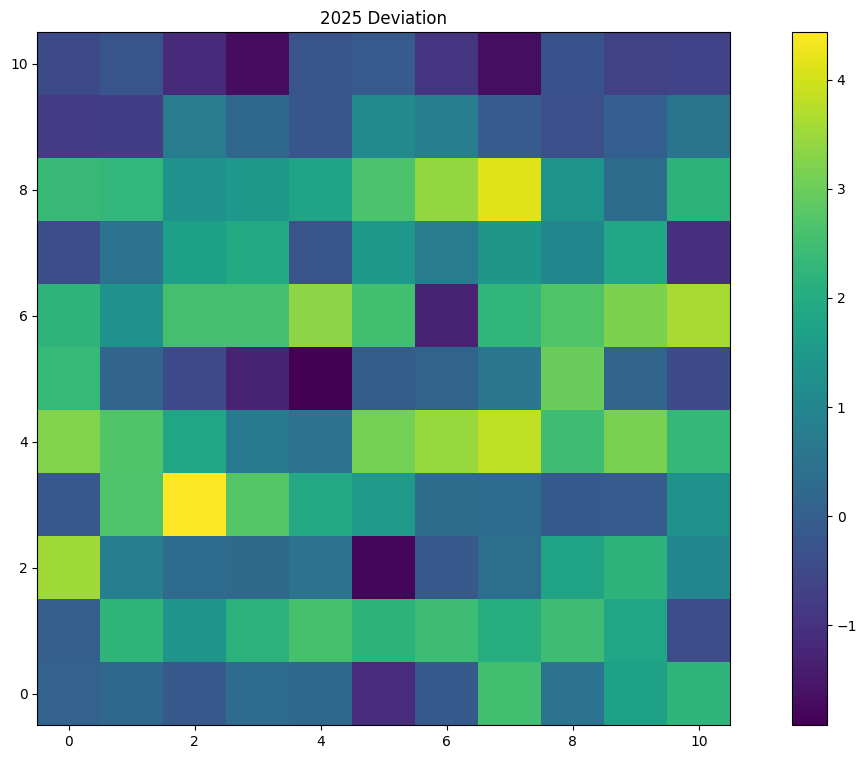

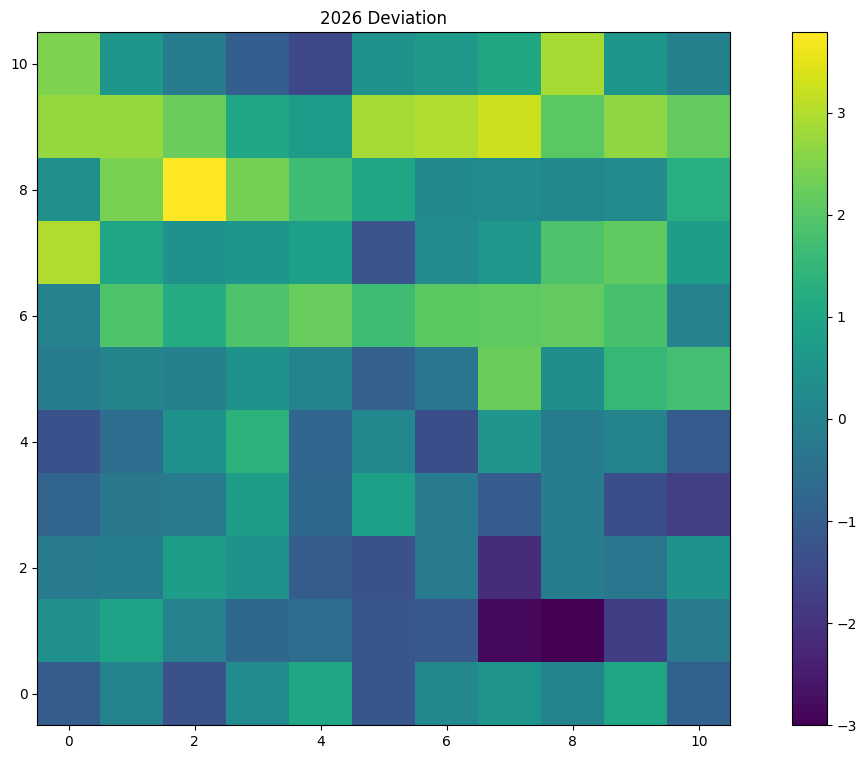

In [8]:
#define the x, y position of the knot
dev_x = [473, round(473)]
dev_y = [1240, round(1240)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2025 Deviation"
ax.set_title(title_1)
std_17 = hdu_2.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

## **Chi Testing**

In [9]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (35./60) + 15.048/3600)
DEC_Protostar = -1 * (5. + 0./60 + 8.05/3600)   
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
distance_protostar = 392.8
time_pictures = 3

In [10]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
position_storage = []
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []
x_coord_1_chi = []
y_coord_1_chi = []
x_coord_2_chi = []
y_coord_2_chi = []
knot_knot_sep = []

knot_angle = []
angle_error = [] 
chi_value = []

# **100 km s-1**

In [95]:
hdu_2 = fits.open((path_image_2 + 'testing_100km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 4
minimum chi squared value =  0.08409439304117072 , X shift =  0.0 , Y shift =  5.15
Vx 0.0 Vy 99.89085723146977
velocity 99.89085723146977
V error ± 1.454721221817536
Vx error ± 2.909442443635042 Vy error ± 1.454721221817536
angle = -0.0
angle error ± 1.668809112031524


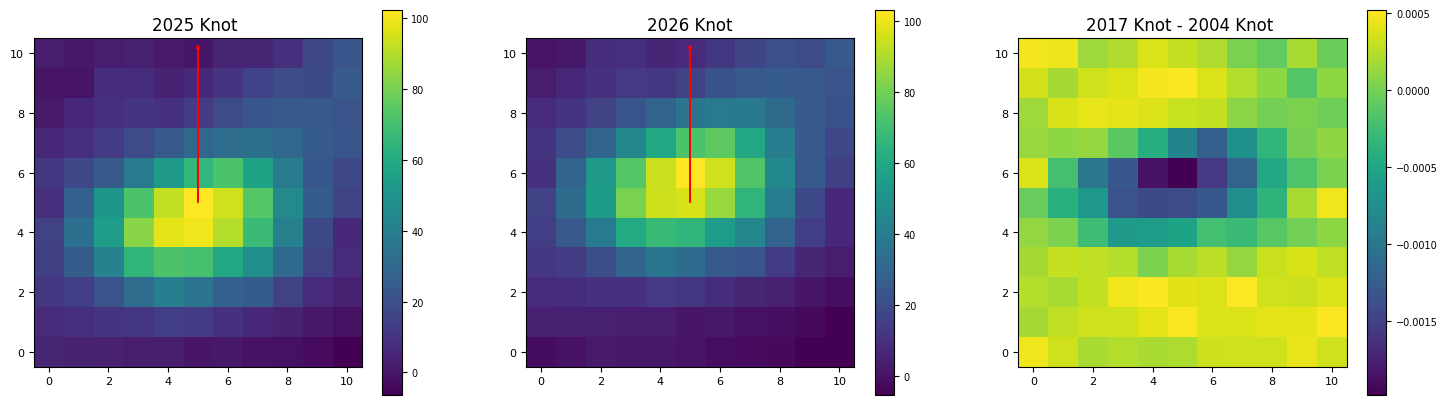

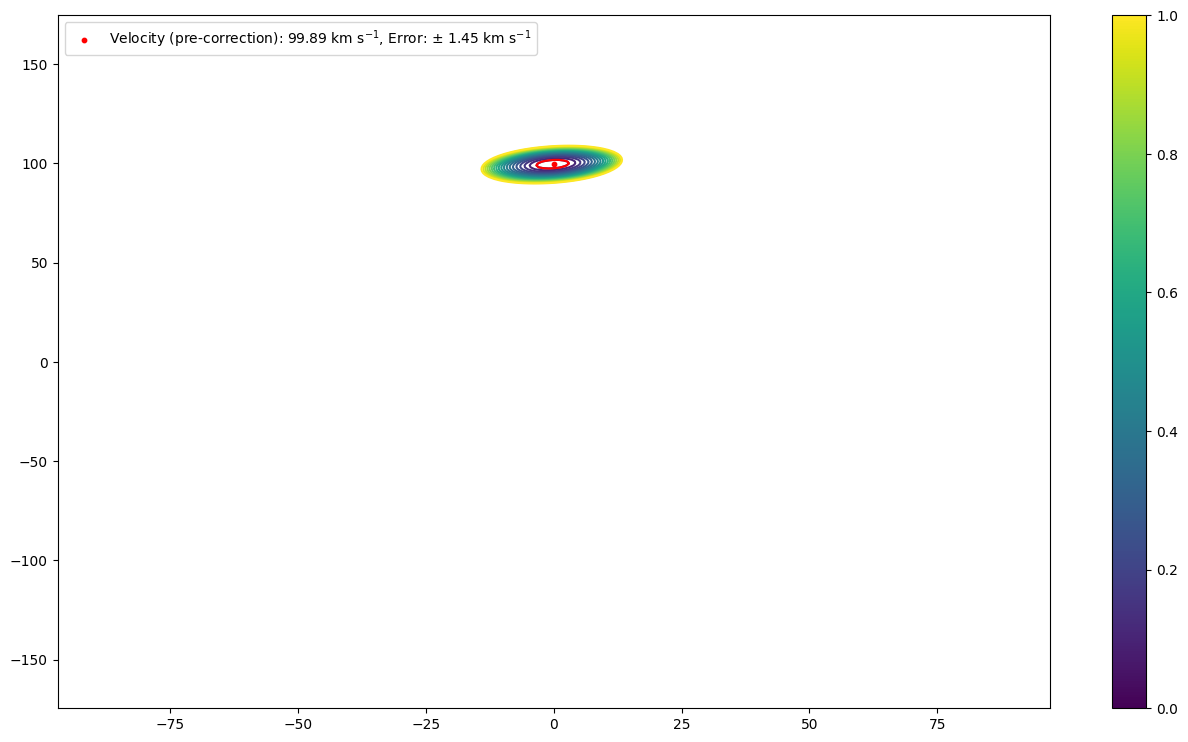

In [12]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5823]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 5
minimum chi squared value =  0.014380003605829557 , X shift =  0.0 , Y shift =  5.15
Vx 0.0 Vy 99.89085723146977
velocity 99.89085723146977
V error ± 0.0
Vx error ± 1.9396282957566944 Vy error ± 0.0
angle = -0.0
angle error ± 1.1125394080210158


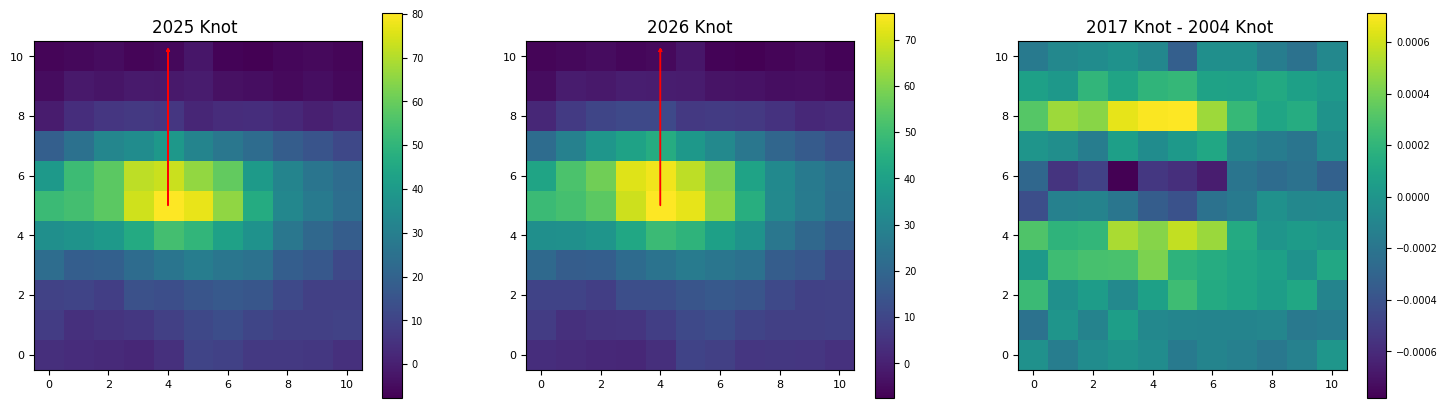

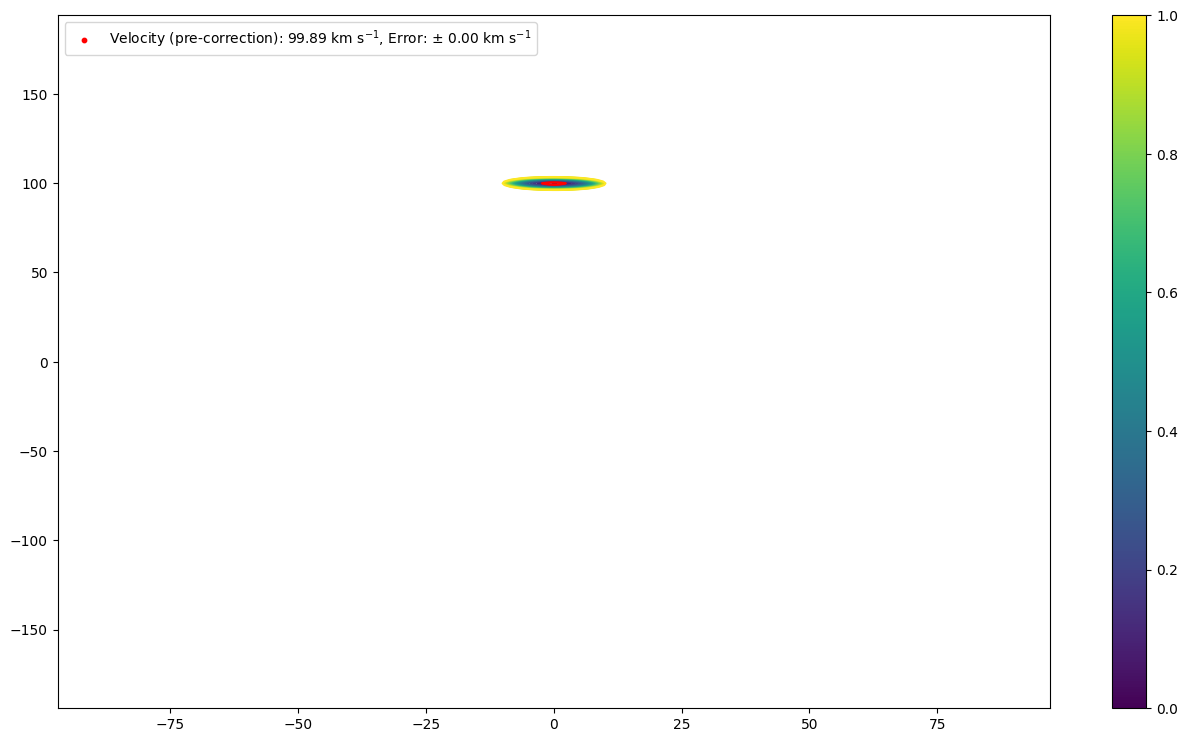

In [13]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5837]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 5
minimum chi squared value =  0.0061289600759593405 , X shift =  0.0 , Y shift =  5.15
Vx 0.0 Vy 99.89085723146977
velocity 99.89085723146977
V error ± 0.9698141478783526
Vx error ± 2.4245353696958682 Vy error ± 0.9698141478783526
angle = -0.0
angle error ± 1.39067426002627


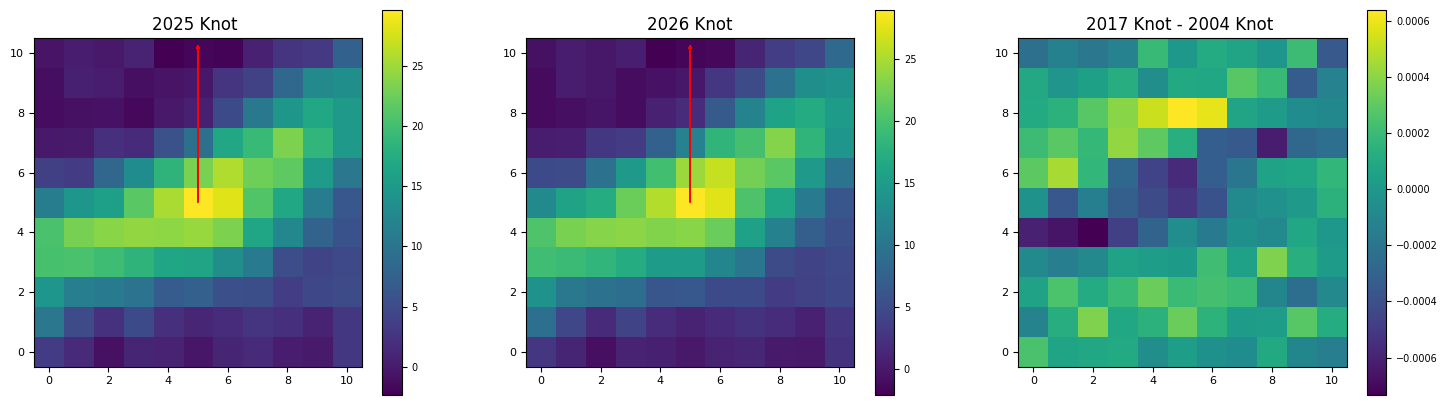

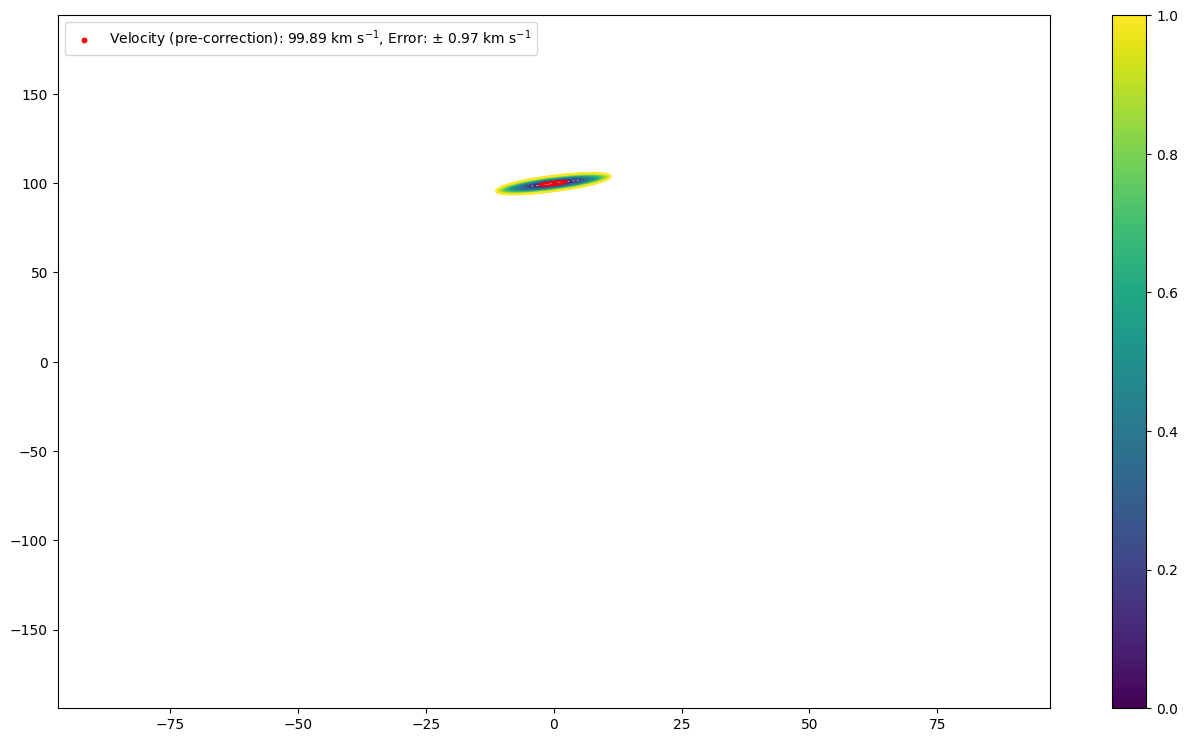

In [14]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5741]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 5
minimum chi squared value =  0.0036885563372896987 , X shift =  0.0 , Y shift =  5.15
Vx 0.0 Vy 99.89085723146977
velocity 99.89085723146977
V error ± 0.9698141478783526
Vx error ± 0.9698141478783472 Vy error ± 0.9698141478783526
angle = -0.0
angle error ± 0.5562697040105079


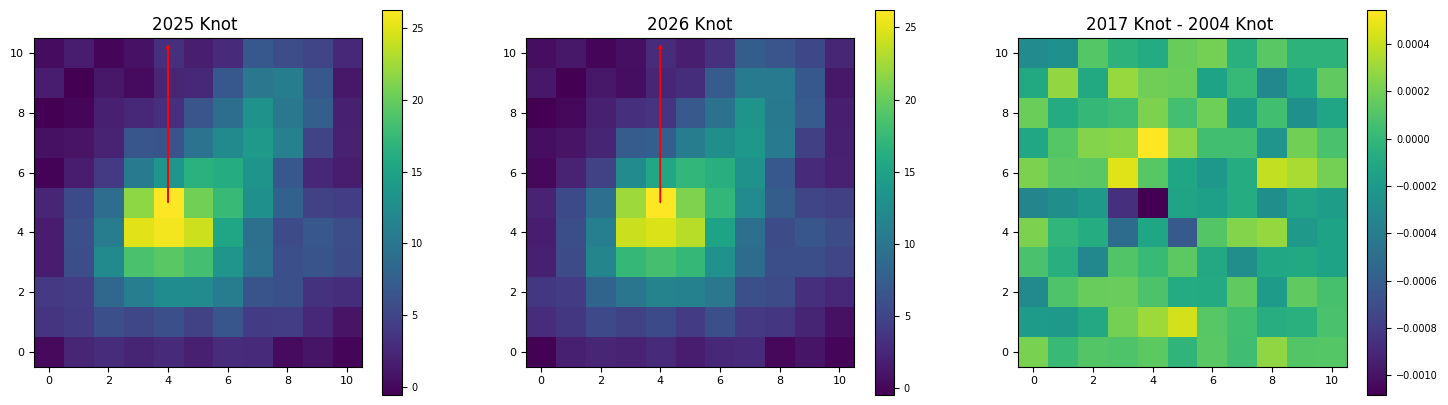

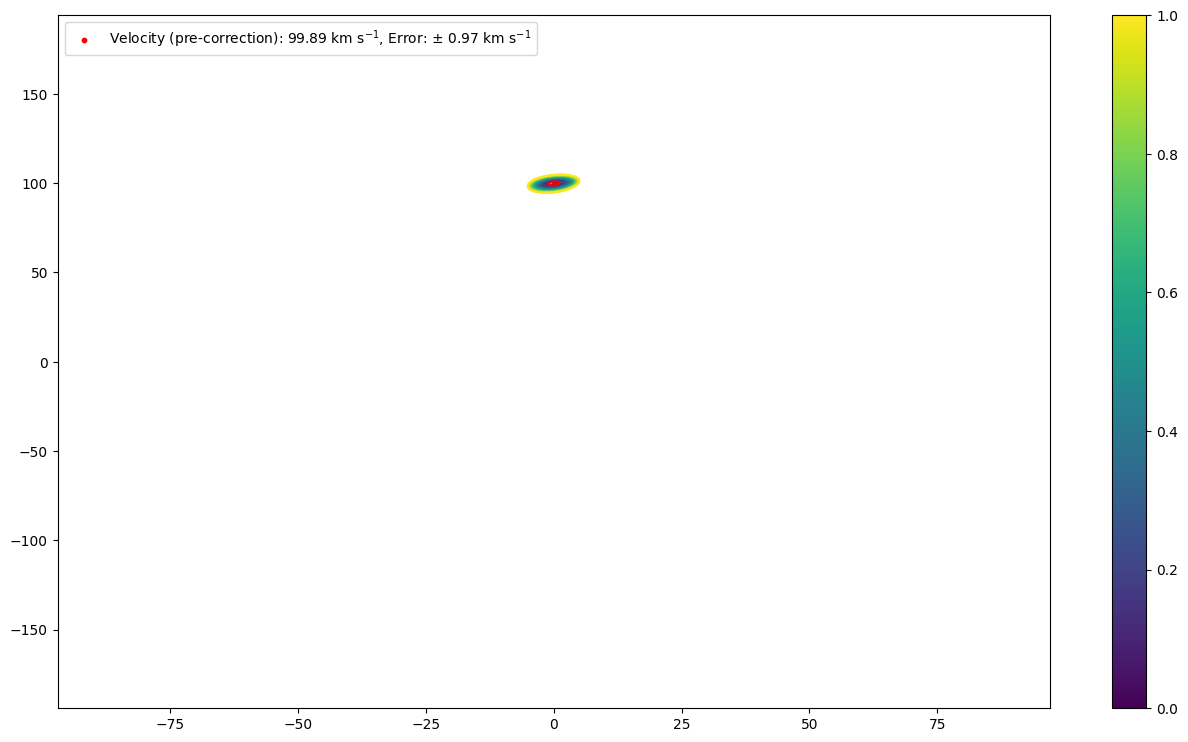

In [15]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5925]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 5
minimum chi squared value =  0.007762224592710055 , X shift =  0.0 , Y shift =  5.15
Vx 0.0 Vy 99.89085723146977
velocity 99.89085723146977
V error ± 0.9698141478783526
Vx error ± 0.0 Vy error ± 0.9698141478783526
angle = -0.0
angle error ± 0.0


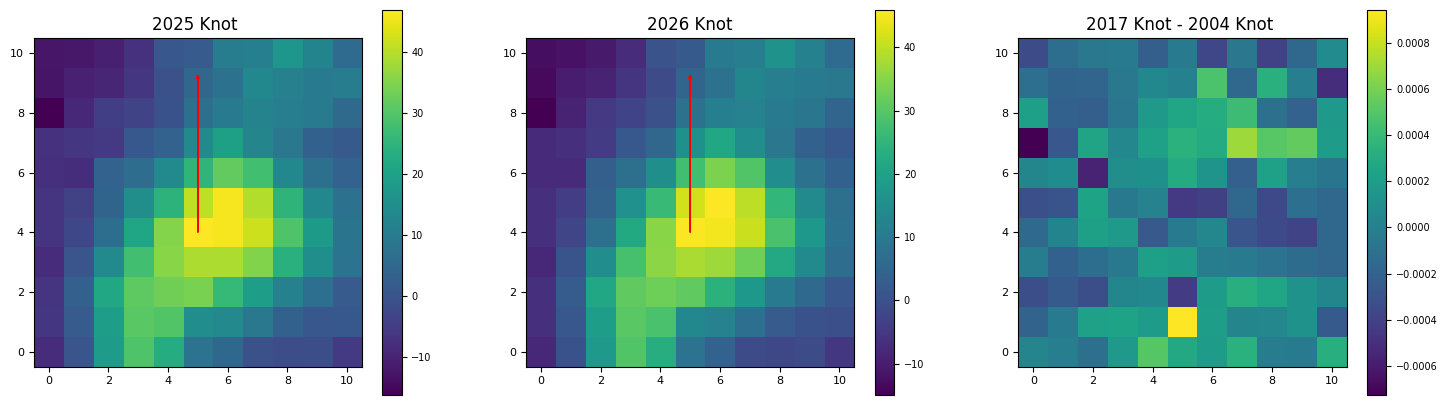

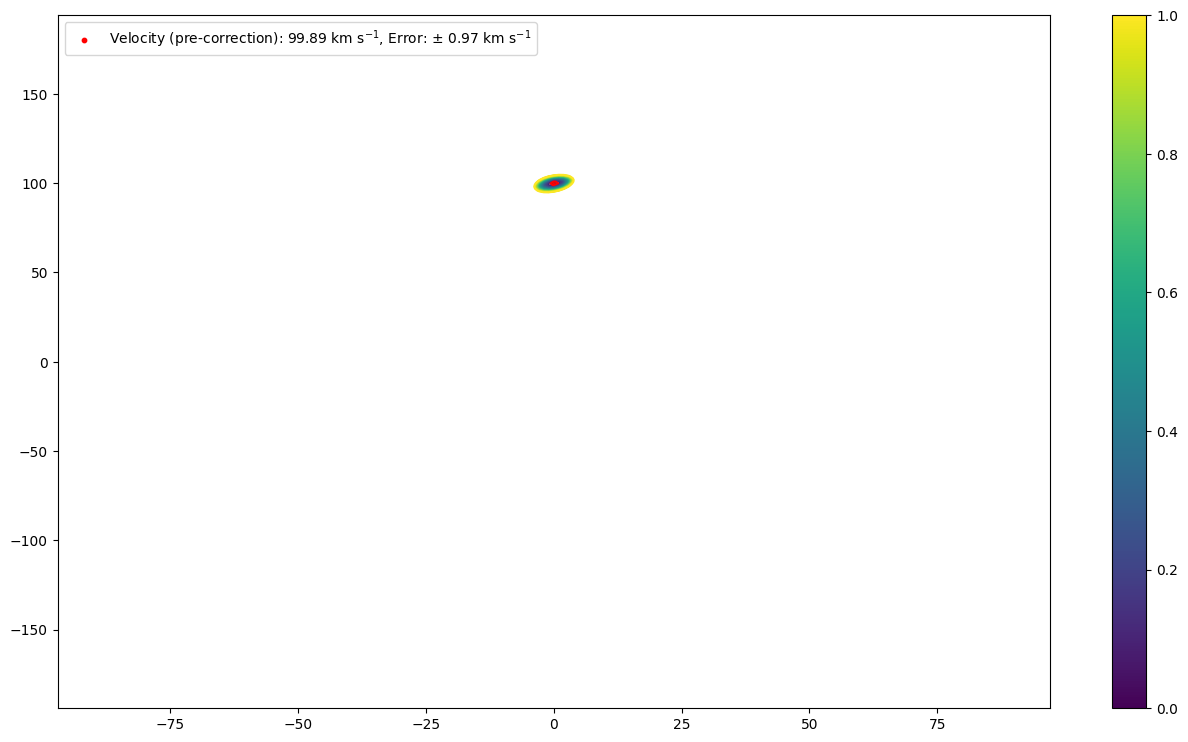

In [97]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6056]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **75 km s-1**

In [99]:
hdu_2 = fits.open((path_image_2 + 'testing_75km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 4
minimum chi squared value =  0.014468690527805835 , X shift =  0.0 , Y shift =  3.85
Vx 0.0 Vy 74.67568938663273
velocity 74.67568938663273
V error ± 0.4849070739391763
Vx error ± 0.9698141478783472 Vy error ± 0.4849070739391763
angle = -0.0
angle error ± 0.7441010326374329


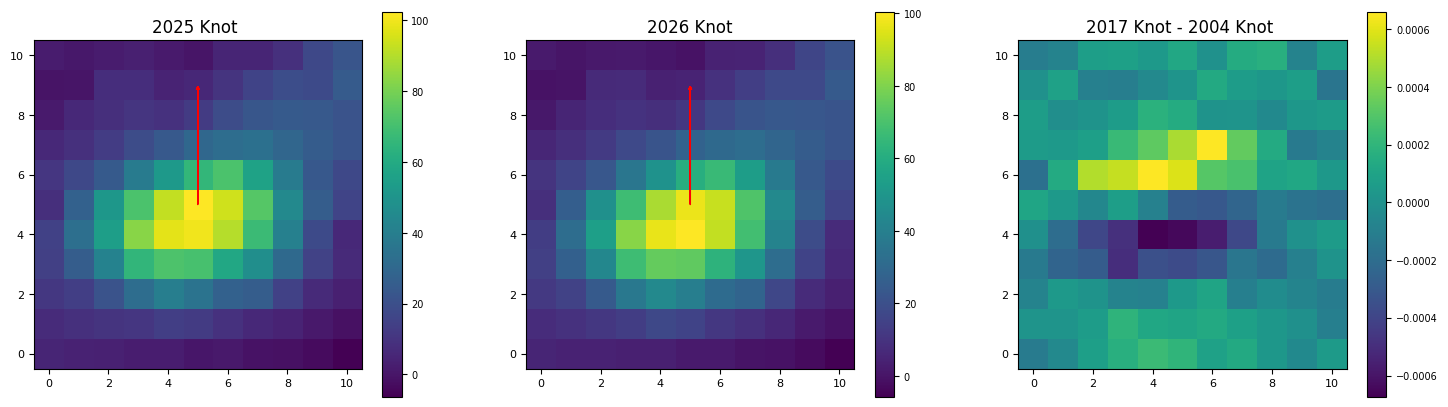

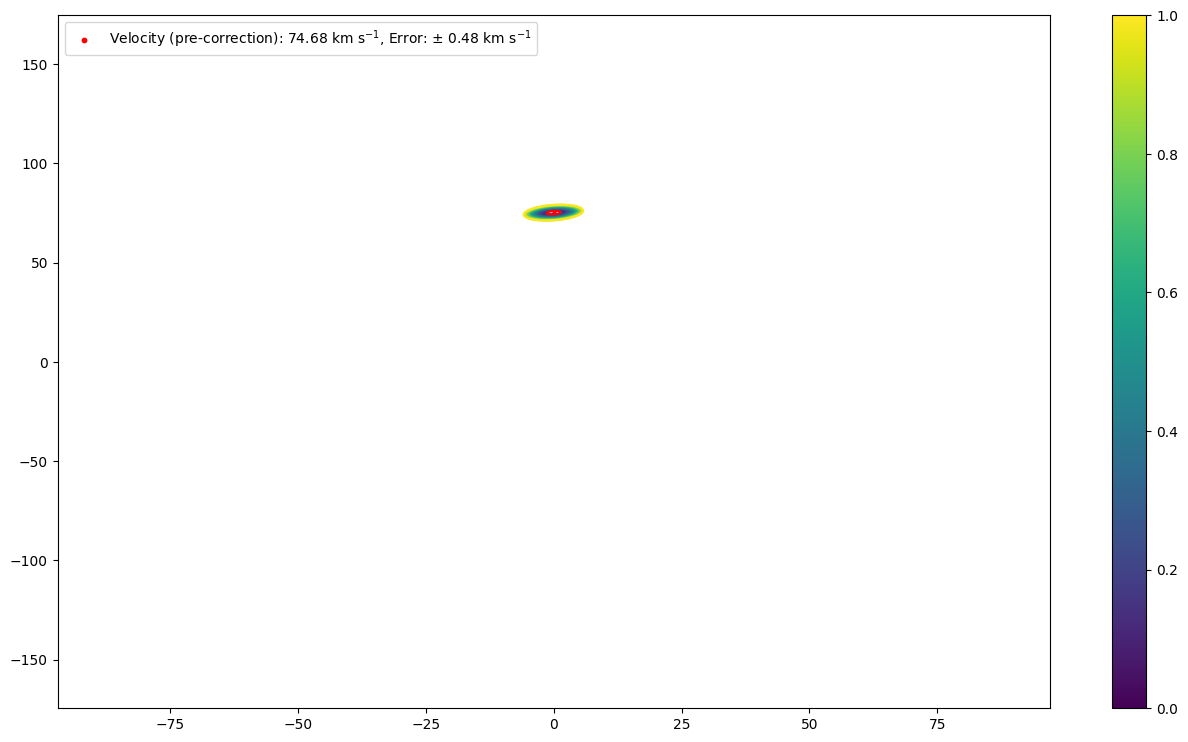

In [17]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5823]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 4
minimum chi squared value =  0.026617986039101132 , X shift =  0.0 , Y shift =  3.9
Vx 0.0 Vy 75.64550353451108
velocity 75.64550353451108
V error ± 0.4849070739391763
Vx error ± 2.909442443635042 Vy error ± 0.4849070739391763
angle = -0.0
angle error ± 2.203683827426244


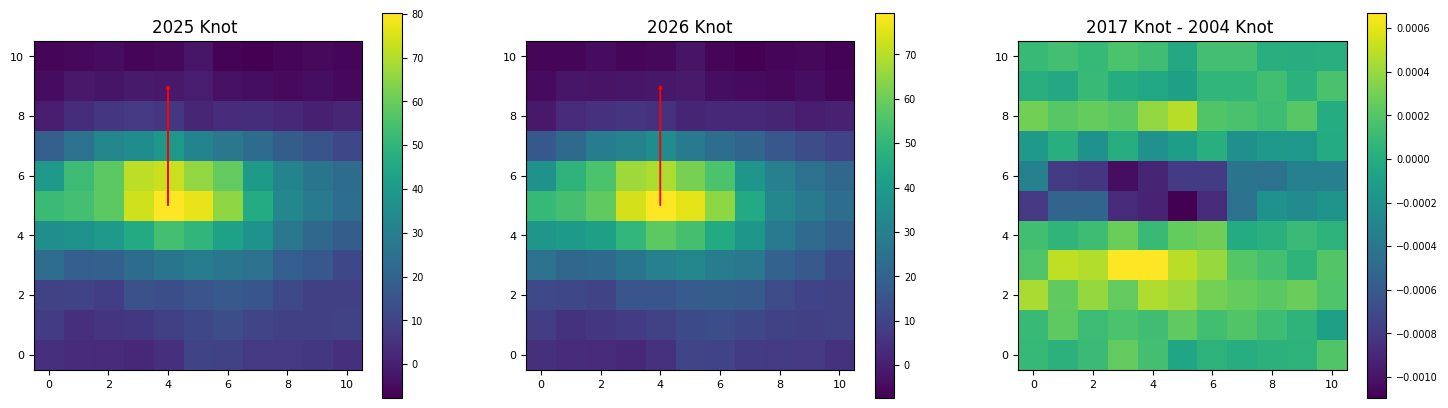

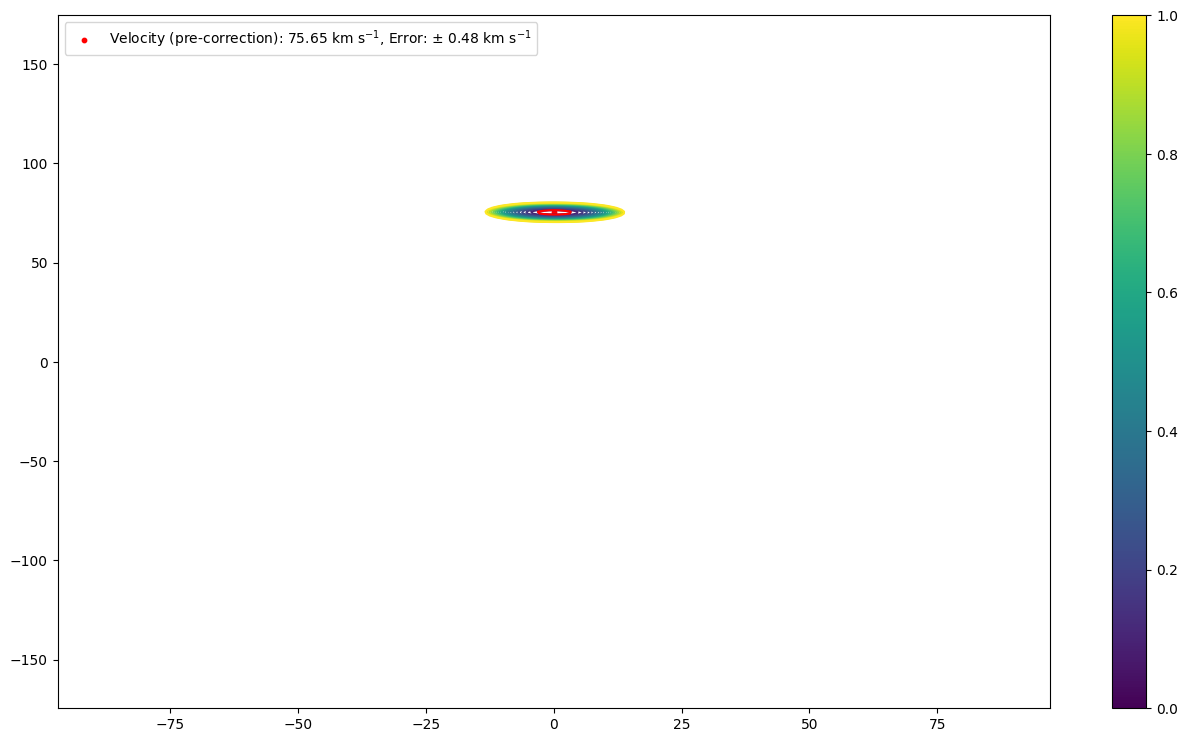

In [18]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5836]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 4
minimum chi squared value =  0.005117972196582705 , X shift =  -0.05 , Y shift =  3.85
Vx -0.9698141478783472 Vy 74.67568938663273
velocity 74.68198661558405
V error ± 0.4855199754780267
Vx error ± 1.9396282957566944 Vy error ± 0.4849070739391763
angle = 0.7440592028887096
angle error ± 1.4879589462405833


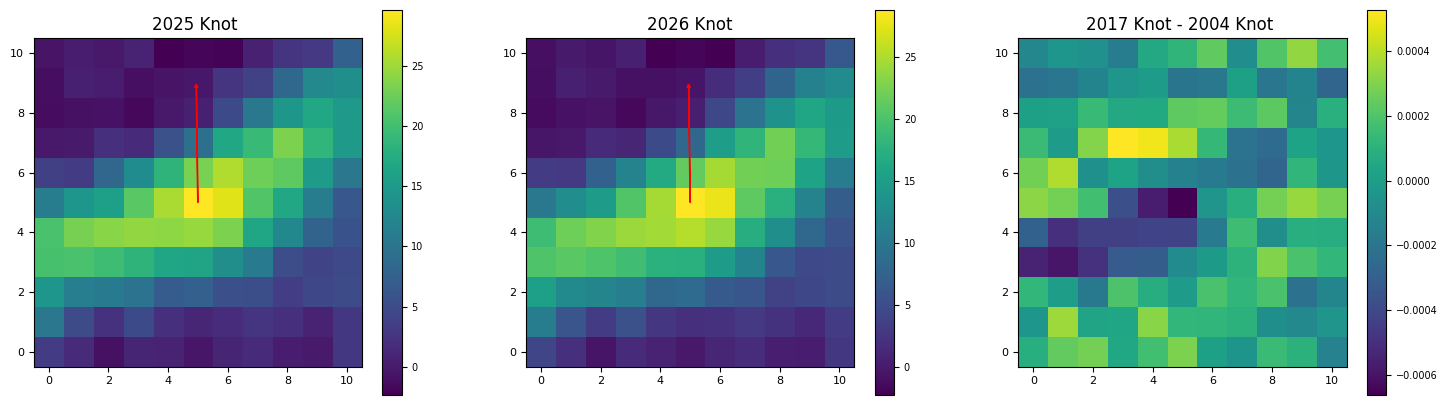

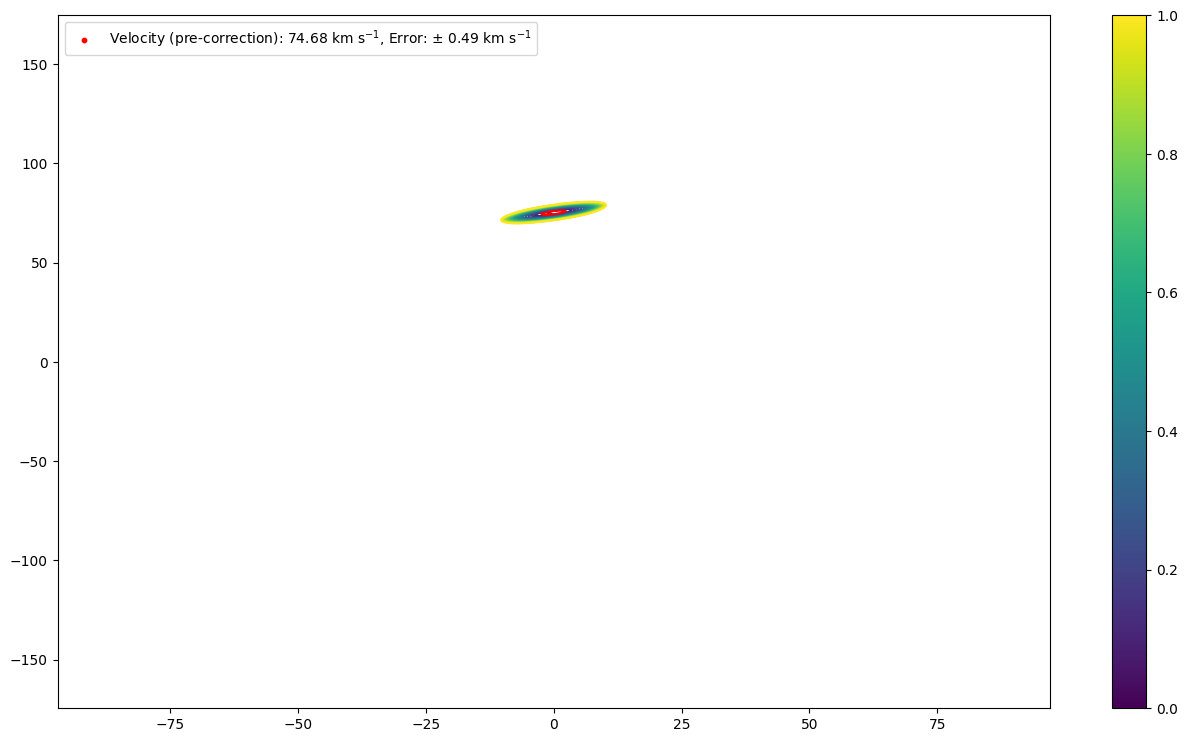

In [19]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5740]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 4
minimum chi squared value =  0.004064152010589409 , X shift =  0.0 , Y shift =  3.85
Vx 0.0 Vy 74.67568938663273
velocity 74.67568938663273
V error ± 0.4849070739391763
Vx error ± 0.9698141478783472 Vy error ± 0.4849070739391763
angle = -0.0
angle error ± 0.7441010326374329


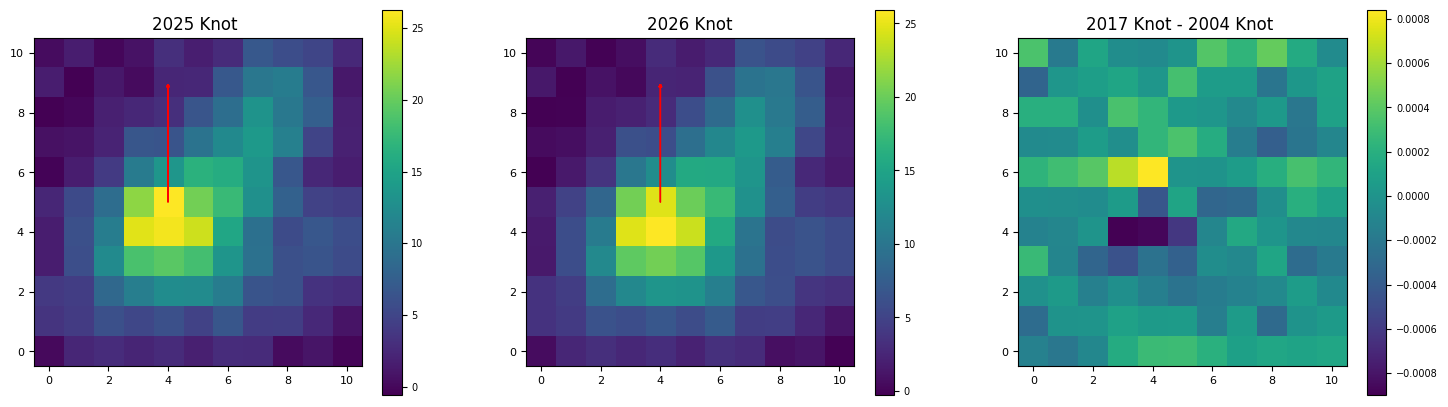

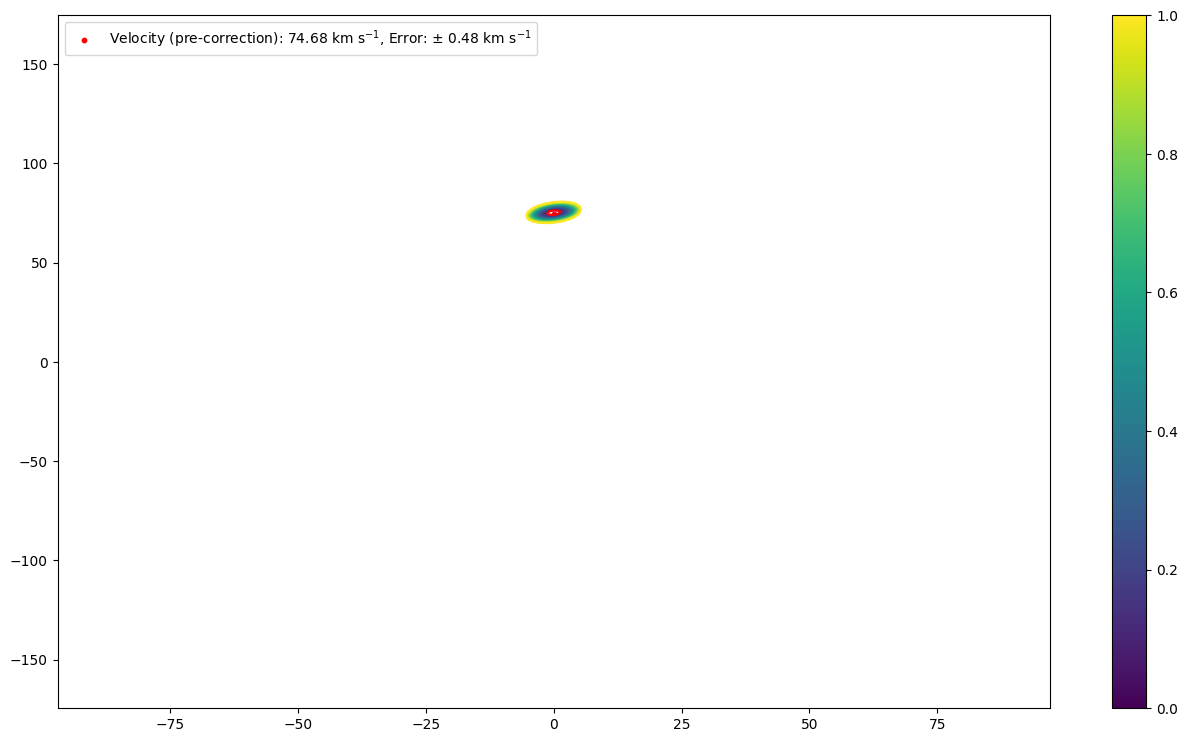

In [20]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5924]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 4
minimum chi squared value =  0.007774932396542541 , X shift =  0.0 , Y shift =  3.85
Vx 0.0 Vy 74.67568938663273
velocity 74.67568938663273
V error ± 0.4849070739391763
Vx error ± 0.4849070739391736 Vy error ± 0.4849070739391763
angle = -0.0
angle error ± 0.37205051631871644


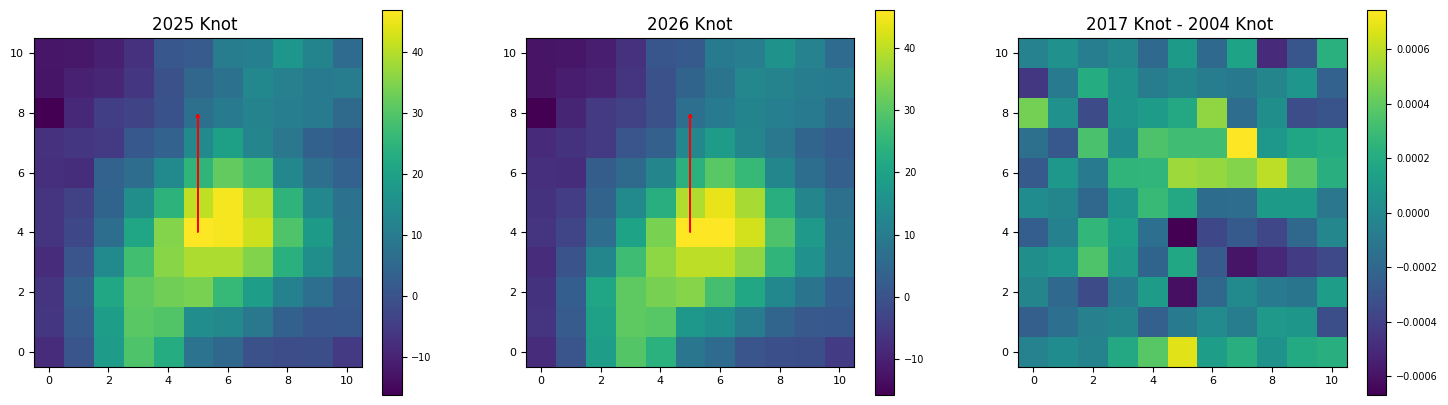

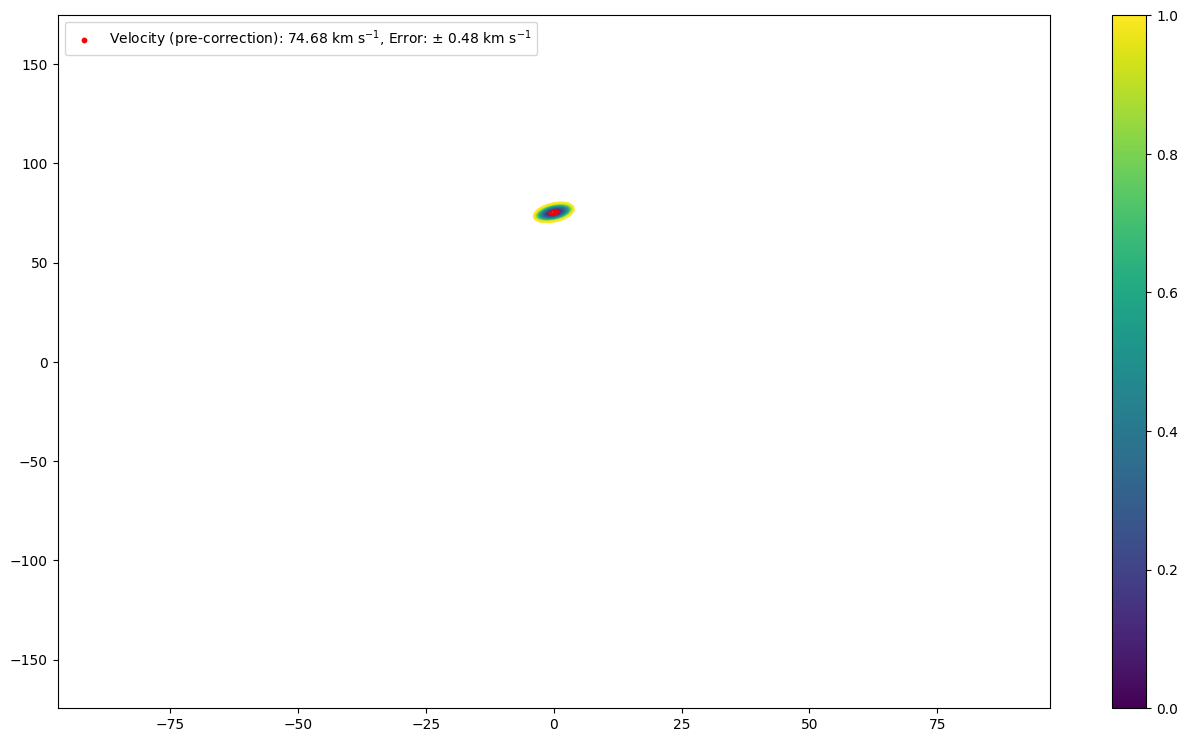

In [100]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6055]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **50 km s-1**

In [101]:
hdu_2 = fits.open((path_image_2 + 'testing_50km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 2
minimum chi squared value =  0.0771596278173687 , X shift =  0.0 , Y shift =  2.6
Vx 0.0 Vy 50.43033568967406
velocity 50.43033568967406
V error ± 1.4547212218175147
Vx error ± 2.909442443635042 Vy error ± 1.4547212218175147
angle = -0.0
angle error ± 3.3055257411393644


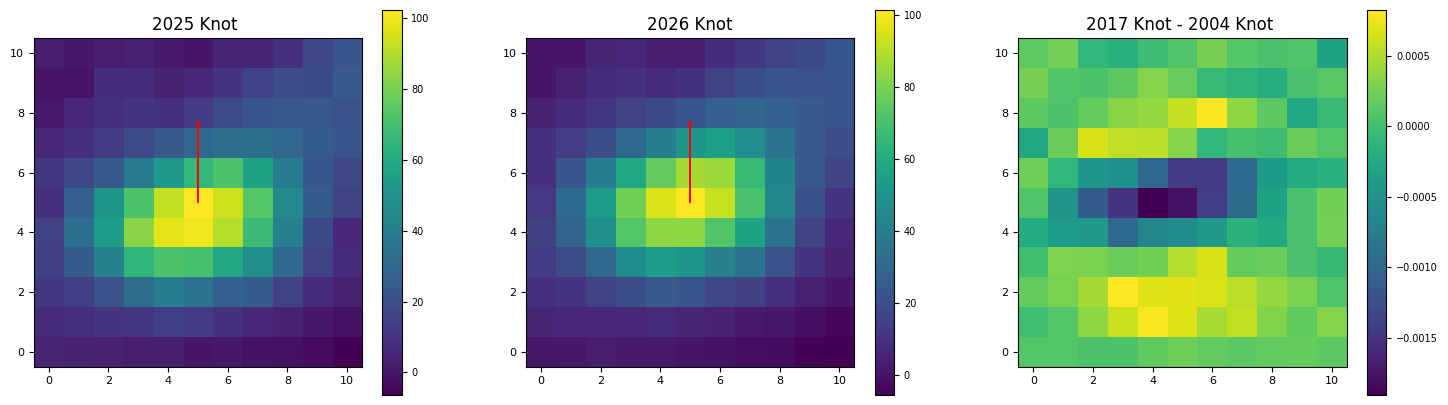

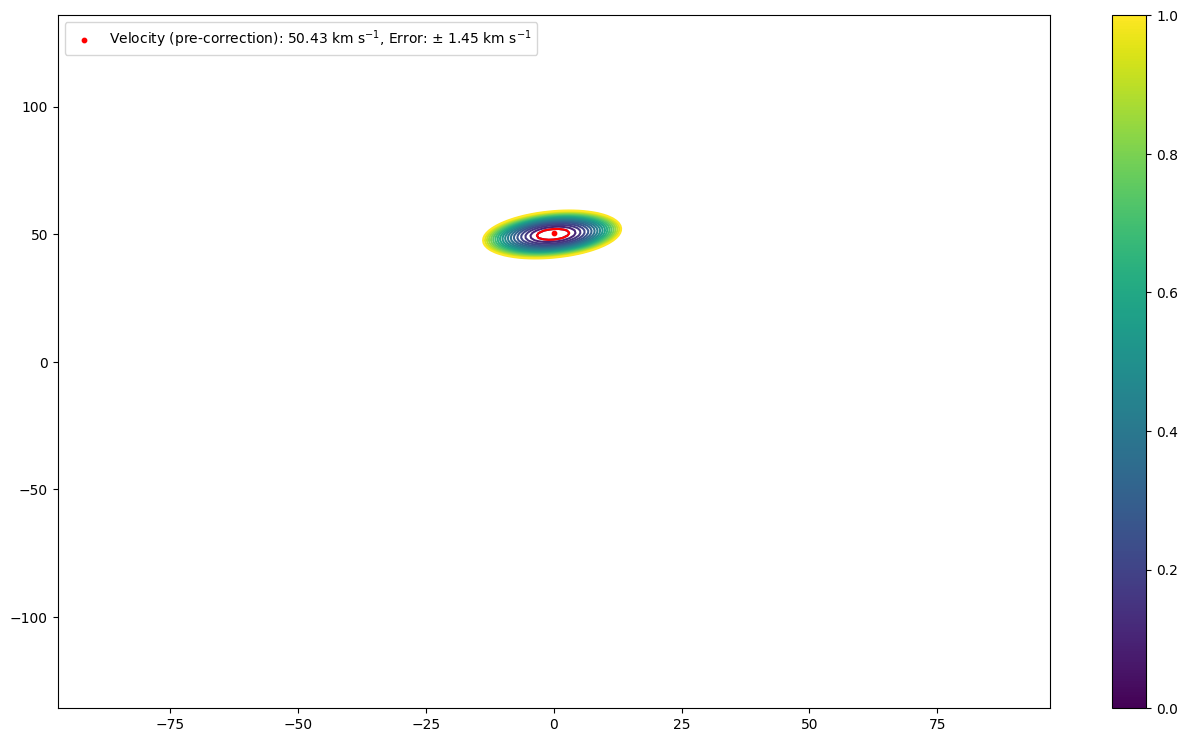

In [22]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5821]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 3
minimum chi squared value =  0.08615295627575488 , X shift =  0.0 , Y shift =  2.6
Vx 0.0 Vy 50.43033568967406
velocity 50.43033568967406
V error ± 1.4547212218175147
Vx error ± 5.333977813330909 Vy error ± 1.4547212218175147
angle = -0.0
angle error ± 6.060130525422167


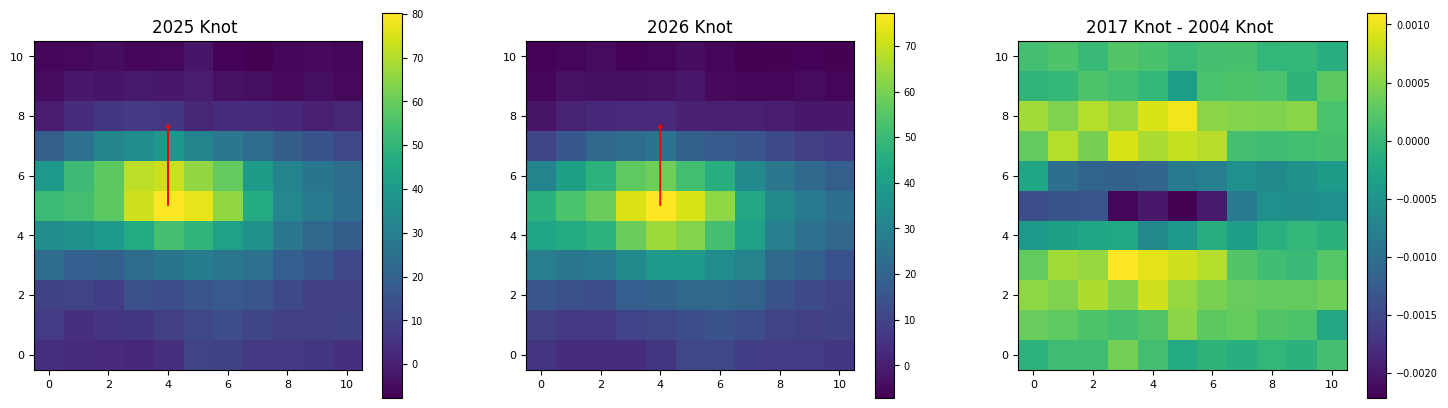

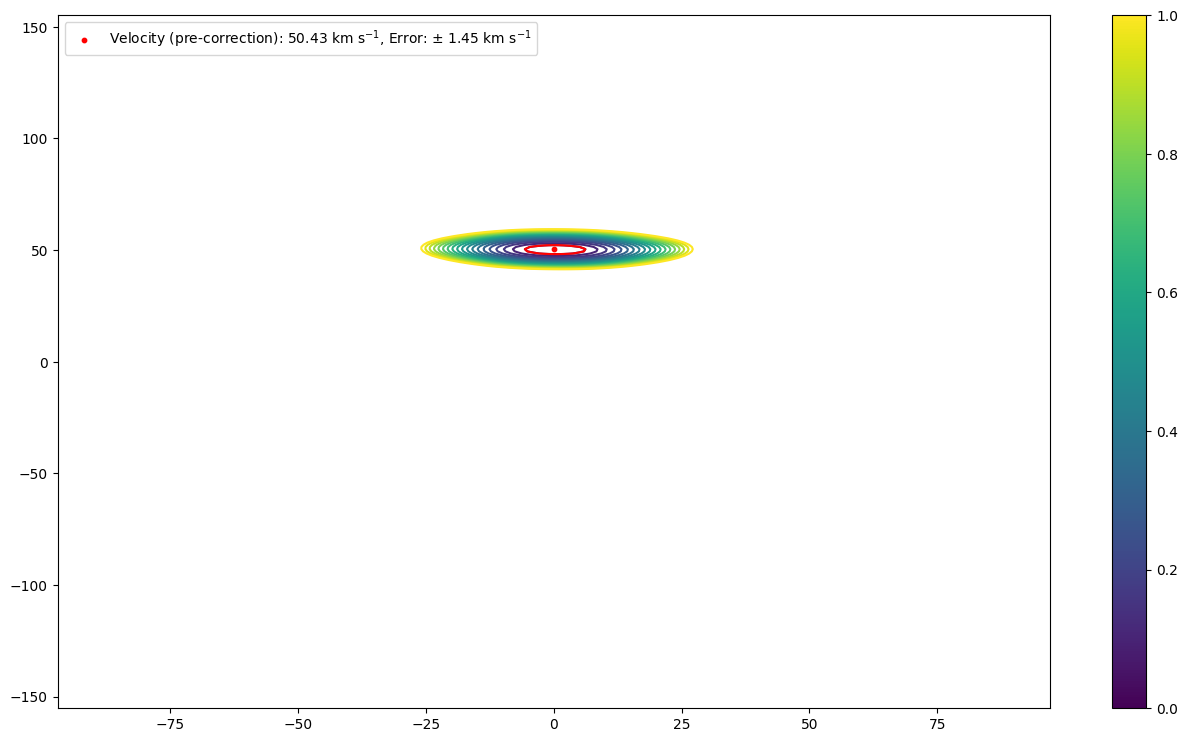

In [23]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5835]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 3
minimum chi squared value =  0.0232951256387539 , X shift =  0.0 , Y shift =  2.6
Vx 0.0 Vy 50.43033568967406
velocity 50.43033568967406
V error ± 2.424535369695864
Vx error ± 4.849070739391736 Vy error ± 2.424535369695864
angle = -0.0
angle error ± 5.509209568565606


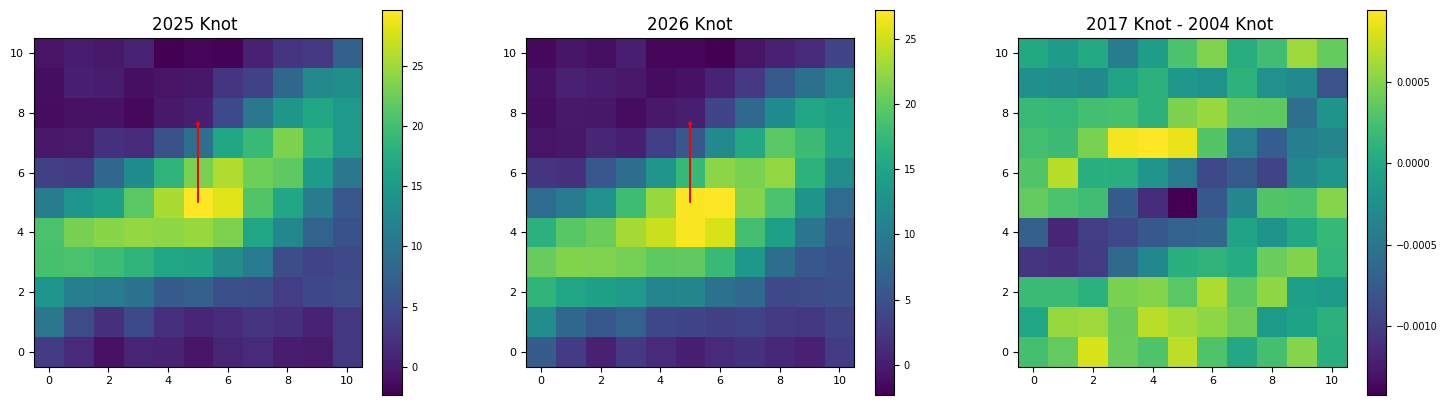

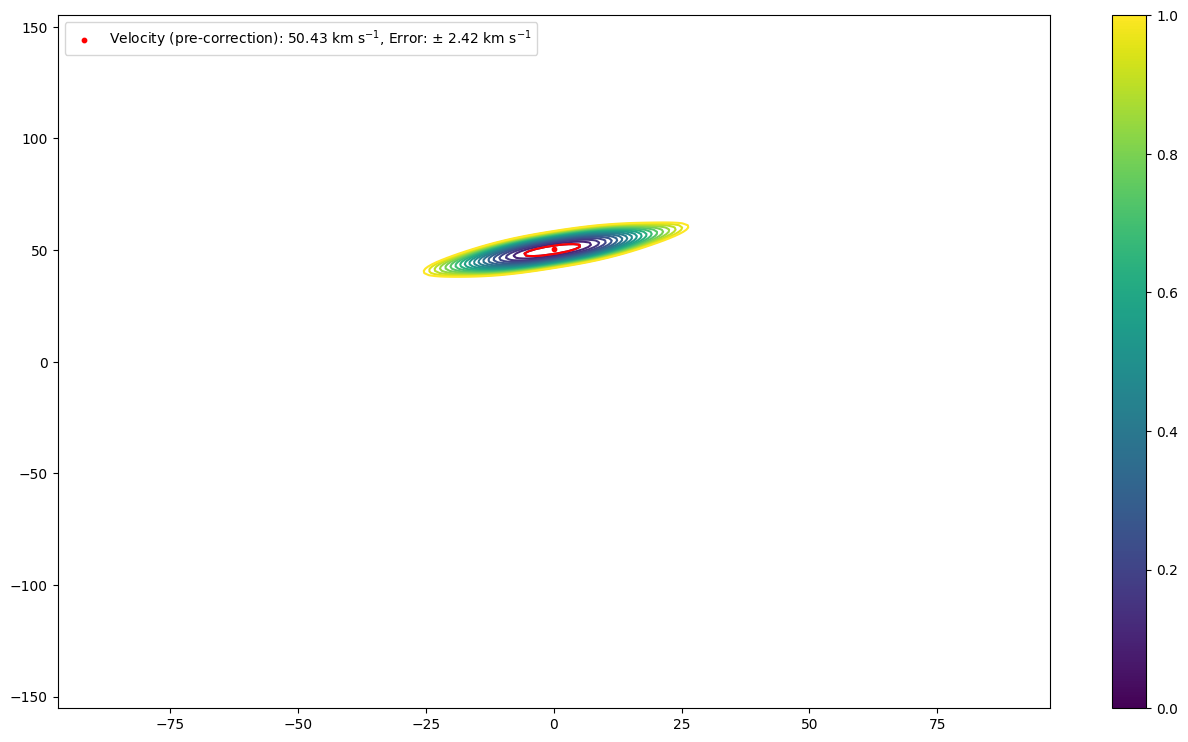

In [24]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5739]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 3
minimum chi squared value =  0.010747136788076431 , X shift =  0.0 , Y shift =  2.6
Vx 0.0 Vy 50.43033568967406
velocity 50.43033568967406
V error ± 1.4547212218175147
Vx error ± 1.9396282957566944 Vy error ± 1.4547212218175147
angle = -0.0
angle error ± 2.203683827426243


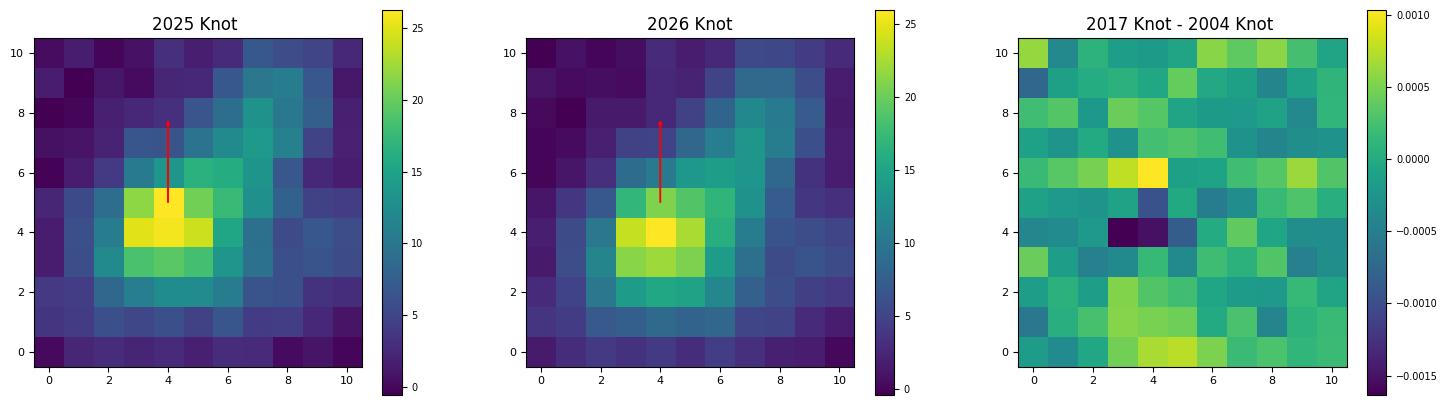

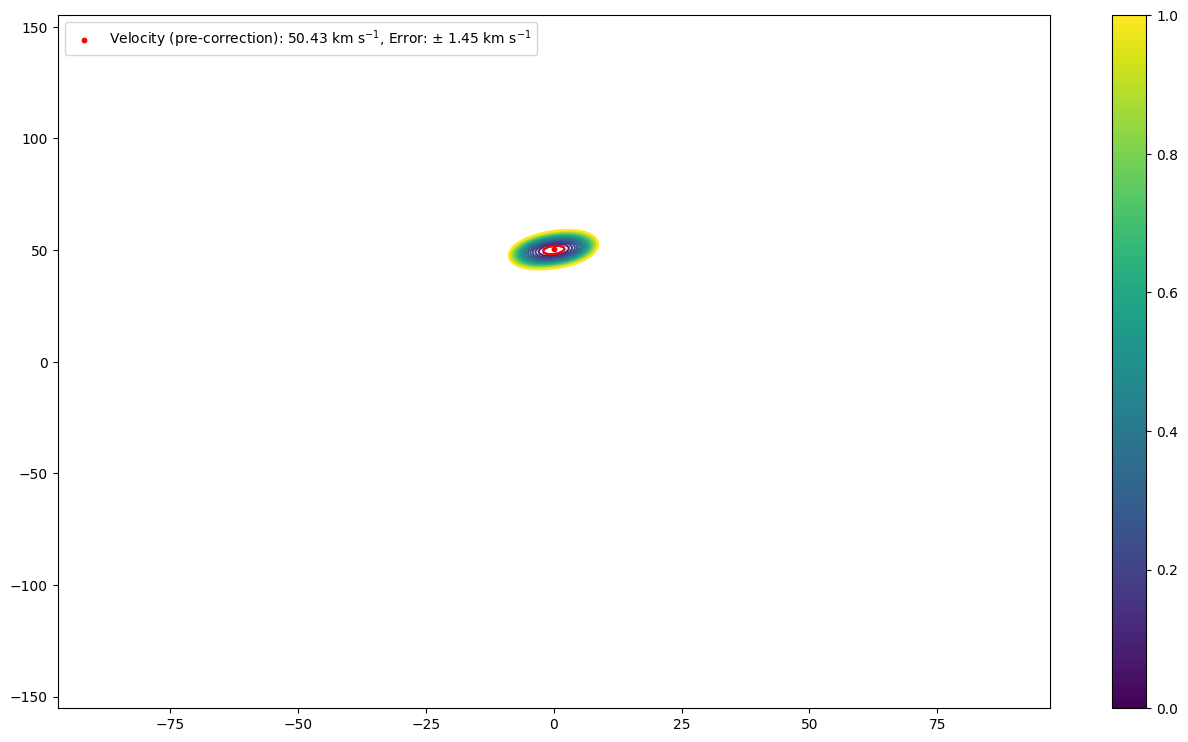

In [25]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5923]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 3
minimum chi squared value =  0.02922578222128753 , X shift =  0.0 , Y shift =  2.6
Vx 0.0 Vy 50.43033568967406
velocity 50.43033568967406
V error ± 1.4547212218175147
Vx error ± 1.4547212218175207 Vy error ± 1.4547212218175147
angle = -0.0
angle error ± 1.6527628705696822


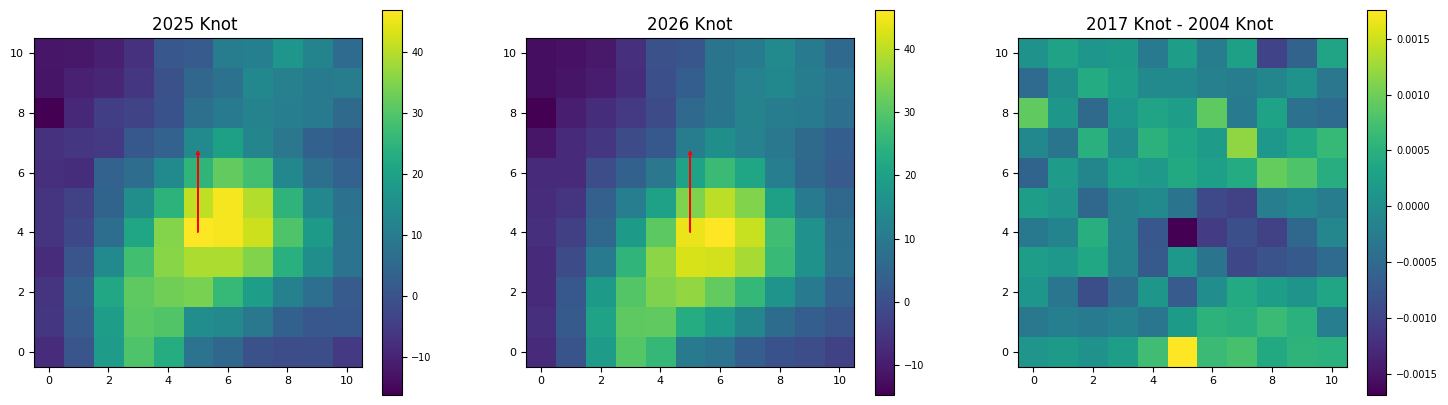

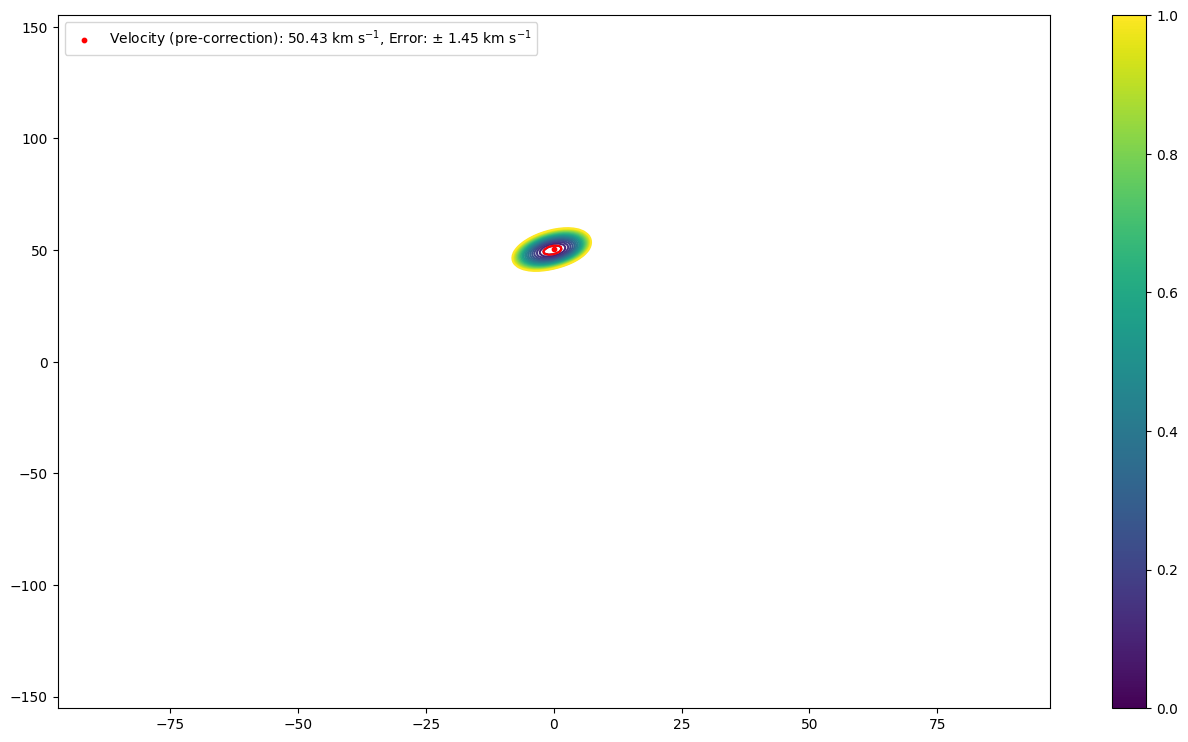

In [102]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6054]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **25 km s-1**

In [103]:
hdu_2 = fits.open((path_image_2 + 'testing_25km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 1
minimum chi squared value =  0.04260099605680436 , X shift =  0.0 , Y shift =  1.3
Vx 0.0 Vy 25.21516784483703
velocity 25.21516784483703
V error ± 1.45472122181752
Vx error ± 1.9396282957566944 Vy error ± 1.45472122181752
angle = -0.0
angle error ± 4.407367654852486


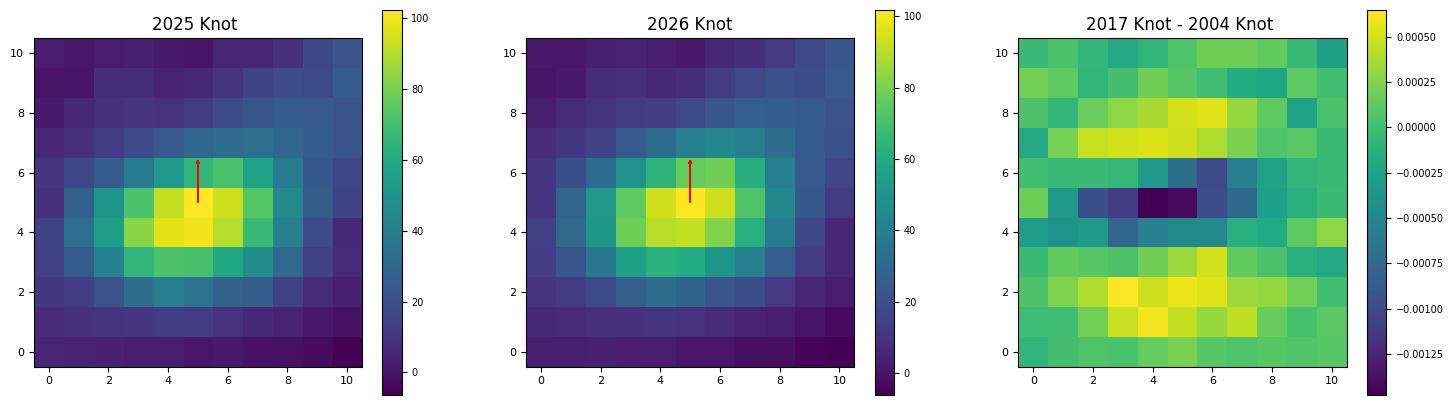

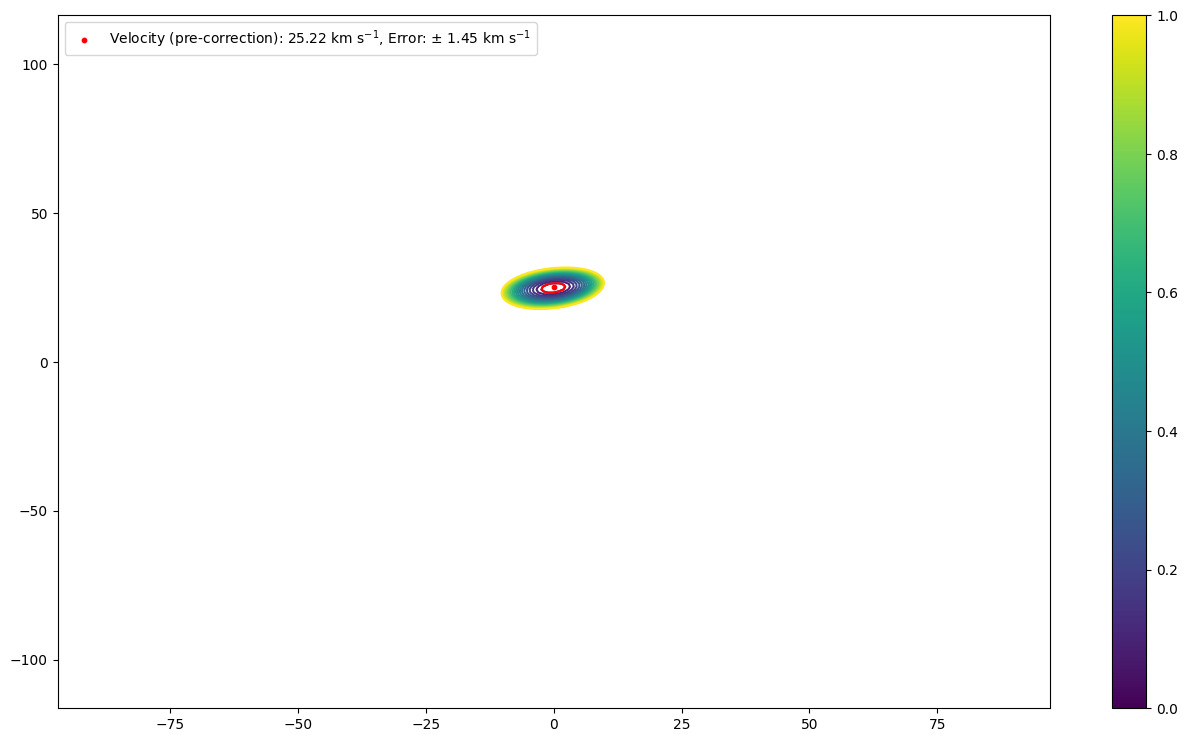

In [27]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5820]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.03409519218570002 , X shift =  0.0 , Y shift =  1.3
Vx 0.0 Vy 25.21516784483703
velocity 25.21516784483703
V error ± 0.48490707393917454
Vx error ± 3.3943495175742155 Vy error ± 0.48490707393917454
angle = -0.0
angle error ± 7.712893395991851


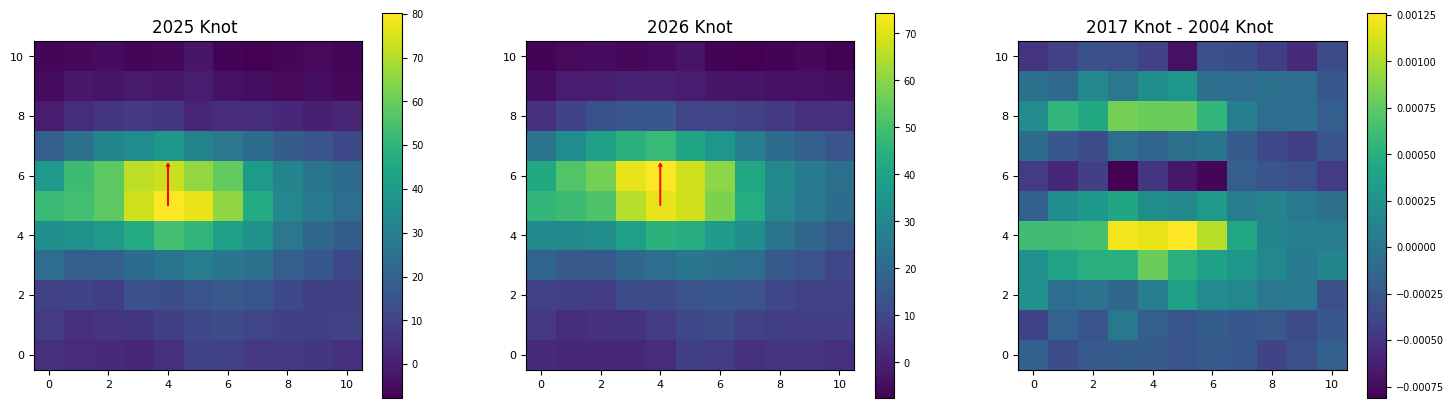

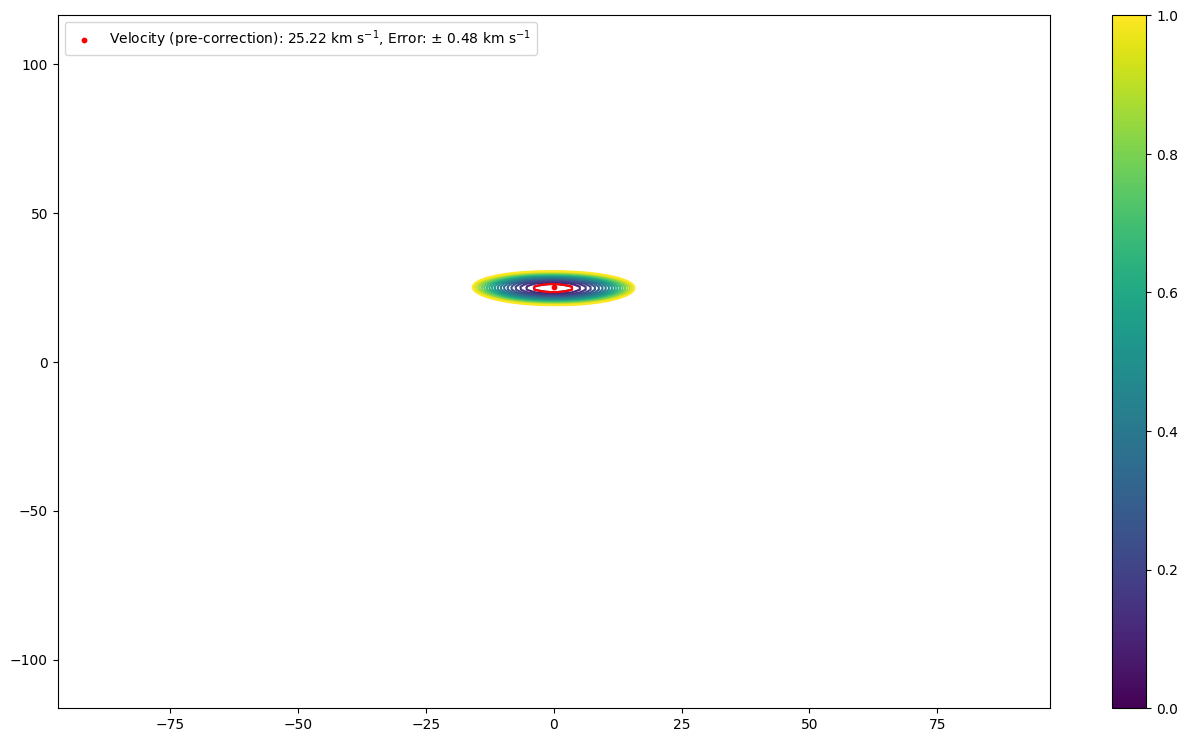

In [28]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5833]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.013988527128098326 , X shift =  -0.05 , Y shift =  1.25
Vx -0.9698141478783472 Vy 24.24535369695868
velocity 24.264742227603676
V error ± 1.46180458601498
Vx error ± 3.8792565915133888 Vy error ± 1.45472122181752
angle = 2.2906100426385296
angle error ± 9.153710052035699


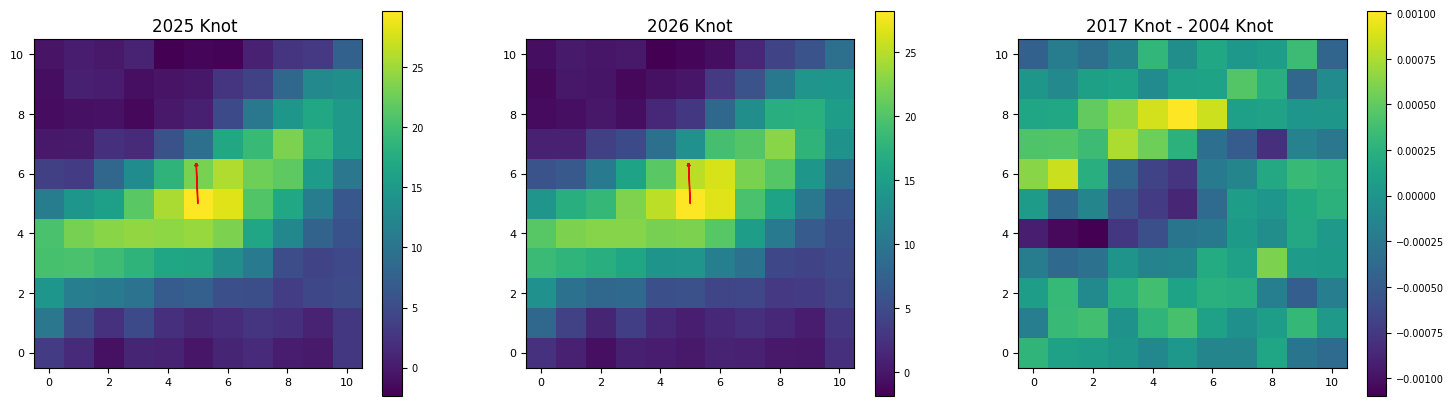

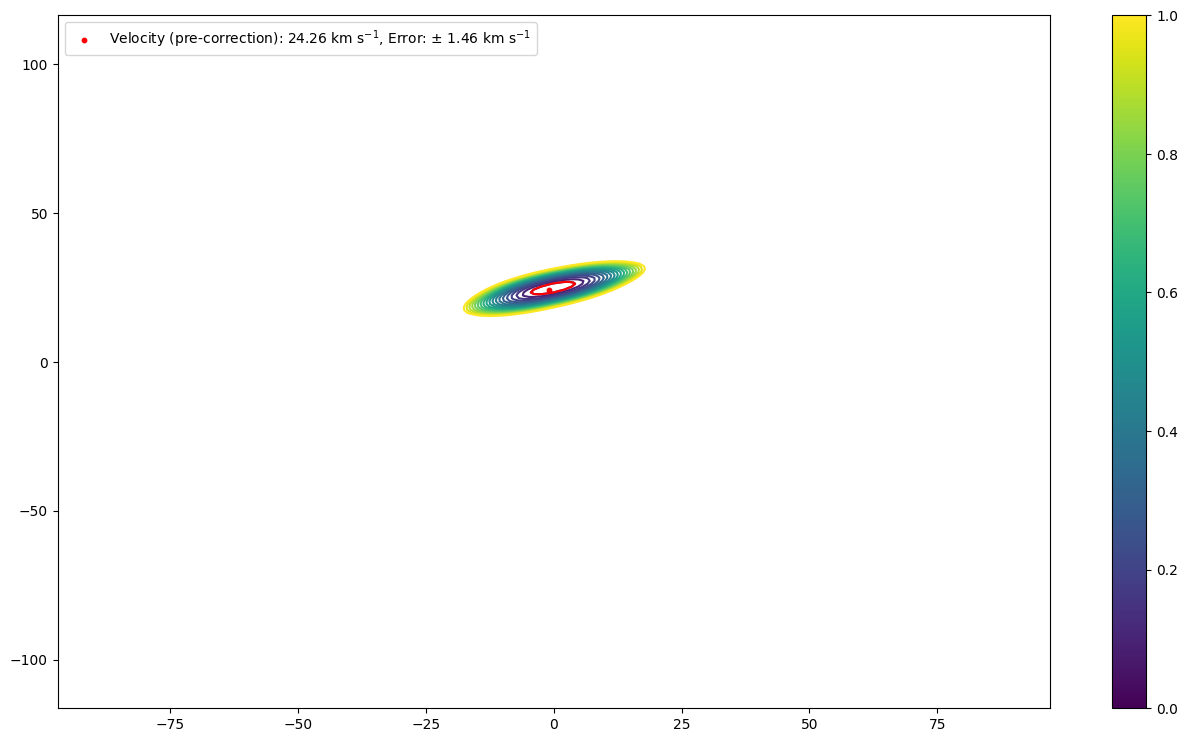

In [29]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5737]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 2
minimum chi squared value =  0.008875505442416056 , X shift =  0.0 , Y shift =  1.2999999999999998
Vx 0.0 Vy 25.215167844837023
velocity 25.215167844837023
V error ± 1.45472122181752
Vx error ± 0.9698141478783472 Vy error ± 1.45472122181752
angle = -0.0
angle error ± 2.2036838274262434


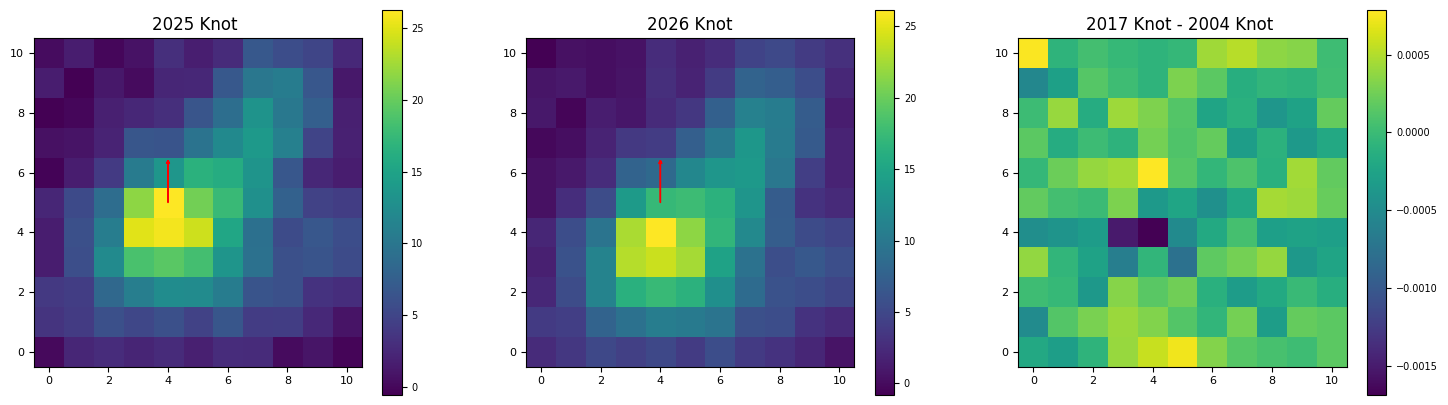

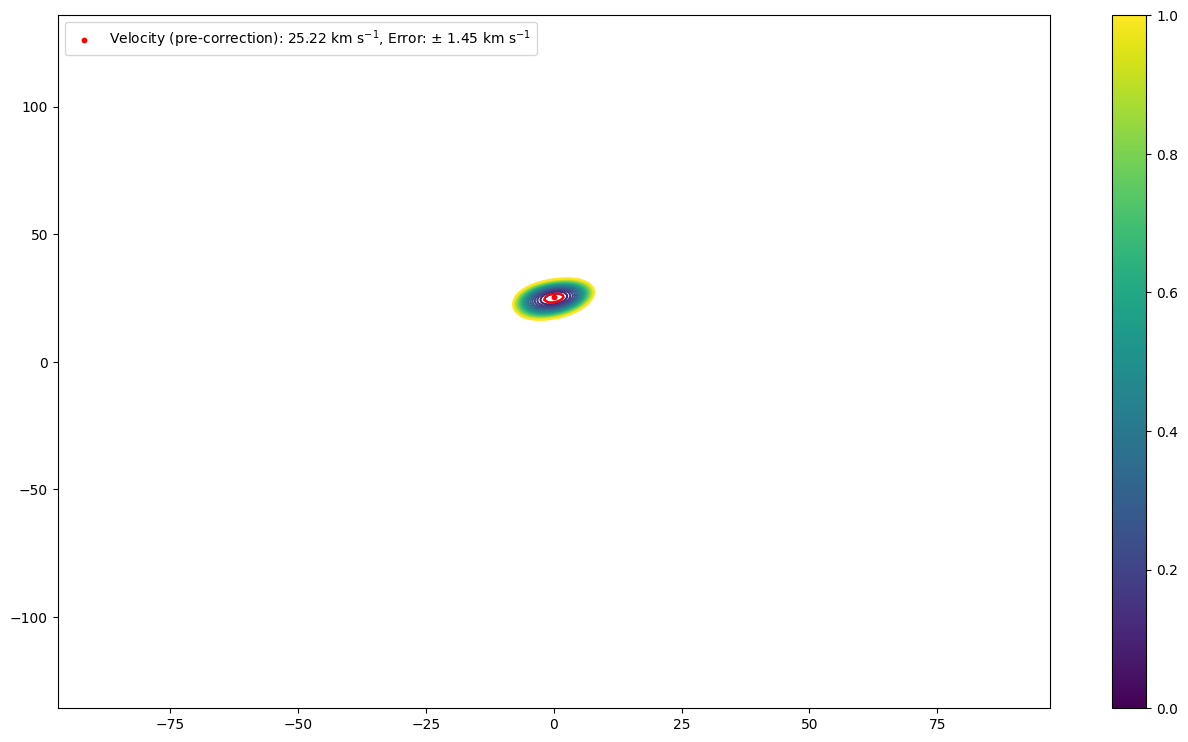

In [30]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5922]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.017547909556349935 , X shift =  0.0 , Y shift =  1.3
Vx 0.0 Vy 25.21516784483703
velocity 25.21516784483703
V error ± 0.9698141478783455
Vx error ± 0.9698141478783472 Vy error ± 0.9698141478783455
angle = -0.0
angle error ± 2.203683827426243


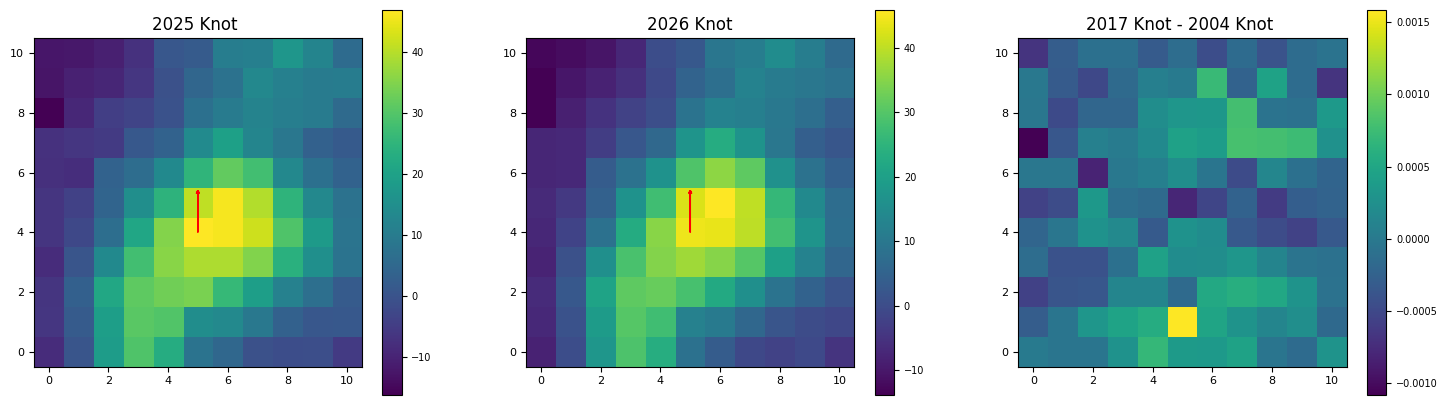

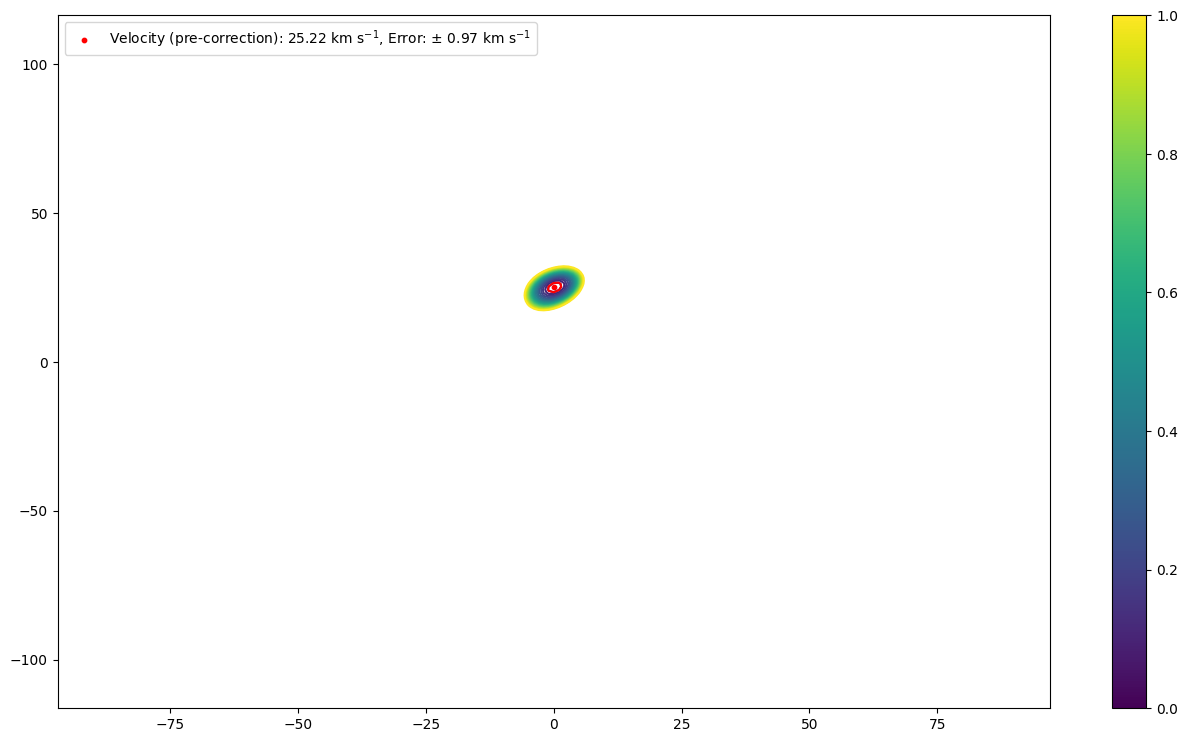

In [105]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6052]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **15 km s-1**

In [106]:
hdu_2 = fits.open((path_image_2 + 'testing_15km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 0
minimum chi squared value =  0.05891745622669375 , X shift =  0.0 , Y shift =  0.75
Vx 0.0 Vy 14.547212218175206
velocity 14.547212218175206
V error ± 1.4547212218175218
Vx error ± 2.4245353696958682 Vy error ± 1.4547212218175218
angle = -0.0
angle error ± 9.549296585513723


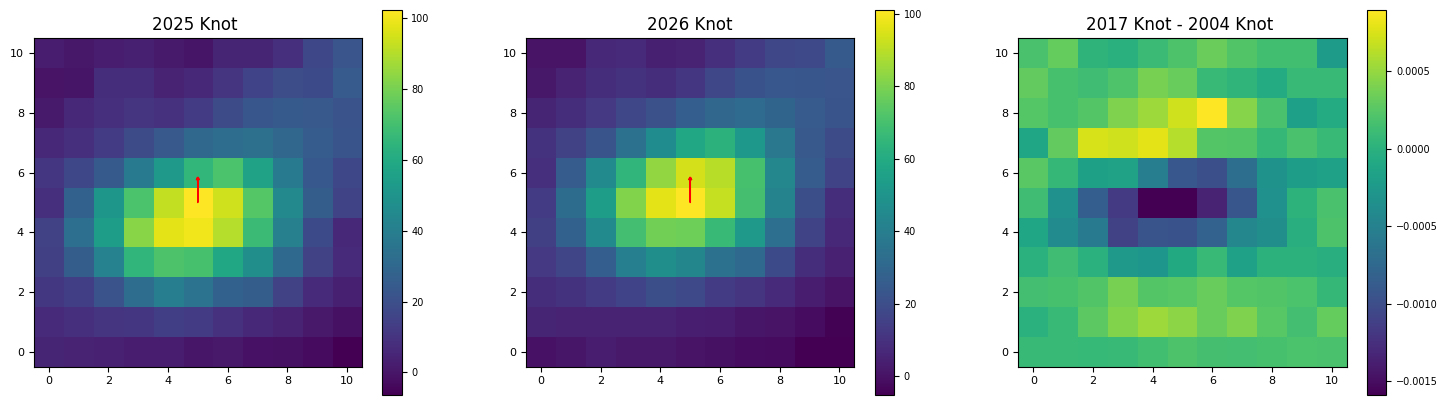

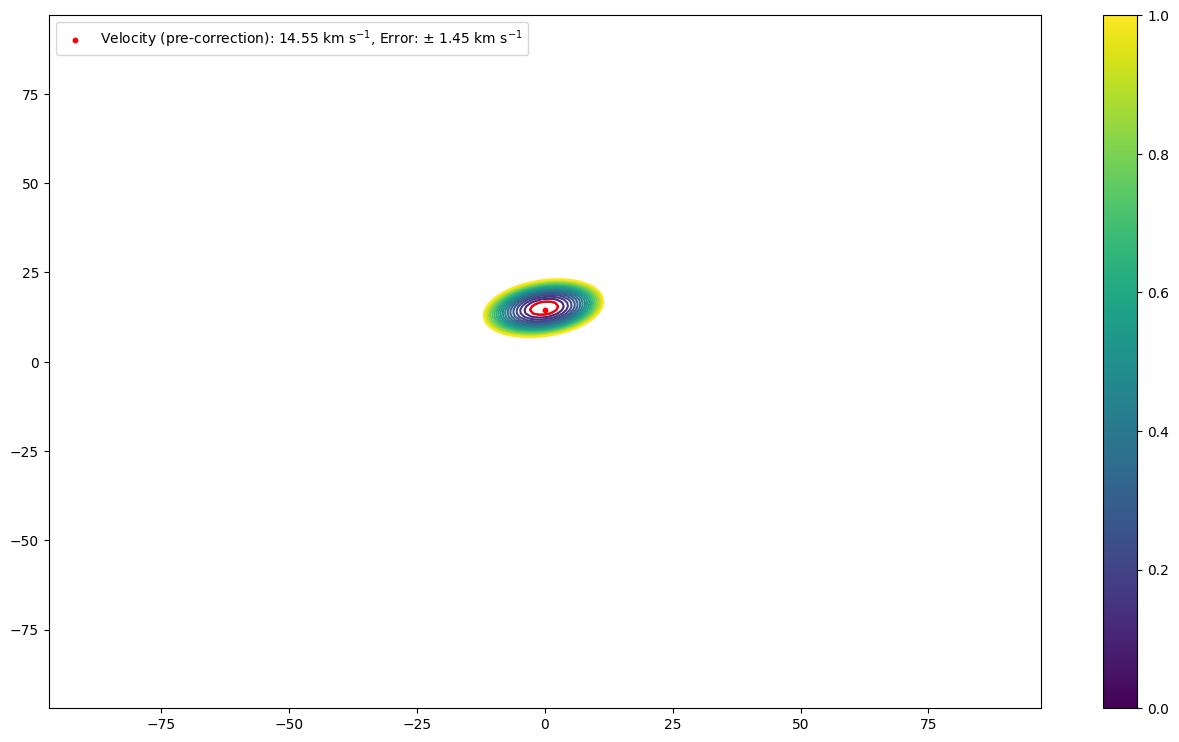

In [32]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5819]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.04432927734318043 , X shift =  0.0 , Y shift =  0.8
Vx 0.0 Vy 15.517026366053555
velocity 15.517026366053555
V error ± 0.9698141478783464
Vx error ± 3.8792565915133888 Vy error ± 0.9698141478783464
angle = -0.0
angle error ± 14.32394487827058


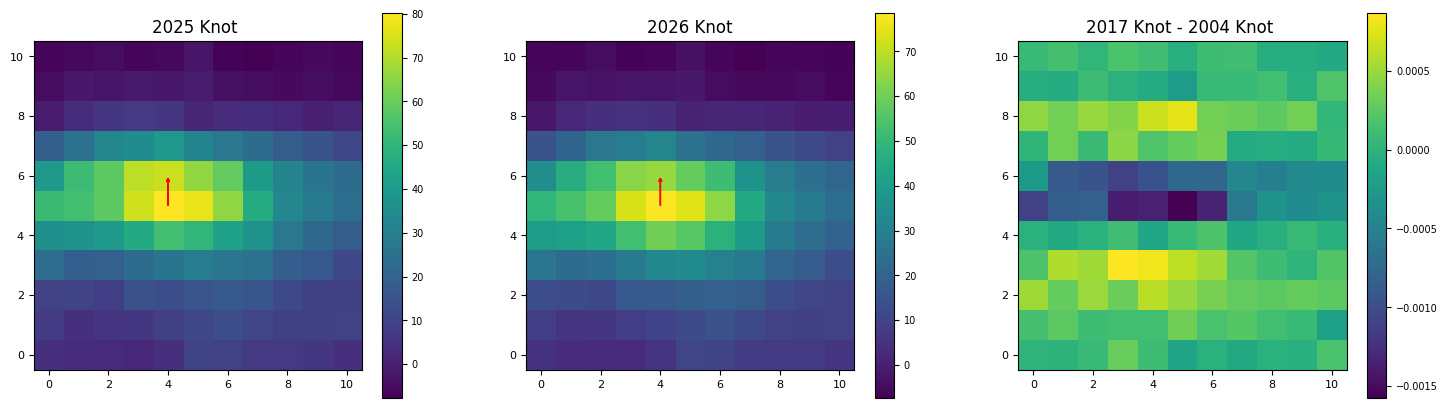

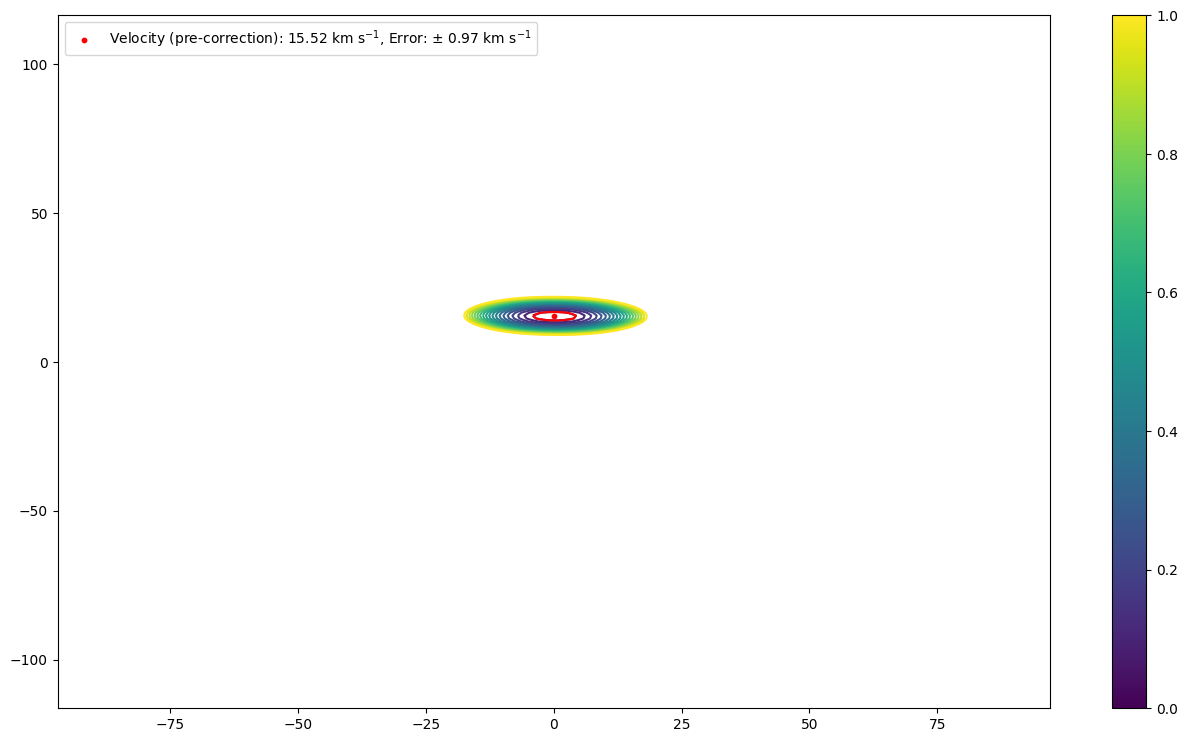

In [33]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5833]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.011901457469793004 , X shift =  0.0 , Y shift =  0.8
Vx 0.0 Vy 15.517026366053555
velocity 15.517026366053555
V error ± 1.4547212218175183
Vx error ± 3.3943495175742155 Vy error ± 1.4547212218175183
angle = -0.0
angle error ± 12.533451768486762


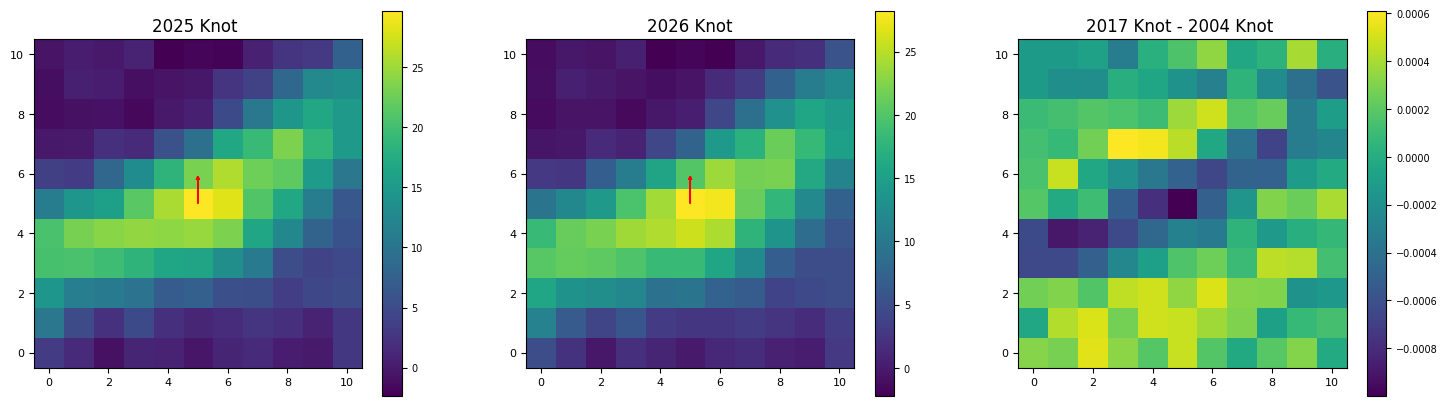

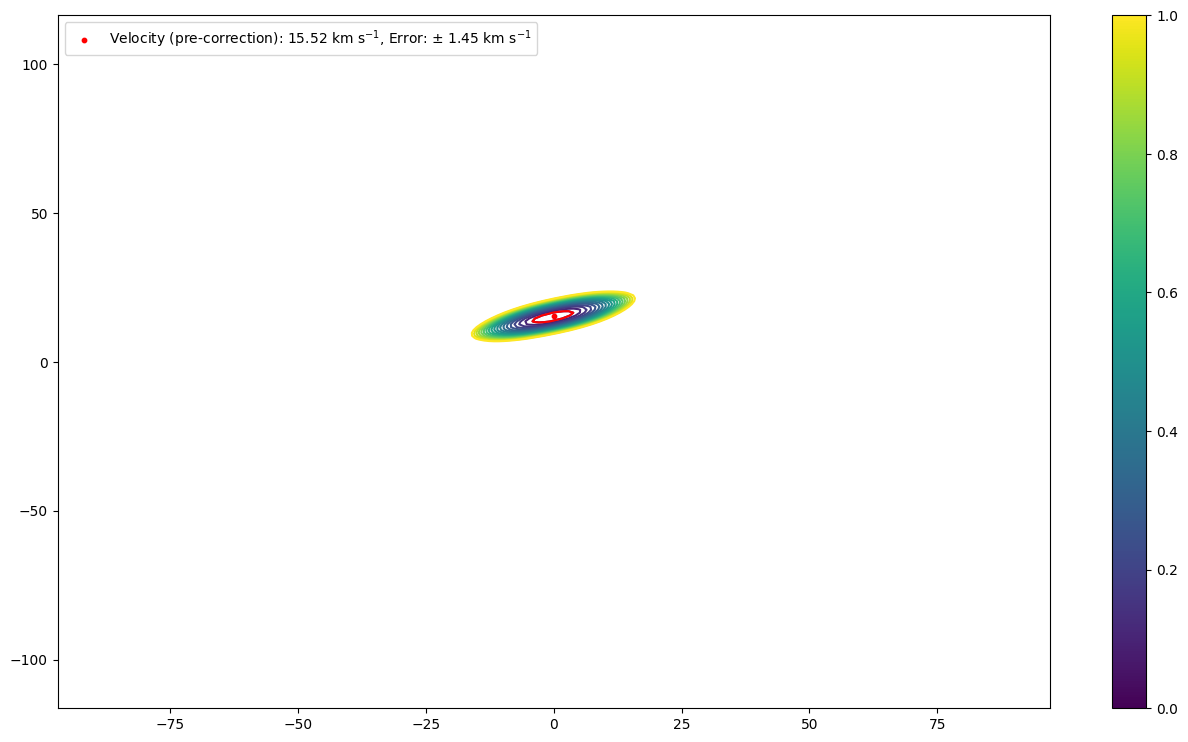

In [34]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5737]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.007140750419116134 , X shift =  0.0 , Y shift =  0.8
Vx 0.0 Vy 15.517026366053555
velocity 15.517026366053555
V error ± 1.4547212218175183
Vx error ± 0.9698141478783472 Vy error ± 1.4547212218175183
angle = -0.0
angle error ± 3.580986219567645


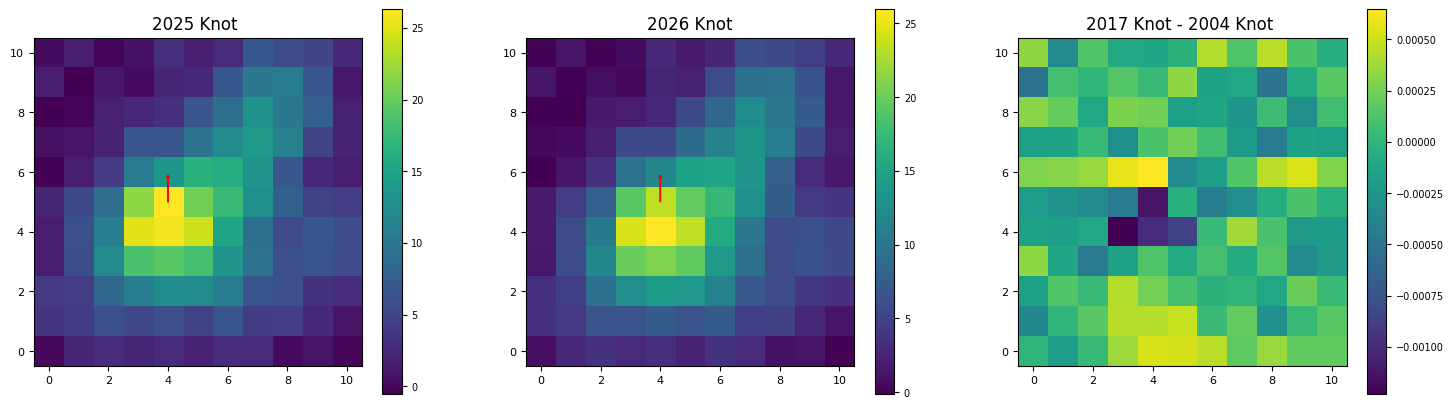

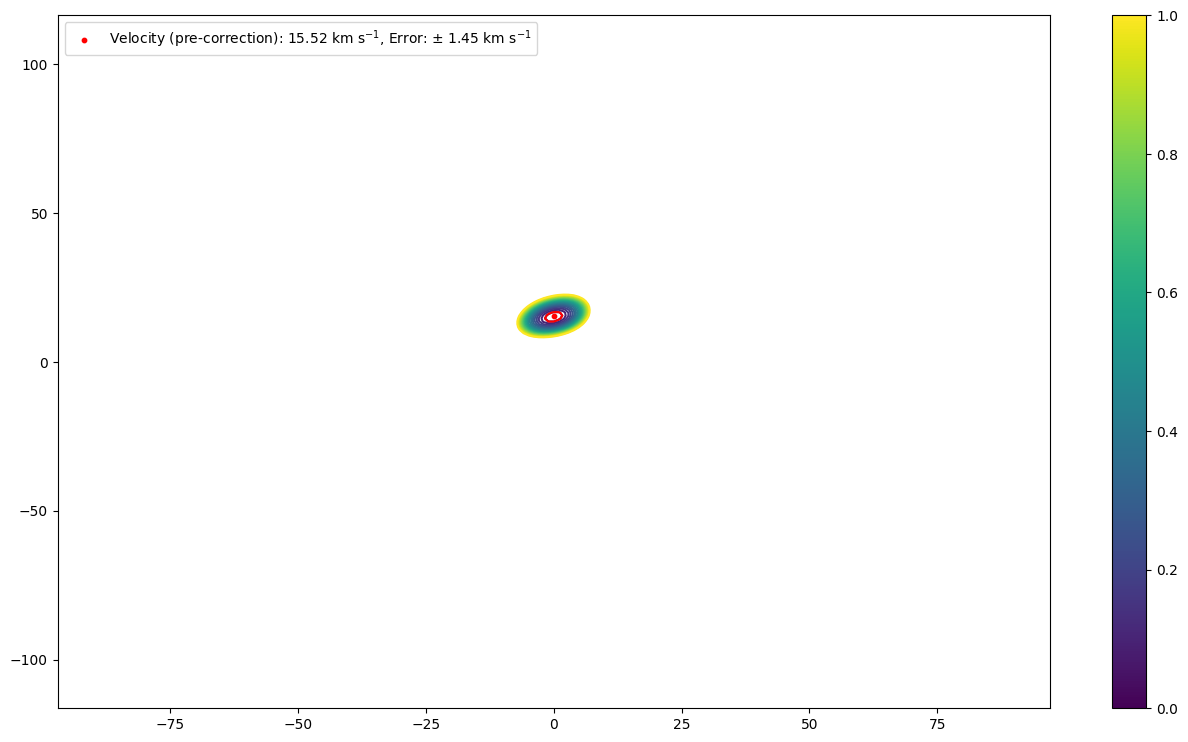

In [35]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5921]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.01572896750447293 , X shift =  0.0 , Y shift =  0.8
Vx 0.0 Vy 15.517026366053555
velocity 15.517026366053555
V error ± 1.4547212218175183
Vx error ± 0.9698141478783472 Vy error ± 1.4547212218175183
angle = -0.0
angle error ± 3.580986219567645


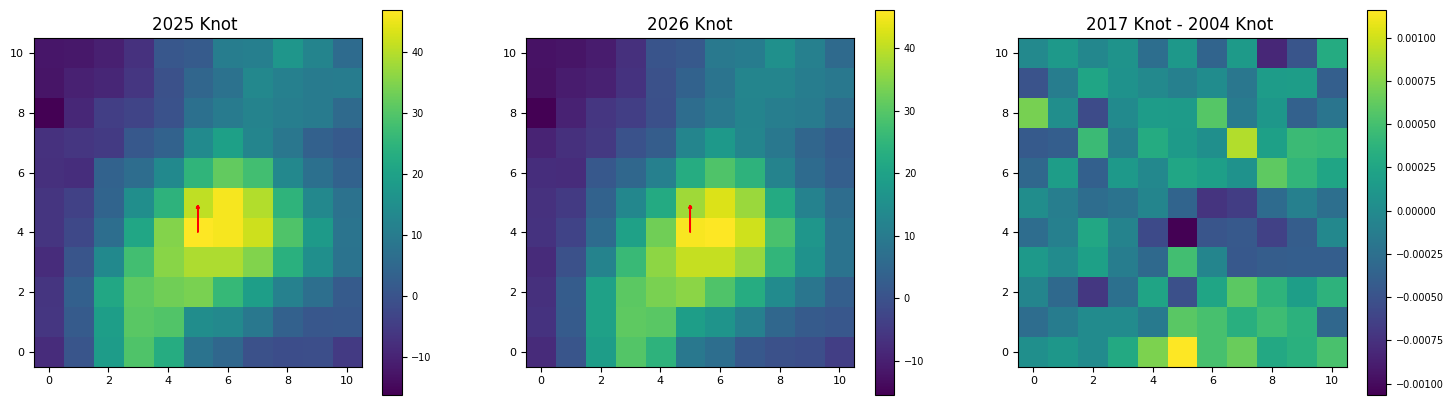

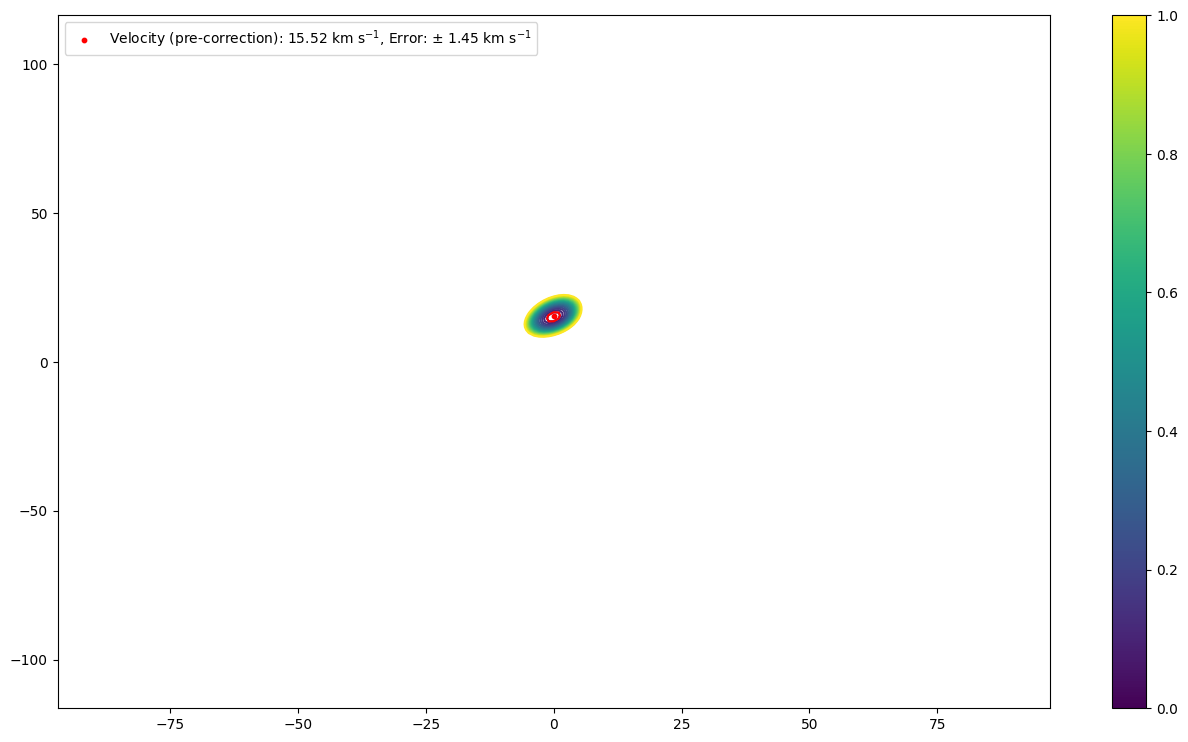

In [108]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6052]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **5 km s-1**

In [109]:
hdu_2 = fits.open((path_image_2 + 'testing_5km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 0
minimum chi squared value =  0.033243866122474056 , X shift =  0.0 , Y shift =  0.25
Vx 0.0 Vy 4.849070739391736
velocity 4.849070739391736
V error ± 0.9698141478783475
Vx error ± 1.4547212218175207 Vy error ± 0.9698141478783475
angle = -0.0
angle error ± 17.1887338539247


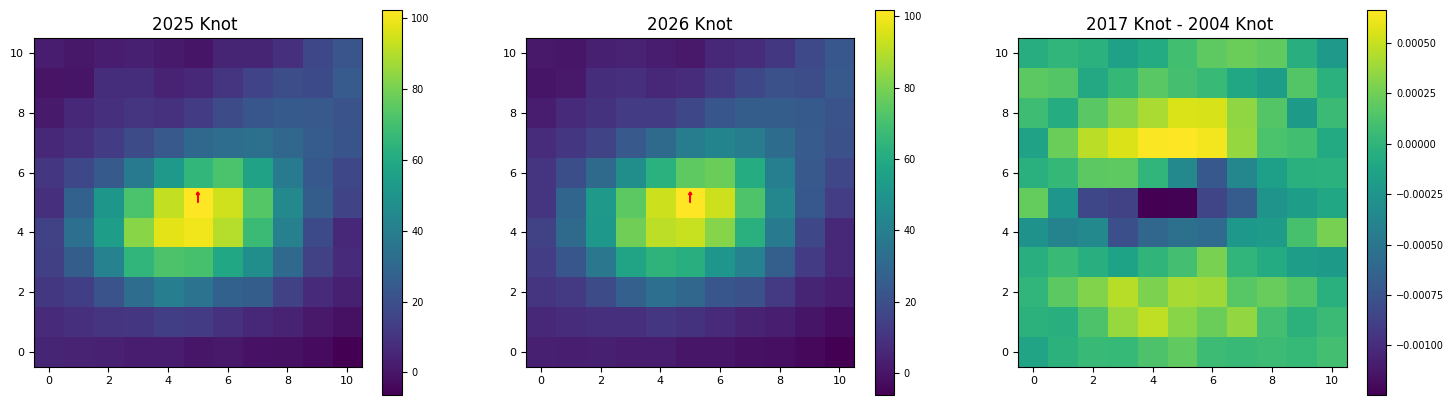

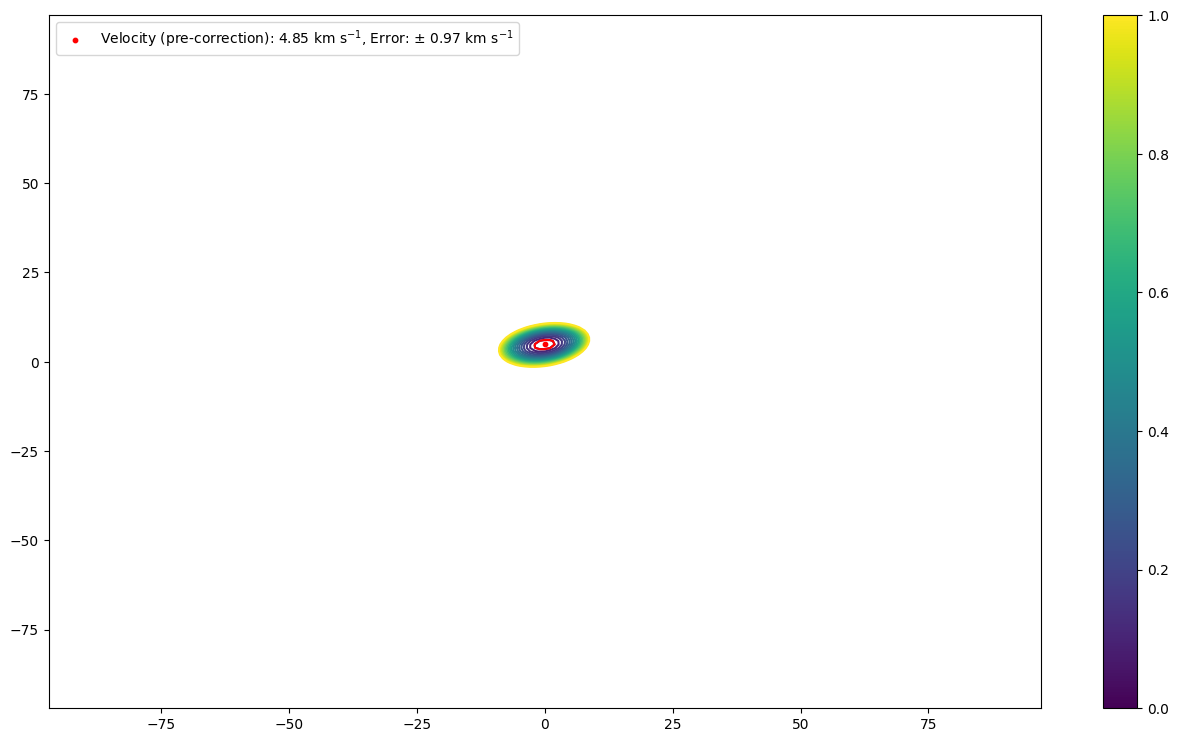

In [37]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5819]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.08615901536944659 , X shift =  0.05 , Y shift =  0.25
Vx 0.9698141478783472 Vy 4.849070739391736
velocity 4.9451012645900505
V error ± 1.7689269361706592
Vx error ± 5.333977813330909 Vy error ± 1.4547212218175218
angle = -11.309932474020213
angle error ± 60.69138900157659


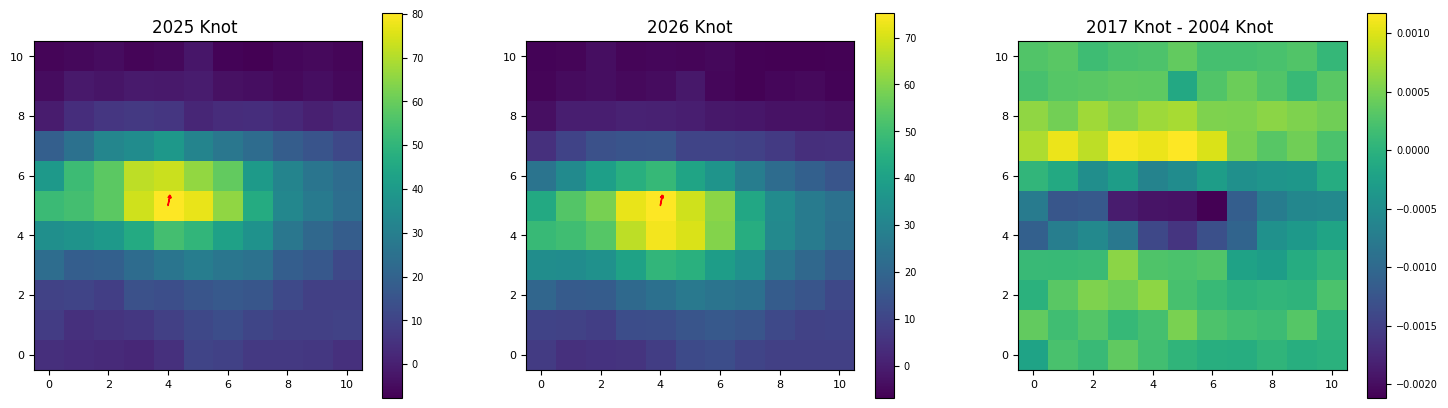

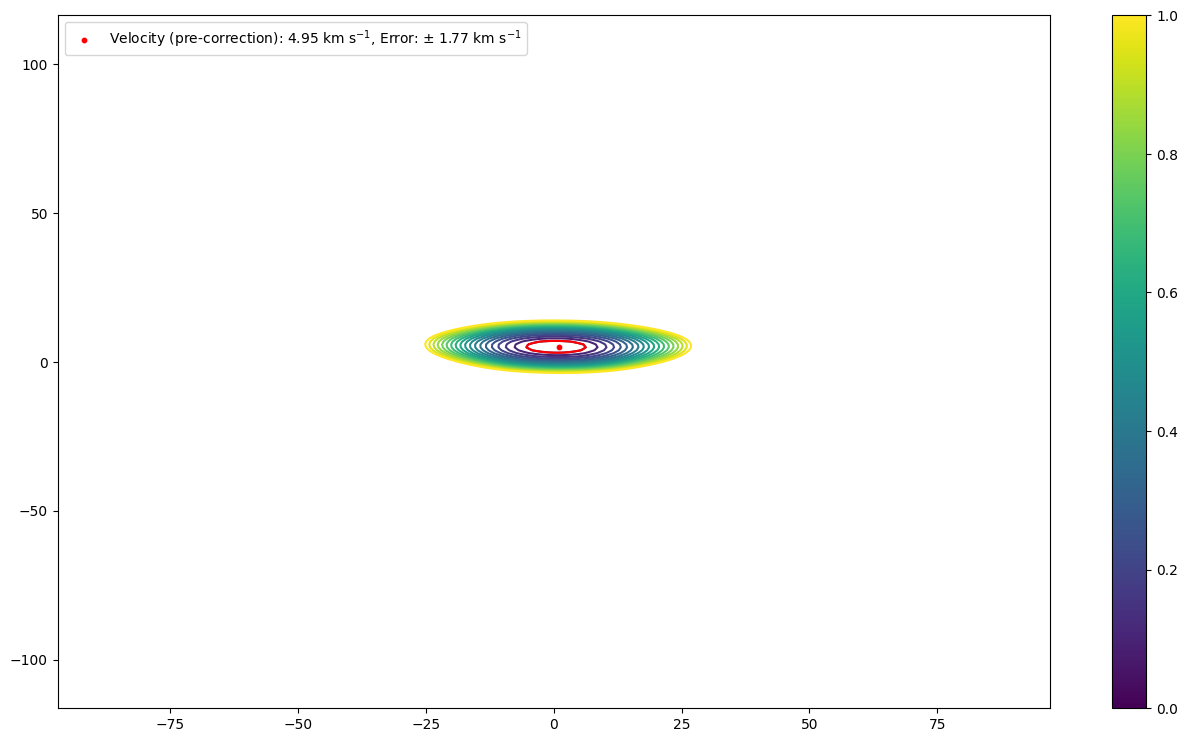

In [38]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5833]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.011030139842242187 , X shift =  0.0 , Y shift =  0.25
Vx 0.0 Vy 4.849070739391736
velocity 4.849070739391736
V error ± 1.454721221817521
Vx error ± 2.909442443635042 Vy error ± 1.454721221817521
angle = -0.0
angle error ± 34.3774677078494


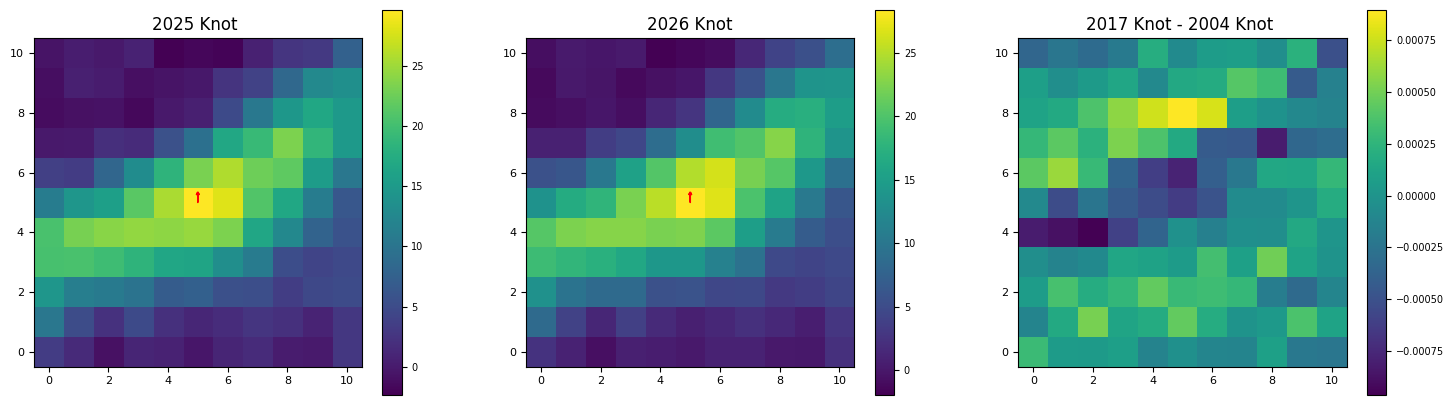

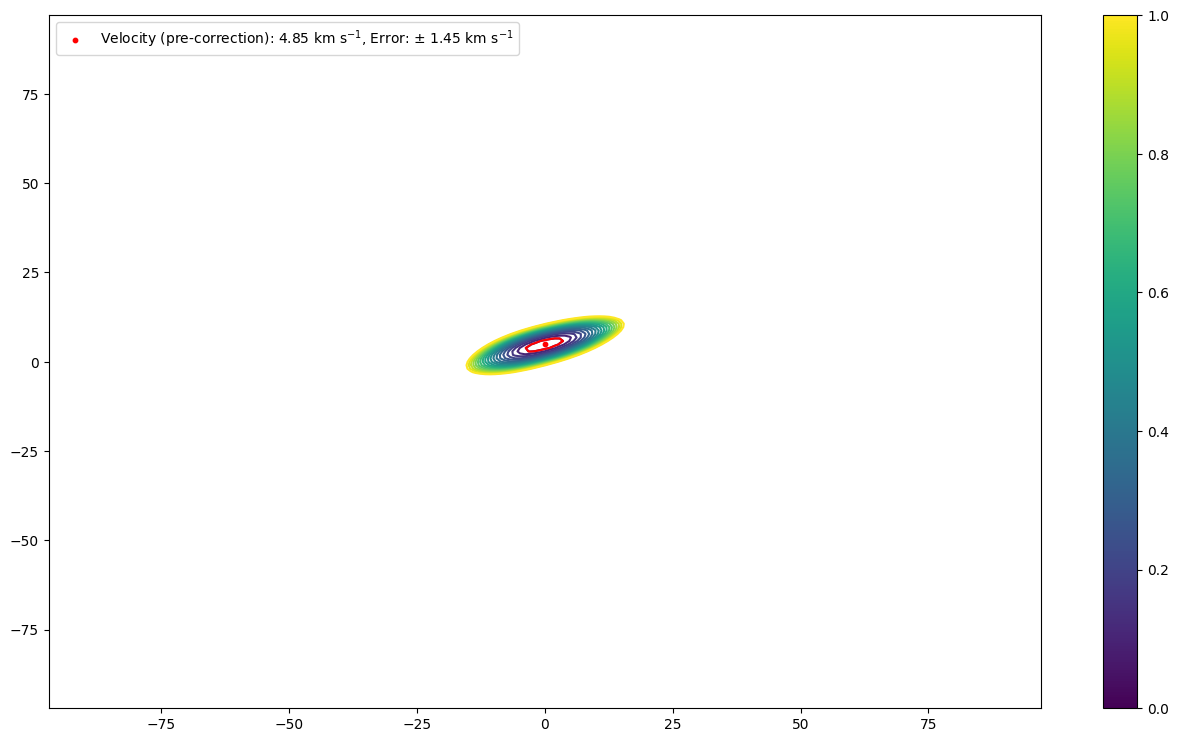

In [39]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5736]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.007883871523389053 , X shift =  0.0 , Y shift =  0.25
Vx 0.0 Vy 4.849070739391736
velocity 4.849070739391736
V error ± 0.9698141478783475
Vx error ± 0.9698141478783472 Vy error ± 0.9698141478783475
angle = -0.0
angle error ± 11.459155902616466


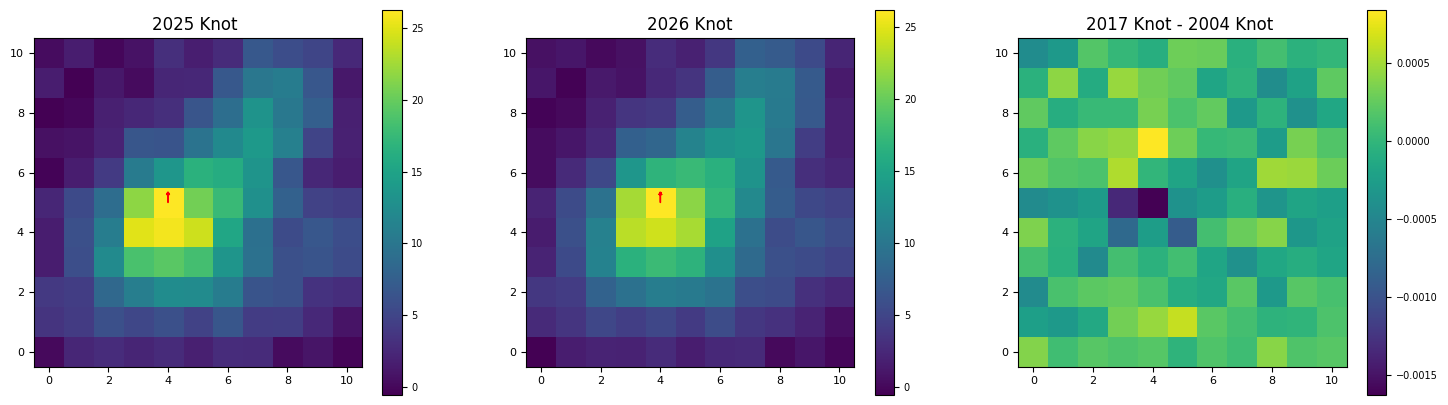

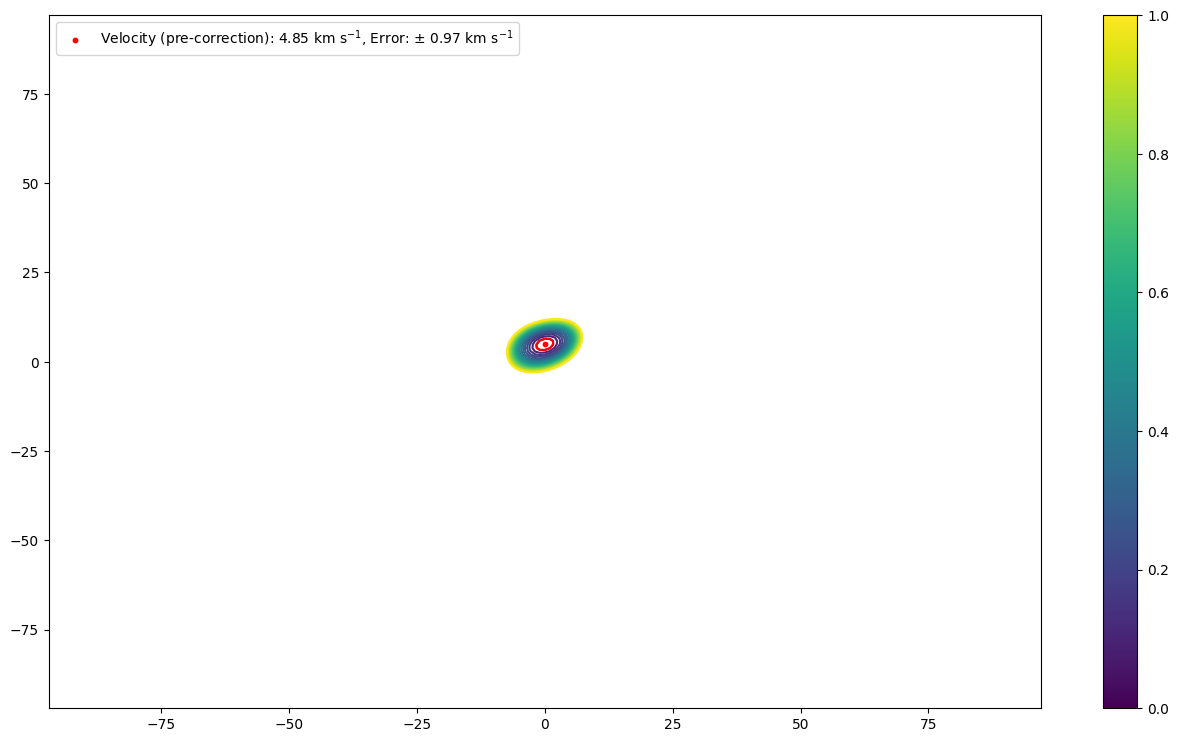

In [40]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5920]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.015100751320102981 , X shift =  0.0 , Y shift =  0.25
Vx 0.0 Vy 4.849070739391736
velocity 4.849070739391736
V error ± 0.9698141478783475
Vx error ± 0.9698141478783472 Vy error ± 0.9698141478783475
angle = -0.0
angle error ± 11.459155902616466


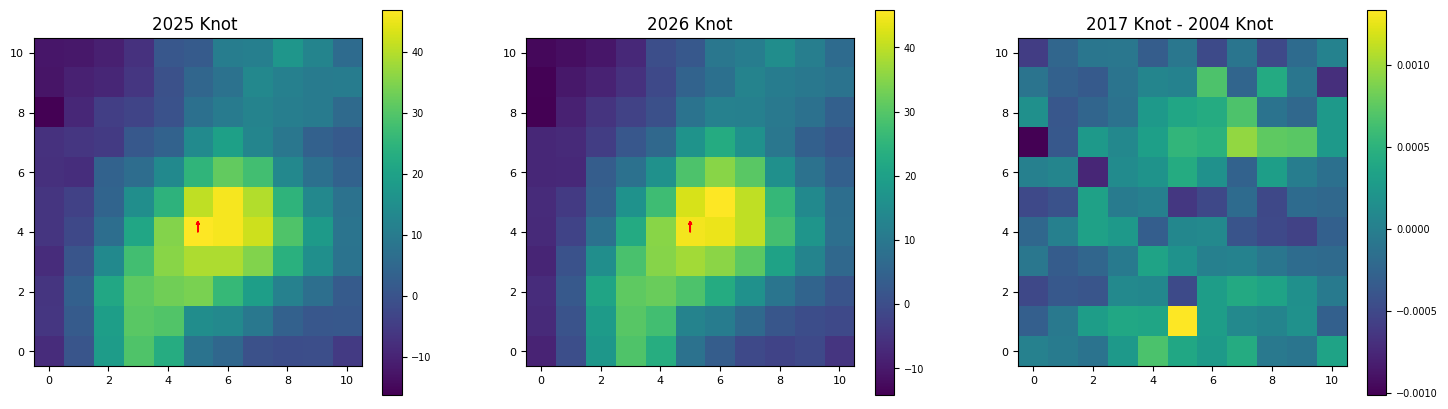

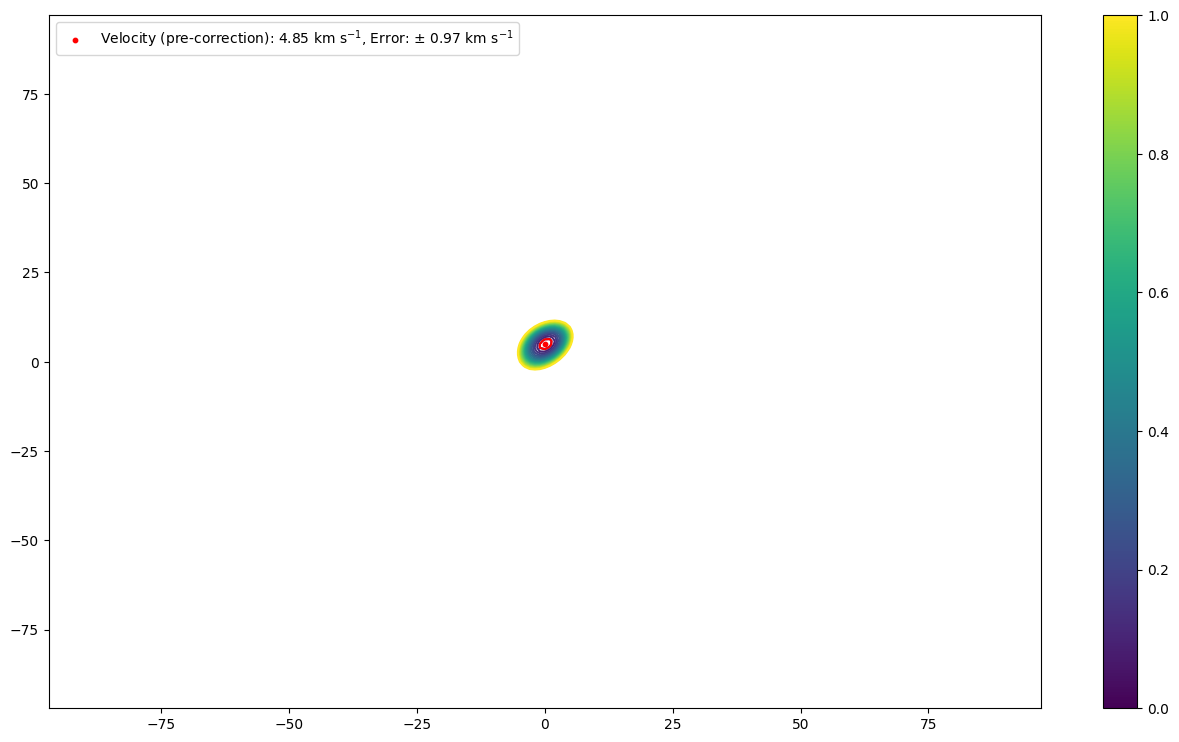

In [111]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4681, 4681]
cy_chi = [6051, 6051]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **1 km s-1**

In [41]:
hdu_2 = fits.open((path_image_2 + 'testing_1km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 0
minimum chi squared value =  0.0017689834266958158 , X shift =  0.0 , Y shift =  0.05
Vx 0.0 Vy 0.9698141478783472
velocity 0.9698141478783472
V error ± 0.0
Vx error ± 0.0 Vy error ± 0.0
angle = -0.0
angle error ± 0.0


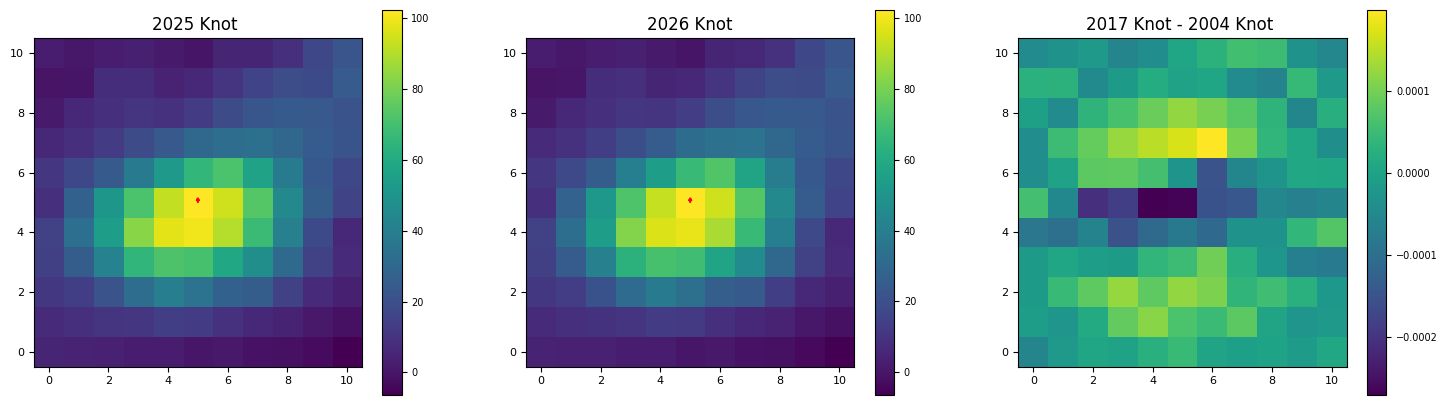

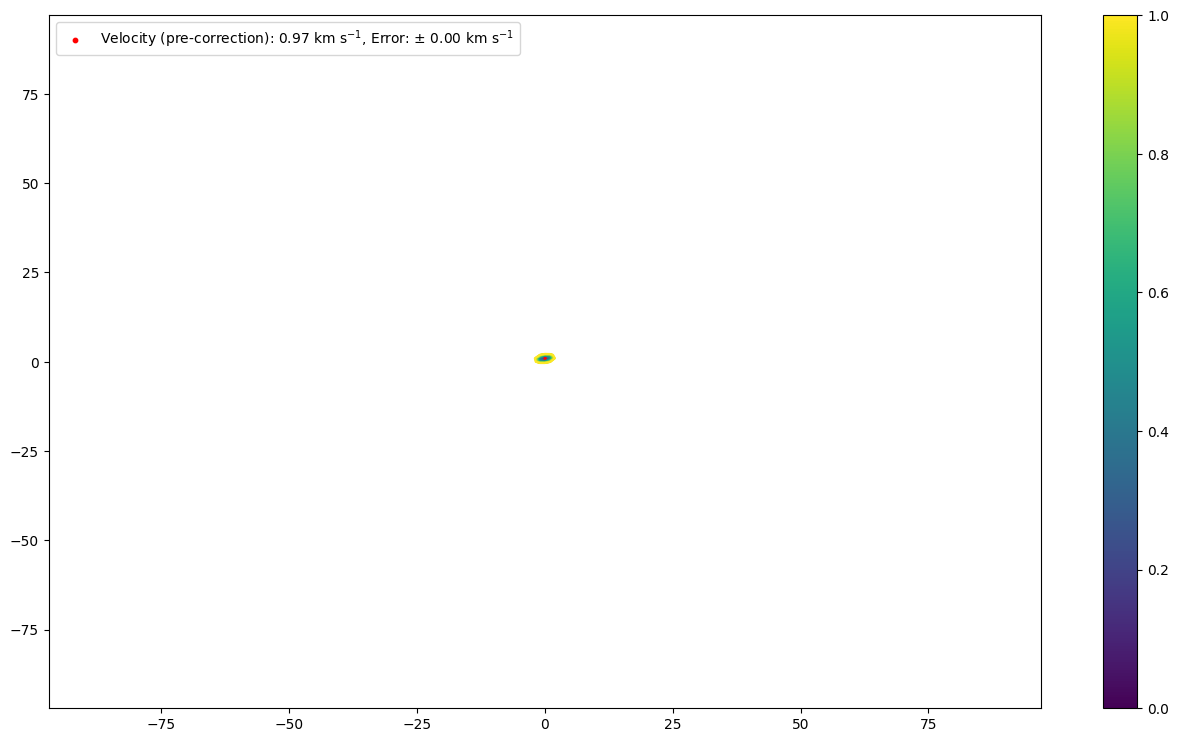

In [42]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5819]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 1
minimum chi squared value =  0.08324632448902573 , X shift =  0.05 , Y shift =  0.04999999999999993
Vx 0.9698141478783472 Vy 0.9698141478783457
velocity 1.3715243209108638
V error ± 3.9094458140708825
Vx error ± 5.333977813330909 Vy error ± 1.4547212218175196
angle = -45.00000000000005
angle error ± 163.31809940678784


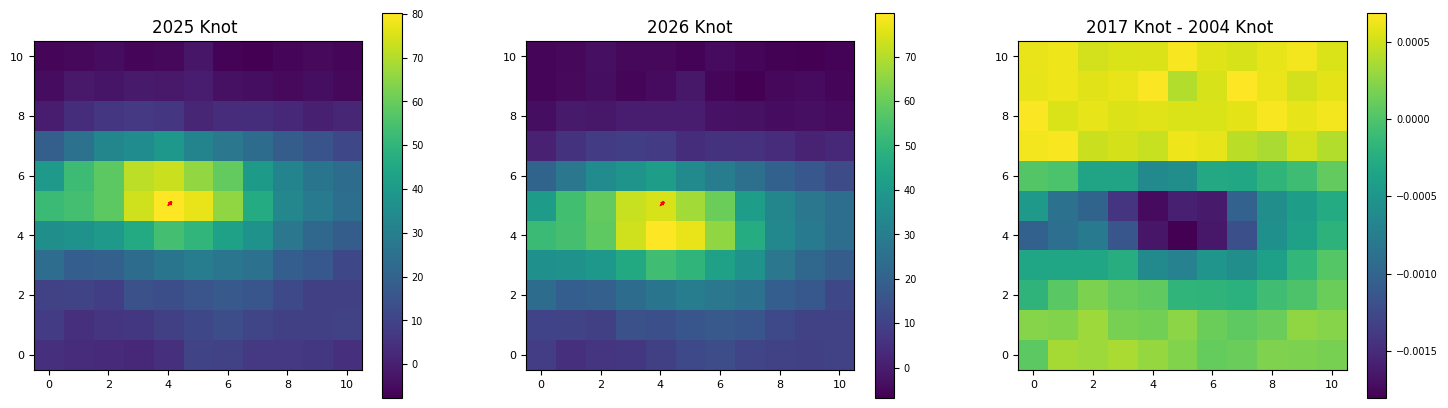

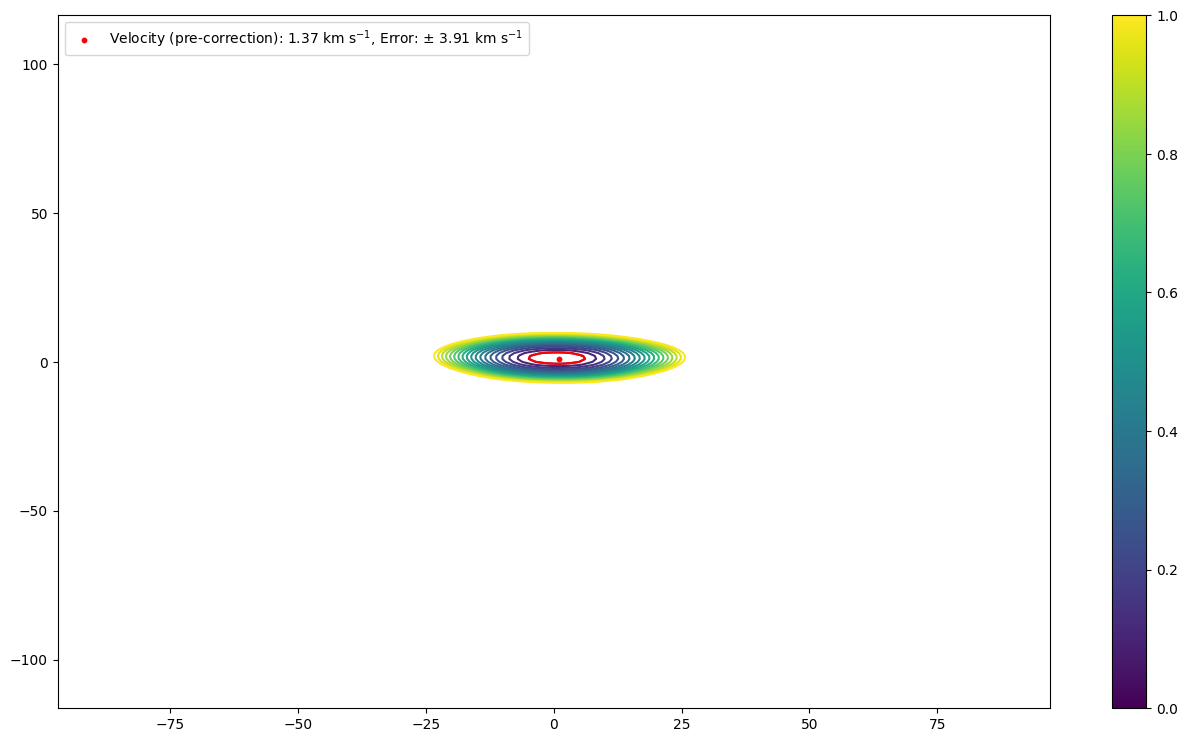

In [43]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5833]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.0008887960458006856 , X shift =  0.0 , Y shift =  0.05
Vx 0.0 Vy 0.9698141478783472
velocity 0.9698141478783472
V error ± 0.0
Vx error ± 0.0 Vy error ± 0.0
angle = -0.0
angle error ± 0.0


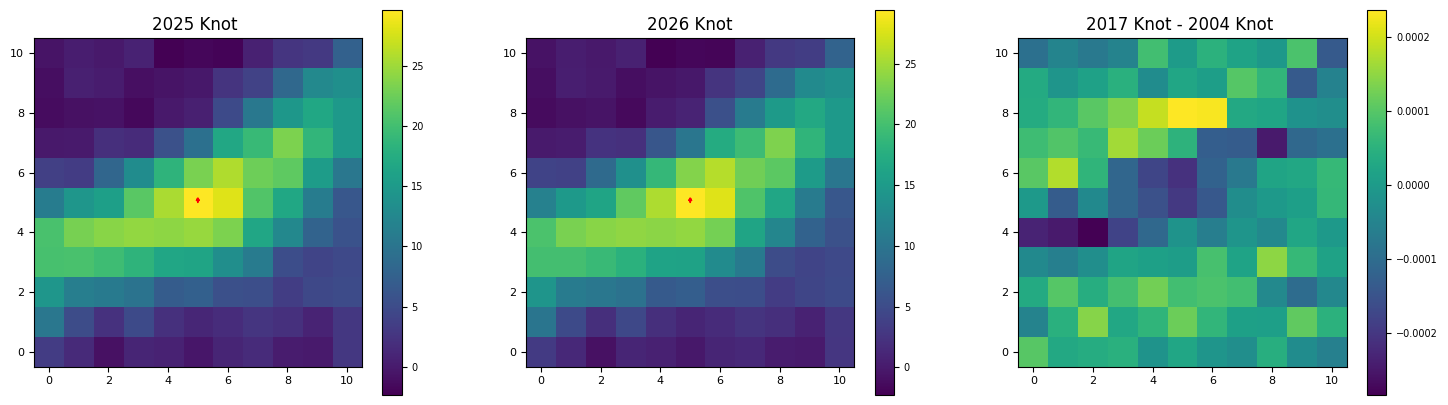

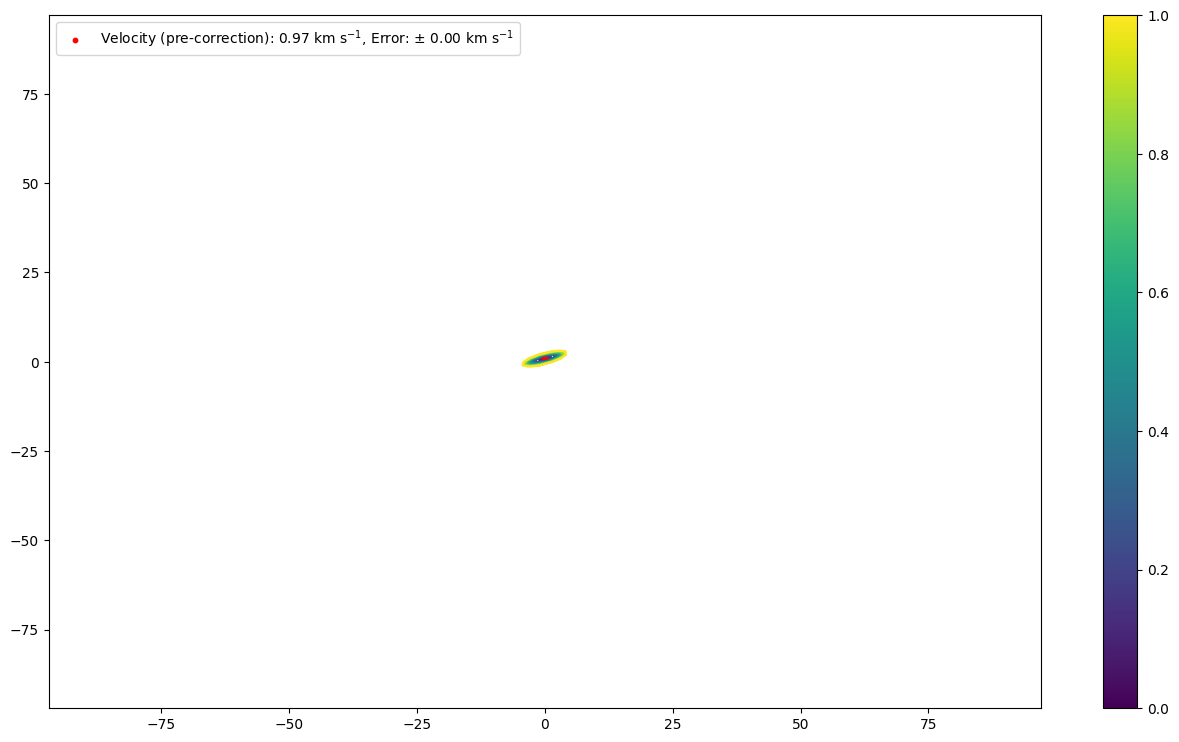

In [44]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5736]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.0005505445493716938 , X shift =  0.0 , Y shift =  0.05
Vx 0.0 Vy 0.9698141478783472
velocity 0.9698141478783472
V error ± 0.0
Vx error ± 0.0 Vy error ± 0.0
angle = -0.0
angle error ± 0.0


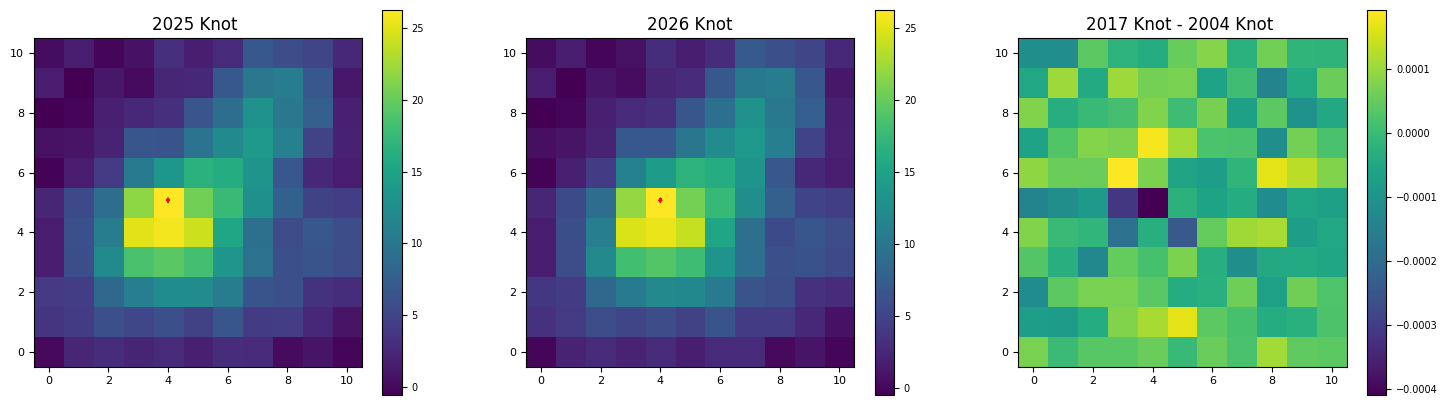

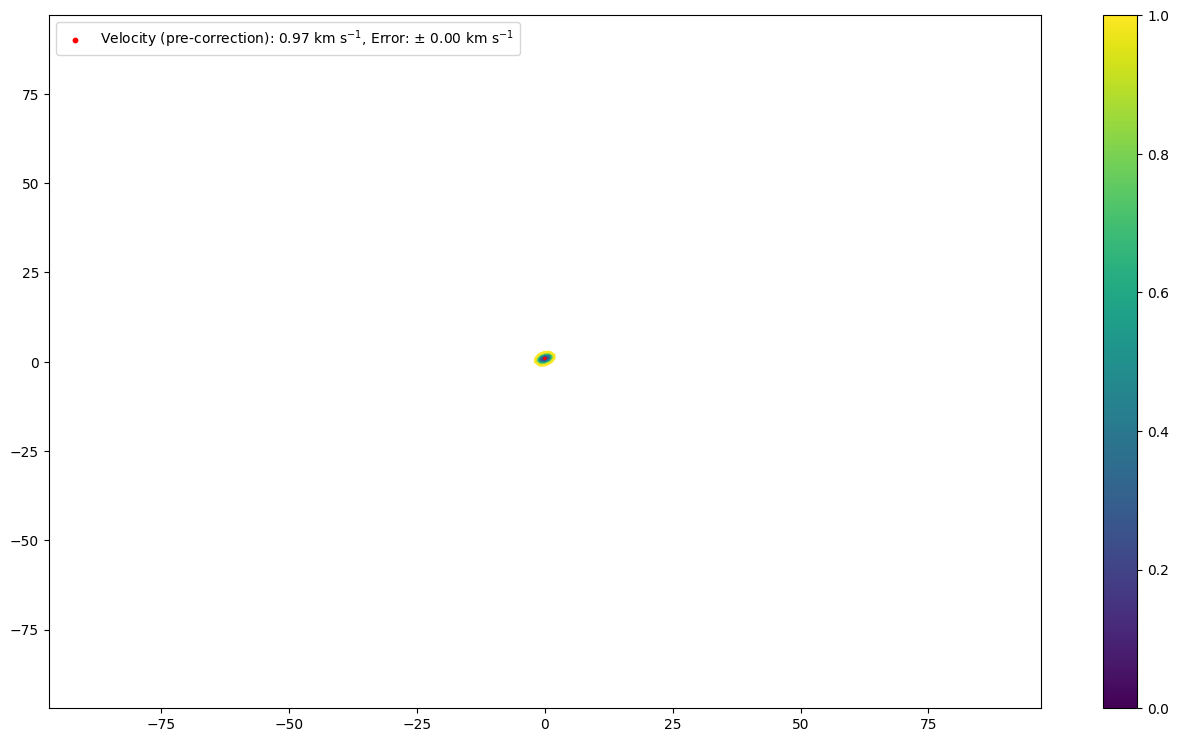

In [45]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5920]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **.25 km s-1**

In [46]:
hdu_2 = fits.open((path_image_2 + 'testing_dot_25km_in_3_years.fits'))[1]
im_1 = hdu_1.data
im_2 = hdu_2.data
#defines the header
header_1 = hdu_1.header
header_2 = hdu_2.header

x axis correction 0
y axis correction 0
minimum chi squared value =  0.00011977311889556082 , X shift =  0.0 , Y shift =  0.01
Vx 0.0 Vy 0.19396282957566943
velocity 0.19396282957566943
V error ± 0.04849070739391735
Vx error ± 0.09698141478783472 Vy error ± 0.04849070739391735
angle = -0.0
angle error ± 28.64788975654116


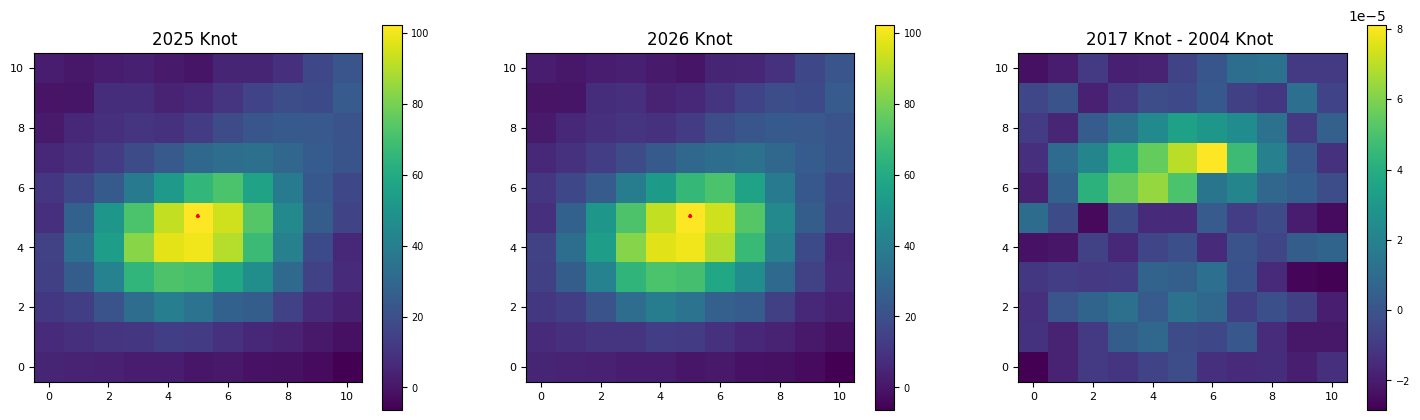

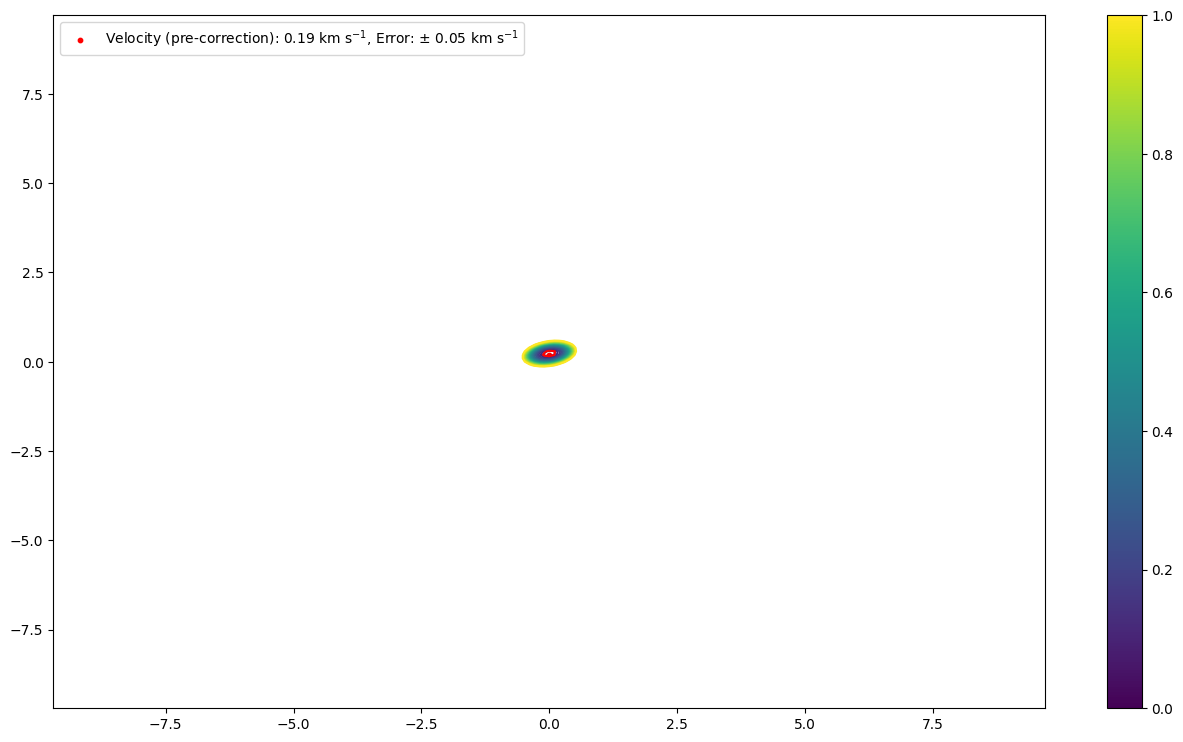

In [47]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4656, 4656]
cy_chi = [5819, 5819]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .005
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  0.00026995262627035557 , X shift =  0.0 , Y shift =  0.01
Vx 0.0 Vy 0.19396282957566943
velocity 0.19396282957566943
V error ± 0.04849070739391735
Vx error ± 0.29094424436350413 Vy error ± 0.04849070739391735
angle = -0.0
angle error ± 85.94366926962347


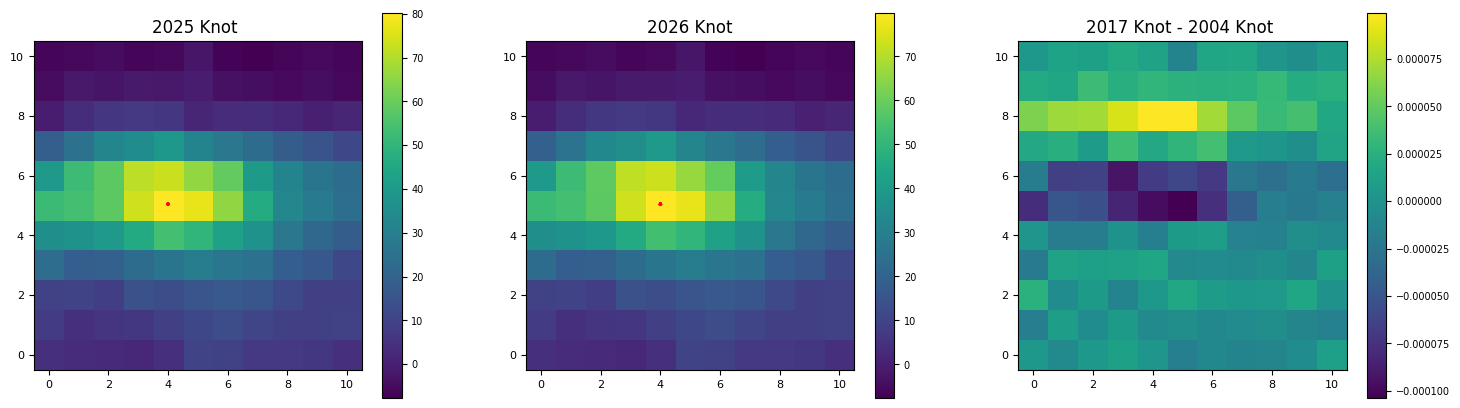

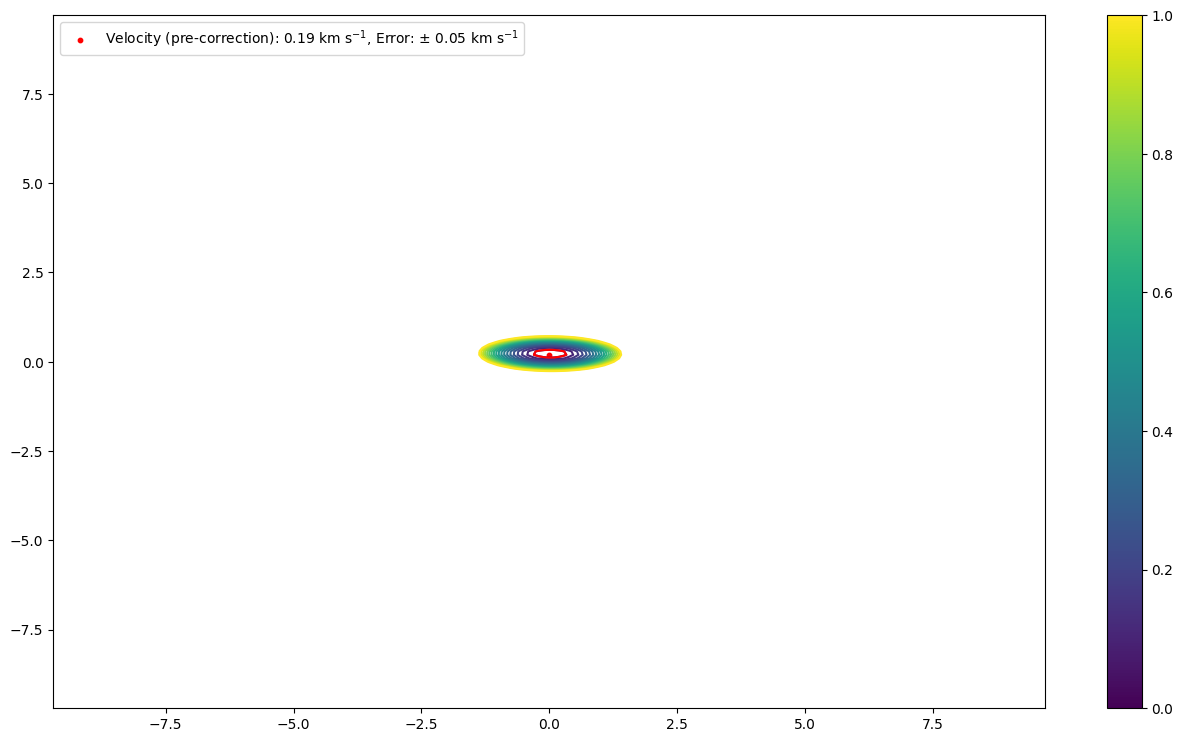

In [48]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4651, 4651]
cy_chi = [5832, 5832]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .005
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  3.8747753155173285e-05 , X shift =  0.0 , Y shift =  0.01
Vx 0.0 Vy 0.19396282957566943
velocity 0.19396282957566943
V error ± 0.04849070739391735
Vx error ± 0.19396282957566943 Vy error ± 0.04849070739391735
angle = -0.0
angle error ± 57.29577951308232


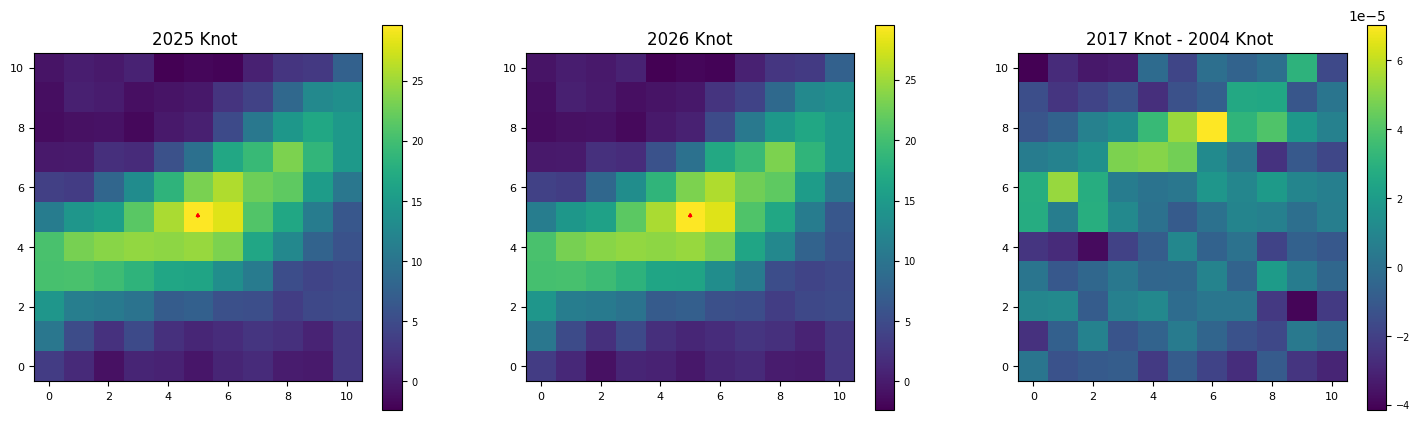

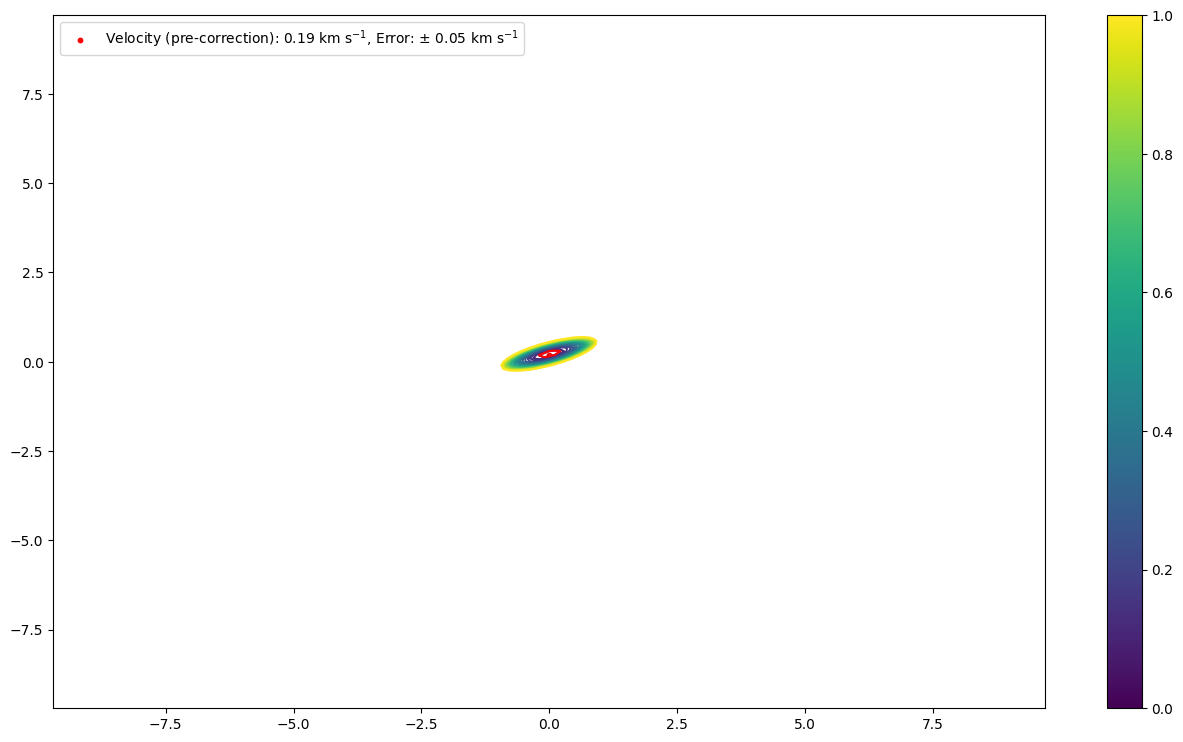

In [49]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4606, 4606]
cy_chi = [5736, 5736]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .005
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

x axis correction 0
y axis correction 0
minimum chi squared value =  3.427646323838754e-05 , X shift =  0.0 , Y shift =  0.01
Vx 0.0 Vy 0.19396282957566943
velocity 0.19396282957566943
V error ± 0.04849070739391735
Vx error ± 0.09698141478783472 Vy error ± 0.04849070739391735
angle = -0.0
angle error ± 28.64788975654116


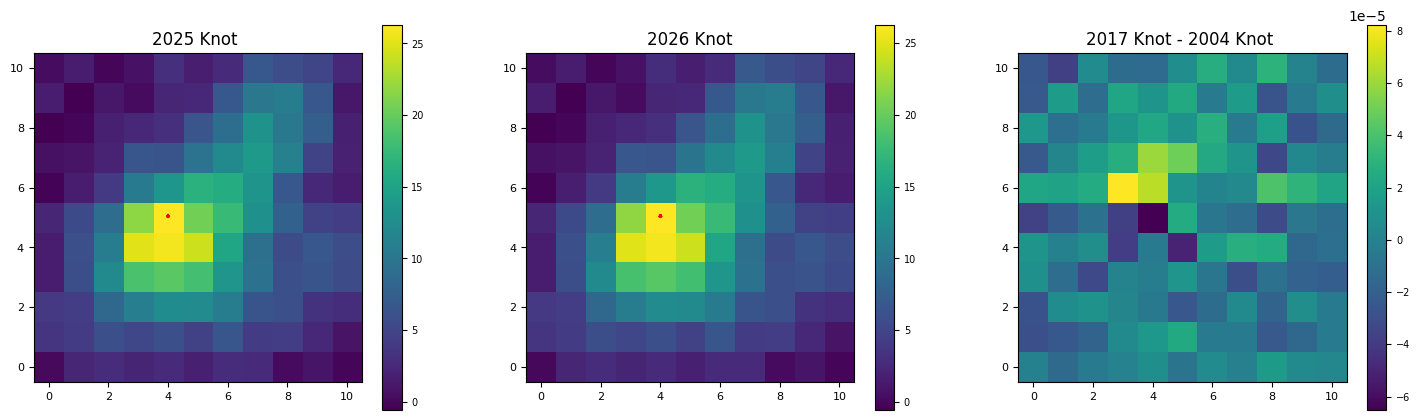

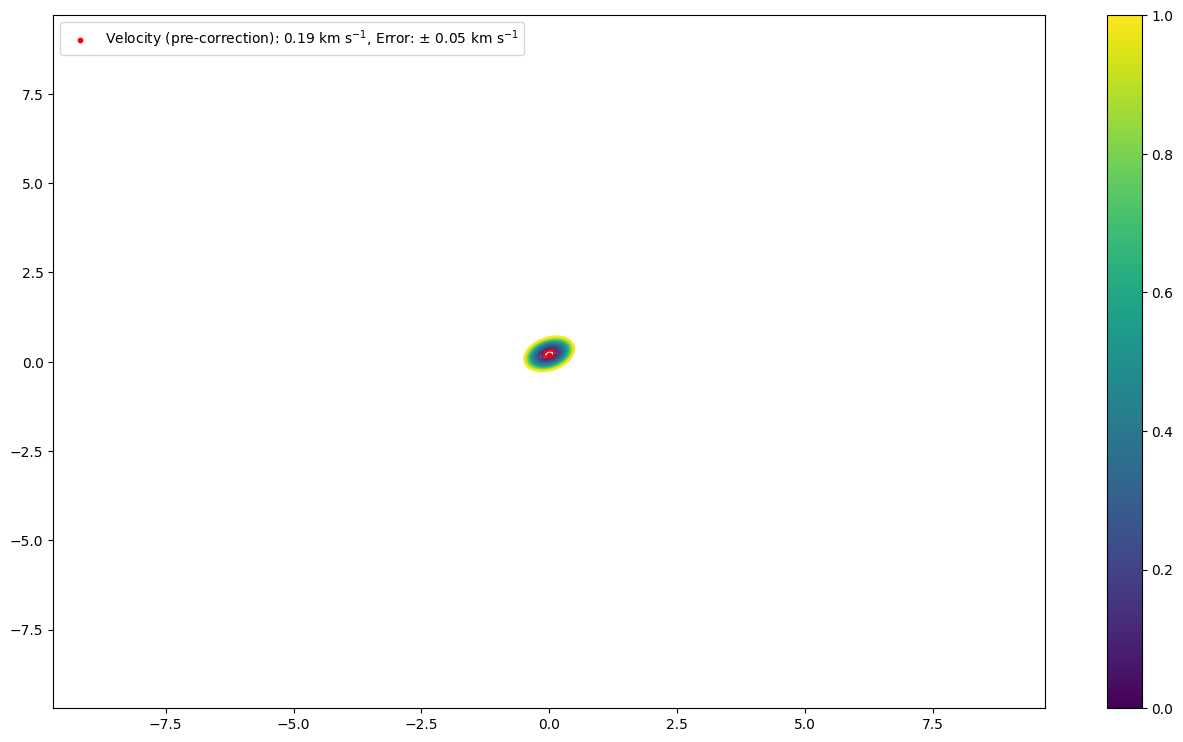

In [50]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [4648, 4648]
cy_chi = [5920, 5920]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .005
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 100
height = 100
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1.data, hdu_2.data, hdu_1.header, hdu_2.header)

# **results**

In [51]:
velocity_storage = np.sqrt((np.array(velocity_storage_x) ** 2 + np.array(velocity_storage_y) **2))

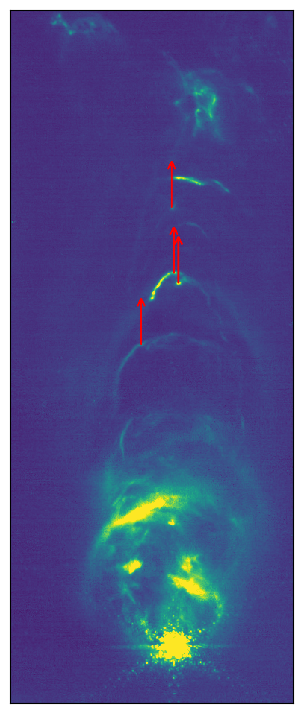

In [92]:
## creates velocity arrows image
#cretes a plot
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
#shows the cutout the 2004 image
ax.imshow(hdu_1.data, vmin=-10, vmax=100, cmap='viridis', interpolation='none',  origin="lower")
# zoom = 100
# #this plots the base of the sw knots and then uses an arrow to point to the position of the second arrow while also increasing the magnitude for visual clarity
scaling_factor = 10.0  # Increase this factor to make arrows longer
# #this find the ratio between pixels and velocity in km s-1
# factor = (velocity_storage[2])/(np.sqrt((x_coord_2_chi[2] - x_coord_1_chi[2])**2+(y_coord_2_chi[2] - y_coord_1_chi[2])**2))
# #finds the pixel shift for a velocity of 200 km s-1; used for the scale bar
# v_200 = 200/factor
n = np.ones(4)
for k in range(len(n)):
    dx = (x_coord_2_chi[k] - x_coord_1_chi[k]) * scaling_factor
    dy = (y_coord_2_chi[k] - y_coord_1_chi[k]) * scaling_factor
    ax.arrow(
        x_coord_1_chi[k], 
        y_coord_1_chi[k], 
        dx, 
        dy, 
        head_width=(scaling_factor), 
        head_length=(scaling_factor),
        overhang=1,
        color='red', 
        width=0.03 * scaling_factor
    )
# dash_len = 2
# for y in [1300, (1300 + v_200 * scaling_factor) + scaling_factor]:
#     ax.hlines(y, 805 - dash_len, 805 + dash_len, color='#32CD32', linewidth=2)
# ax.plot([805, 805],[1300, (1300 + v_200 * scaling_factor)+scaling_factor],color='#32CD32', linewidth=2, label='200 km s$^{-1}$')
# ax.scatter(x_coord_1_chi, y_coord_1_chi, s=5, color='red')
# # ax.scatter(H310_04_x, H310_04_y, s=50, marker='+', color='red', label='HOPS 354')
# H310_04_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_1.header))
# H310_04 = np.array(H310_04_t)
# H310_17_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_2.header))
# H310_04_x = (np.array(H310_04_t[0]))
# H310_04_y = (np.array(H310_04_t[1]))
ax.set_xlim([4430, 4810])
ax.set_ylim([5255, 6185])
plt.xticks([])
plt.yticks([])
# ax.spines['top'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
# plt.rc('font', size=10)
# ax.coords['ra'].set_axislabel('Right Ascension')
# ax.coords['dec'].set_axislabel('Declination')
# ax.legend(loc="upper left", handleheight=1*10**-99999)

plt.show()

In [52]:
array = [100, 100, 100, 100, 75, 75, 75, 75, 50, 50, 50, 50, 25, 25, 25, 25, 15, 15, 15, 15, 5, 5, 5, 5, 1, 1, 1, 1, .25, .25, .25, .25]

In [53]:
(velocity_storage - array)/array * 100

array([ -0.10914277,  -0.10914277,  -0.10914277,  -0.10914277,
        -0.43241415,   0.86067138,  -0.42401785,  -0.43241415,
         0.86067138,   0.86067138,   0.86067138,   0.86067138,
         0.86067138,   0.86067138,  -2.94103109,   0.86067138,
        -3.01858521,   3.44684244,   3.44684244,   3.44684244,
        -3.01858521,  -1.09797471,  -3.01858521,  -3.01858521,
        -3.01858521,  37.15243209,  -3.01858521,  -3.01858521,
       -22.41486817, -22.41486817, -22.41486817, -22.41486817])

/tmp/ipykernel_27802/3353476513.py:7: RuntimeWarning: divide by zero encountered in divide
  y = k / x *100


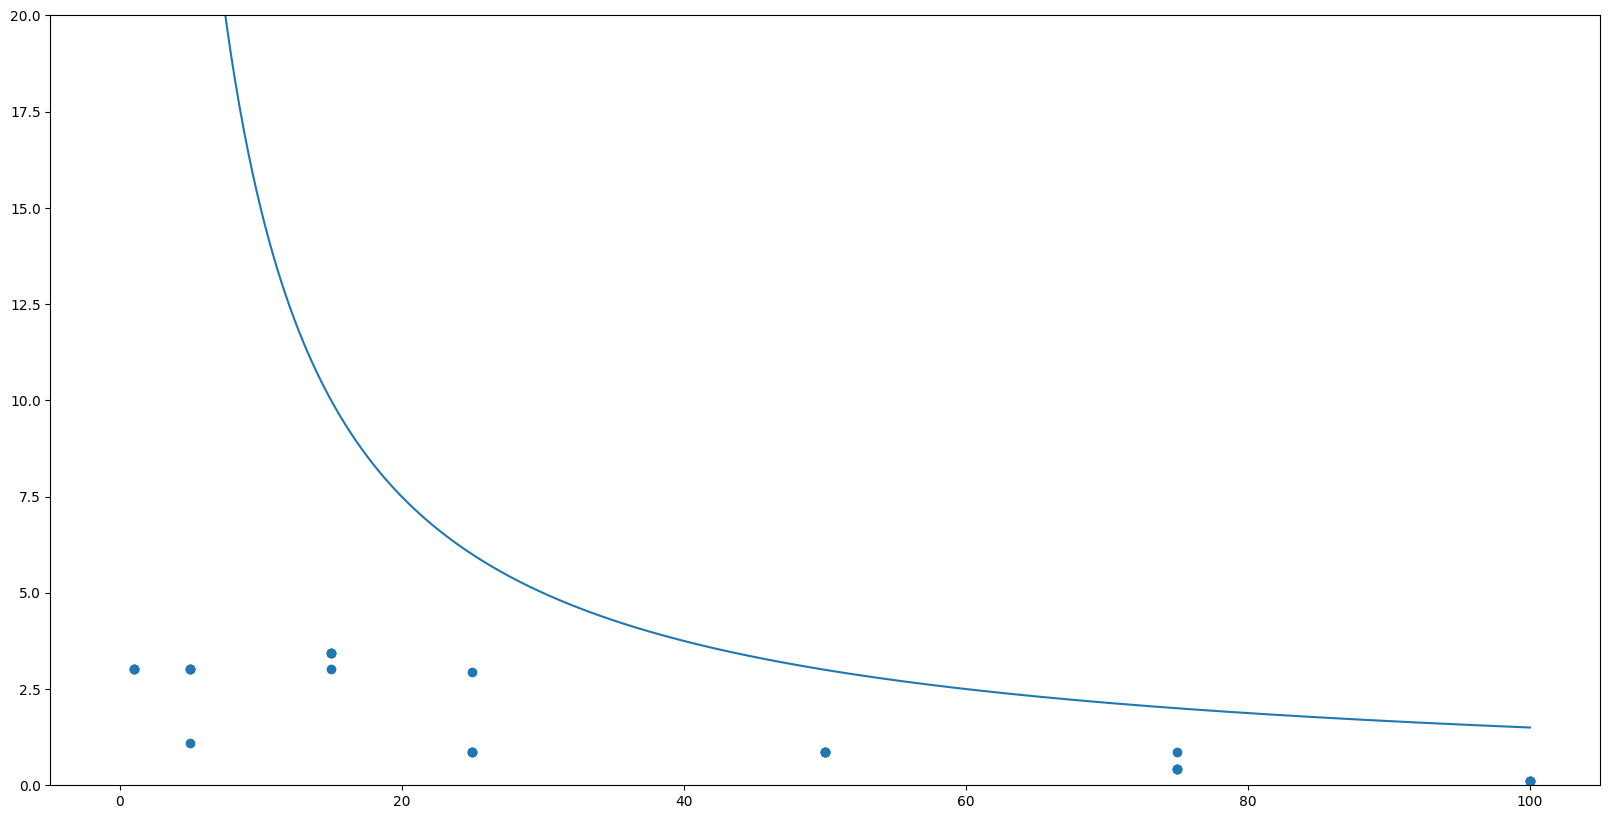

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.scatter(array, np.abs(velocity_storage - array)/array *100)
ax.set_ylim([0, 20])

x= np.linspace(0,100, num=1000)
k = 1.5
y = k / x *100
ax.plot(x,y)

plt.rc('font', size=20)
plt.show()
# ax.set_ylim([0, 350])
